
===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====
User inputs loaded.
Analysis folder: G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis

NI continuous (absolute): 171.362525 → 2433.550000 s
NP continuous (absolute): 171.211867 → 2433.388333 s

Canonical t0 = NP stream start = 171.211867 s (absolute)
NI stream starts +0.150658 s relative to t0

===== NP ↔ NI SYNC ALIGNMENT =====
NI TTL folder: G:\Kevin\2026-03-03_10-26-01\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL
NP TTL folder: G:\Kevin\2026-03-03_10-26-01\Record Node 101\experiment1\recording1\events\Neuropix-PXI-100.ProbeA\TTL
NI sync pulses (bit 5): 2262
NP sync pulses (bit 0): 2262

Linear fit: t_NI = 1.000000179 * t_NP + 0.139147007
Residuals  mean=0.0000 ms  std=0.0313 ms  max=0.0916 ms

Saved alignment metadata.

Recording duration (canonical): 2262.176 s

===== SPIKE TIME ANCHOR DIAGNOSTIC =====
NI stream offset from NP start: +0.150658

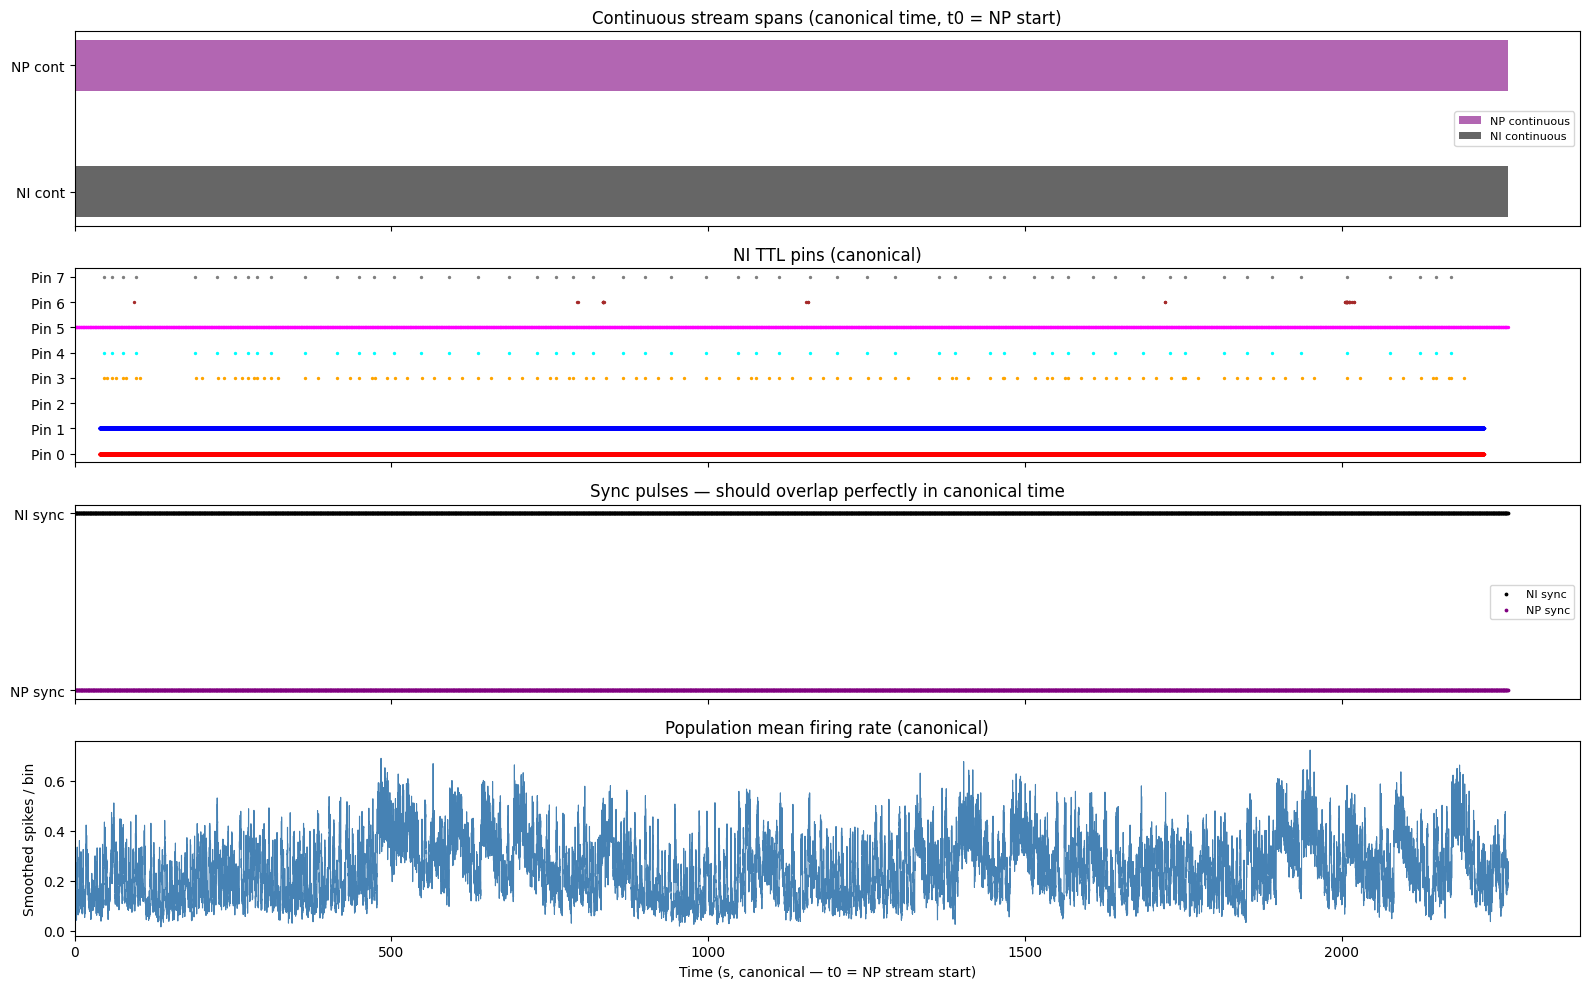

===== CELL A COMPLETE =====



In [1]:
# ============================================================
# =======================  CELL A  ============================
# ========== ROOT CELL — TTLs + QC + PORTABLE SPIKES =========
# ========== WITH NP ↔ NI CLOCK ALIGNMENT (SYNC) =============
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====")

# ------------------------------------------------------------
# USER INPUTS
# ------------------------------------------------------------

SESSION_FOLDER = r"D:\Kevin\03032026"

NI_TTL_FOLDER = r"G:\Kevin\2026-03-03_10-26-01\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL"
PROBEA_PATH   = r"G:\Kevin\2026-03-03_10-26-01\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4"

EXPERIMENT_NUMBER = 1

CAMERA_TTL_PIN = 1
EXPECTED_RATE_HZ = 60
MISSING_TTL_THRESHOLD = 60
MIN_BLOCK_LENGTH = 500

FILENAME_PATTERN = r"frame_(\d+)_cnt_(\d+)\.raw"

NI_SYNC_BIT = 5
NP_SYNC_BIT = 0

NP_SAMPLE_RATE = 30000.0

print("User inputs loaded.")

# ------------------------------------------------------------
# UNIFIED ANALYSIS FOLDER
# ------------------------------------------------------------

def find_session_root(path):
    path = Path(path).resolve()
    while True:
        if "record node" in path.name.lower():
            return path
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find 'Record Node' folder above given path")
        path = parent

def build_analysis_folder(session_root, experiment_number):
    experiment_folders = sorted(
        [f for f in session_root.iterdir()
         if f.is_dir() and f.name.lower().startswith("experiment")],
        key=lambda p: p.name
    )
    if experiment_number < 1 or experiment_number > len(experiment_folders):
        raise RuntimeError(f"Experiment {experiment_number} not found.")
    experiment_folder = experiment_folders[experiment_number - 1]
    recording_folders = sorted(
        [f for f in experiment_folder.iterdir()
         if f.is_dir() and f.name.lower().startswith("recording")],
        key=lambda p: p.name
    )
    if not recording_folders:
        raise RuntimeError("No recording folder found.")
    recording_folder = recording_folders[0]
    session_date = session_root.parent.name
    folder_name = f"{session_date}_{experiment_folder.name}_{recording_folder.name}_analysis"
    analysis_folder = session_root / folder_name
    analysis_folder.mkdir(exist_ok=True)
    for sf in ["qc","camera_alignment","dlc_alignment","behavior_ttls",
               "peak_detection","metadata","ttls","spikes"]:
        (analysis_folder / sf).mkdir(exist_ok=True)
    print(f"Analysis folder: {analysis_folder}")
    return analysis_folder

analysis_folder = build_analysis_folder(
    find_session_root(PROBEA_PATH), EXPERIMENT_NUMBER
)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def save_incrementing(folder, base_name, array):
    folder = Path(folder)
    folder.mkdir(exist_ok=True)
    path = folder / f"{base_name}.npy"
    if not path.exists():
        np.save(path, array)
        return path
    counter = 1
    while True:
        path = folder / f"{base_name}_{counter}.npy"
        if not path.exists():
            np.save(path, array)
            return path
        counter += 1

def extract_rising_edges(full_words, timestamps, pin):
    mask = 1 << pin
    bit_on = (full_words & mask) > 0
    bit_prev = np.roll(bit_on, 1)
    bit_prev[0] = False
    rising = (~bit_prev) & bit_on
    return timestamps[rising]

# ------------------------------------------------------------
# LOAD CONTINUOUS TIMESTAMPS
# ------------------------------------------------------------

ni_ttl_folder    = Path(NI_TTL_FOLDER)
ni_device_name   = ni_ttl_folder.parent.name            # NI-DAQmx-106.PXIe-6341
recording_root   = ni_ttl_folder.parents[2]             # .../experiment2/recording1
ni_cont_folder   = recording_root / "continuous" / ni_device_name
probe_cont_folder = Path(PROBEA_PATH).parent            # .../Neuropix-PXI-107.ProbeA

ni_cont_timestamps = np.load(ni_cont_folder   / "timestamps.npy")
np_cont_timestamps = np.load(probe_cont_folder / "timestamps.npy")

ni_start_abs = float(ni_cont_timestamps[0])
ni_end_abs   = float(ni_cont_timestamps[-1])
np_start_abs = float(np_cont_timestamps[0])
np_end_abs   = float(np_cont_timestamps[-1])

print(f"\nNI continuous (absolute): {ni_start_abs:.6f} → {ni_end_abs:.6f} s")
print(f"NP continuous (absolute): {np_start_abs:.6f} → {np_end_abs:.6f} s")

# ============================================================
# CANONICAL TIMEBASE DECISION
# ============================================================
# We use the NP continuous start as t0 (our ground truth).
# Everything — spikes, TTLs, DLC — will be expressed as seconds
# elapsed since the NP recording began.
#
# Why NP and not NI?
#   - Kilosort spike_times.npy is in NP samples from NP stream start.
#   - The NP stream is always the longest / most complete signal.
#   - All other signals get mapped into this frame.
# ============================================================

t0 = np_start_abs   # canonical zero = NP stream start (absolute clock)

print(f"\nCanonical t0 = NP stream start = {t0:.6f} s (absolute)")
print(f"NI stream starts {ni_start_abs - t0:+.6f} s relative to t0")
# Positive → NI started after NP (common if NP armed first)

# ------------------------------------------------------------
# SYNC PULSE ALIGNMENT: verify NP↔NI are on same clock
# ------------------------------------------------------------

print("\n===== NP ↔ NI SYNC ALIGNMENT =====")

timestamps_ni_ttl = np.load(ni_ttl_folder / "timestamps.npy")
full_words_ni     = np.load(ni_ttl_folder / "full_words.npy")

# Derive NP TTL folder from PROBEA_PATH, not hardcoded.
# The NP TTL folder is at: <record_node>/<experiment>/<recording>/events/<probe_device>/TTL
# The probe continuous folder is at: .../continuous/<probe_device>/
# So np_device_name = probe_cont_folder.name
# And the NP TTL recording root = probe_cont_folder.parents[1]
# (one level up from "continuous", landing on "recording1")

np_device_name    = probe_cont_folder.name                # e.g. "Neuropix-PXI-100.ProbeA"
np_recording_root = probe_cont_folder.parents[1]          # .../experimentN/recording1
np_ttl_folder     = np_recording_root / "events" / np_device_name / "TTL"

print(f"NI TTL folder: {ni_ttl_folder}")
print(f"NP TTL folder: {np_ttl_folder}")

if not np_ttl_folder.exists():
    raise FileNotFoundError(
        f"NP TTL folder not found:\n  {np_ttl_folder}\n"
        f"Check that PROBEA_PATH points to the correct kilosort4 folder."
    )

timestamps_np_ttl = np.load(np_ttl_folder / "timestamps.npy")
full_words_np     = np.load(np_ttl_folder / "full_words.npy")

sync_times_ni_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, NI_SYNC_BIT)
sync_times_np_abs = extract_rising_edges(full_words_np, timestamps_np_ttl, NP_SYNC_BIT)

print(f"NI sync pulses (bit {NI_SYNC_BIT}): {len(sync_times_ni_abs)}")
print(f"NP sync pulses (bit {NP_SYNC_BIT}): {len(sync_times_np_abs)}")

if len(sync_times_ni_abs) == 0:
    raise RuntimeError("No NI sync pulses found.")
if len(sync_times_np_abs) == 0:
    raise RuntimeError("No NP sync pulses found.")

n_common = min(len(sync_times_np_abs), len(sync_times_ni_abs))
sync_np  = sync_times_np_abs[:n_common]
sync_ni  = sync_times_ni_abs[:n_common]

A_mat = np.vstack([sync_np, np.ones_like(sync_np)]).T
a_fit, b_fit = np.linalg.lstsq(A_mat, sync_ni, rcond=None)[0]
residuals = sync_ni - (a_fit * sync_np + b_fit)

print(f"\nLinear fit: t_NI = {a_fit:.9f} * t_NP + {b_fit:.9f}")
print(f"Residuals  mean={np.mean(residuals)*1000:.4f} ms  "
      f"std={np.std(residuals)*1000:.4f} ms  "
      f"max={np.max(np.abs(residuals))*1000:.4f} ms")

# With a≈1 and b≈0 (same clock), the fit confirms the two streams share
# the OpenEphys master clock.  We still apply it for correctness in case
# there is any tiny drift.

# Save alignment metadata
align_meta = {
    "np_to_ni_a": float(a_fit),
    "np_to_ni_b": float(b_fit),
    "n_pulses": int(n_common),
    "residual_mean_s": float(np.mean(residuals)),
    "residual_std_s":  float(np.std(residuals)),
    "residual_max_abs_s": float(np.max(np.abs(residuals))),
    "ni_sync_bit": int(NI_SYNC_BIT),
    "np_sync_bit": int(NP_SYNC_BIT),
    "t0_abs": float(t0),
    "ni_start_abs": float(ni_start_abs),
    "np_start_abs": float(np_start_abs),
    "ni_start_rel": float(ni_start_abs - t0),
    "ni_end_rel":   float(ni_end_abs   - t0),
    "np_start_rel": 0.0,
    "np_end_rel":   float(np_end_abs   - t0),
}
with open(analysis_folder / "metadata" / "np_ni_alignment.json", "w") as f:
    json.dump(align_meta, f, indent=2)
print(f"\nSaved alignment metadata.")

# ============================================================
# UNIFIED CONVERSION FUNCTIONS
# ============================================================
# All downstream code should use these — never subtract t0 manually.

def np_samples_to_canonical(samples):
    """Kilosort spike_times (NP samples) → canonical seconds."""
    # samples / sample_rate  → seconds from NP stream start (already = t0)
    # No further offset needed because t0 IS np_start_abs and
    # OpenEphys sample indices start at the stream start.
    return samples / NP_SAMPLE_RATE

def np_abs_to_canonical(t_np_abs):
    """NP absolute time → canonical seconds."""
    return t_np_abs - t0

def ni_abs_to_canonical(t_ni_abs):
    """NI absolute time → canonical seconds."""
    return t_ni_abs - t0

# Canonical duration = full NP recording
recording_duration = float(np_end_abs - t0)
print(f"\nRecording duration (canonical): {recording_duration:.3f} s")

# ============================================================
# CRITICAL DIAGNOSTIC: verify spike time anchor
# ============================================================
# Load spike_times.npy and check that the first and last spikes
# fall within [0, recording_duration].  If they fall within
# [-ni_start_rel, recording_duration - ni_start_rel] instead,
# that means Kilosort spike_times are in NI-absolute samples,
# and you need to subtract the NP stream start offset.
# ============================================================

spike_times_raw = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
spike_times_sec_raw = spike_times_raw / NP_SAMPLE_RATE

ni_start_rel = ni_start_abs - t0   # typically a small positive number

print(f"\n===== SPIKE TIME ANCHOR DIAGNOSTIC =====")
print(f"NI stream offset from NP start: {ni_start_rel:+.6f} s")
print(f"First 5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[:5]}")
print(f"Last  5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[-5:]}")
print(f"Expected canonical range: 0 → {recording_duration:.3f} s")
print(f"If spikes appear in range {-ni_start_rel:.3f} → "
      f"{recording_duration - ni_start_rel:.3f} s")
print(f"  → spike_times are anchored to NI start, not NP start.")
print(f"  → You need: spike_canonical = spikes_sec - {ni_start_rel:.6f}")
print(f"If spikes appear in range 0 → {recording_duration:.3f} s")
print(f"  → spike_times are anchored to NP start (correct, no adjustment).")

# Auto-detect anchor and apply correct conversion
spike_min = float(spike_times_sec_raw.min())
spike_max = float(spike_times_sec_raw.max())

# Auto-detect anchor and apply correct conversion
spike_min = float(spike_times_sec_raw.min())
spike_max = float(spike_times_sec_raw.max())

# Three possible anchors to test:
#   1. NP start (canonical t0): spikes in [0, recording_duration]
#   2. NI start: spikes in [-ni_start_rel, recording_duration - ni_start_rel]
#   3. Absolute OpenEphys clock: spikes in [np_start_abs, np_end_abs]
#
# Test each by checking spike_min and spike_max consistency.

np_anchor_match = abs(spike_min) < 5.0 and spike_max <= recording_duration + 5.0
ni_anchor_match = (abs(spike_min - ni_start_rel) < 5.0 and
                   abs(spike_max - (recording_duration - ni_start_rel)) < 5.0)
abs_anchor_match = (abs(spike_min - np_start_abs) < 5.0 and
                    abs(spike_max - np_end_abs) < 5.0)

if np_anchor_match:
    print("\n→ AUTO-DETECTED: spikes anchored to NP start. No offset needed.")
    spike_anchor_offset = 0.0
elif ni_anchor_match:
    print(f"\n→ AUTO-DETECTED: spikes anchored to NI start. "
          f"Applying offset of -{ni_start_rel:.6f} s.")
    spike_anchor_offset = ni_start_rel
elif abs_anchor_match:
    print(f"\n→ AUTO-DETECTED: spikes anchored to ABSOLUTE OpenEphys clock. "
          f"Applying offset of -{np_start_abs:.6f} s.")
    spike_anchor_offset = np_start_abs
else:
    print(f"\n→ WARNING: spike anchor unclear.")
    print(f"  spike_min={spike_min:.3f}, spike_max={spike_max:.3f}")
    print(f"  NP-anchored expected: [0, {recording_duration:.3f}]")
    print(f"  NI-anchored expected: [{-ni_start_rel:.3f}, {recording_duration - ni_start_rel:.3f}]")
    print(f"  Absolute-anchored expected: [{np_start_abs:.3f}, {np_end_abs:.3f}]")
    print(f"  Defaulting to 0 offset — PLEASE VERIFY MANUALLY.")
    spike_anchor_offset = 0.0

print(f"spike_anchor_offset = {spike_anchor_offset:.6f} s")

print(f"spike_anchor_offset = {spike_anchor_offset:.6f} s")

def spikes_to_canonical(spike_samples):
    """Full pipeline: NP samples → canonical seconds."""
    return spike_samples / NP_SAMPLE_RATE - spike_anchor_offset

# ============================================================
# NI TTL EXTRACTION → canonical time
# ============================================================

print("\n===== EXTRACTING NI TTLs → CANONICAL TIME =====")

ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}   # canonical seconds

for pin in range(8):
    ttls_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, pin)
    ttls_can = ni_abs_to_canonical(ttls_abs)
    all_pin_ttls[pin] = ttls_can
    save_incrementing(ttls_dir, f"TTL_Pin_{pin}", ttls_can)
    print(f"  Pin {pin}: {len(ttls_can)} TTLs", end="")
    if len(ttls_can):
        print(f"  range {ttls_can[0]:.3f} → {ttls_can[-1]:.3f} s")
    else:
        print()

ni_meta = {
    "canonical_t0_is": "NP stream start (np_start_abs)",
    "t0_abs": float(t0),
    "ni_start_canonical": float(ni_start_abs - t0),
    "ni_end_canonical":   float(ni_end_abs   - t0),
    "np_start_canonical": 0.0,
    "np_end_canonical":   float(np_end_abs   - t0),
    "recording_duration": float(recording_duration),
    "camera_ttl_pin": int(CAMERA_TTL_PIN),
    "expected_rate_hz": EXPECTED_RATE_HZ,
    "spike_anchor_offset_s": float(spike_anchor_offset),
}
with open(analysis_folder / "metadata" / "ttl_metadata.json", "w") as f:
    json.dump(ni_meta, f, indent=2)
print("Saved TTL metadata.")

# ============================================================
# TTL BLOCK DETECTION
# ============================================================

print("\n===== TTL BLOCK DETECTOR =====")

rising_times = all_pin_ttls[CAMERA_TTL_PIN]
print(f"Camera pin {CAMERA_TTL_PIN}: {len(rising_times)} rising edges")

ipi           = np.diff(rising_times)
expected_ipi  = 1.0 / EXPECTED_RATE_HZ
gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD
gap_indices   = np.where(ipi > gap_threshold)[0]

block_starts = np.insert(gap_indices + 1, 0, 0)
block_ends   = np.append(gap_indices, len(rising_times) - 1)

ttl_blocks = []
block_info = []
cam_align_dir = analysis_folder / "camera_alignment"

for b_idx, (start, end) in enumerate(zip(block_starts, block_ends)):
    block_len = end - start + 1
    if block_len < MIN_BLOCK_LENGTH:
        print(f"  Skipping block {b_idx} (too short: {block_len})")
        continue
    block_times = rising_times[start:end+1]
    ttl_blocks.append(block_times)
    info = {
        "block_index": b_idx,
        "n_ttls": int(block_len),
        "start_canonical": float(block_times[0]),
        "end_canonical":   float(block_times[-1]),
        "duration_s":      float(block_times[-1] - block_times[0]),
    }
    block_info.append(info)
    save_incrementing(cam_align_dir, f"ttl_times_block{b_idx}", block_times)
    print(f"  Block {b_idx}: {block_len} TTLs, "
          f"{block_times[0]:.3f} → {block_times[-1]:.3f} s (canonical)")

with open(analysis_folder / "metadata" / "block_info.json", "w") as f:
    json.dump(block_info, f, indent=2)

# ============================================================
# QC: FIRING-RATE MATRIX
# ============================================================

print("\n===== QC: FIRING-RATE MATRIX =====")

qc_dir        = analysis_folder / "qc"
spikes_dir    = analysis_folder / "spikes"

rate_path          = qc_dir / "rate_matrix.npy"
good_units_path    = qc_dir / "good_units.npy"
centers_path       = qc_dir / "centers.npy"
duration_path      = qc_dir / "recording_duration.json"
noise_units_path   = qc_dir / "noise_units.npy"
noise_rate_path    = qc_dir / "noise_rate_matrix.npy"
spike_anchor_path  = qc_dir / "spike_anchor_offset.json"

all_qc_exist = all(p.exists() for p in [
    rate_path, good_units_path, centers_path, duration_path,
    noise_units_path, noise_rate_path
])

if all_qc_exist:
    print("QC files already exist — skipping.")
else:
    print("Computing QC...")

    spike_times_raw  = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
    spike_clusters   = np.load(Path(PROBEA_PATH) / "spike_clusters.npy").flatten()
    spike_times_can  = spikes_to_canonical(spike_times_raw)  # canonical seconds

    print(f"Spike time canonical range: "
          f"{spike_times_can.min():.3f} → {spike_times_can.max():.3f} s")
    print(f"Recording duration:          0.000 → {recording_duration:.3f} s")

    if spike_times_can.max() < recording_duration * 0.9:
        print("WARNING: spikes end well before recording end — "
              "check spike_anchor_offset!")
    if spike_times_can.min() < -1.0:
        print("WARNING: spikes start before t=0 — check spike_anchor_offset!")

    df_info    = pd.read_csv(Path(PROBEA_PATH) / "cluster_info.tsv", sep="\t")
    good_units = df_info[df_info["group"] == "good"]["id"].values
    np.save(good_units_path, good_units)
    print(f"Good units: {len(good_units)}")

    for unit in good_units:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"unit_{unit}.npy", unit_spikes)

# Sample noise units matched to the number of good units
# (so downstream noise-vs-real comparisons have equal sample sizes)
    noise_units_all = df_info[df_info["group"] == "noise"]["id"].values
    print(f"Total noise units available: {len(noise_units_all)}")

# Filter noise units by minimum firing rate, same way good units would be
# filtered downstream. This ensures the noise pool we sample from is
# comparable in firing-rate distribution to the good pool.
    noise_rates = np.array([
        (spike_clusters == u).sum() / recording_duration
        for u in noise_units_all
    ])
    NOISE_MIN_RATE_HZ = 0.5  # matches a permissive floor; tightened downstream
    eligible_noise = noise_units_all[noise_rates >= NOISE_MIN_RATE_HZ]
    print(f"Noise units with ≥{NOISE_MIN_RATE_HZ} Hz: {len(eligible_noise)}")

# Sample N_target noise units matched to good unit count
    N_target = len(good_units)
    np.random.seed(0)
    if len(eligible_noise) >= N_target:
        sampled_noise = np.random.choice(eligible_noise, size=N_target, replace=False)
        print(f"Sampled {N_target} noise units (matched to good unit count).")
    else:
        sampled_noise = eligible_noise
        print(f"WARNING: only {len(eligible_noise)} eligible noise units available "
              f"(wanted {N_target}). Using all available.")

    np.save(noise_units_path, sampled_noise)

    for unit in sampled_noise:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"noise_unit_{unit}.npy", unit_spikes)
    print(f"Saved {len(sampled_noise)} noise unit spike trains to disk.")

    # Save spike anchor for downstream cells
    with open(spike_anchor_path, "w") as f:
        json.dump({"spike_anchor_offset_s": float(spike_anchor_offset),
                   "t0_abs": float(t0)}, f, indent=2)

    # Time bins over full NP recording
    bin_size = 0.02
    bins    = np.arange(0, recording_duration + bin_size, bin_size)
    centers = bins[:-1] + bin_size / 2
    np.save(centers_path, centers)
    with open(duration_path, "w") as f:
        json.dump({"recording_duration": recording_duration,
                   "t0_abs": float(t0)}, f, indent=2)

    # Rate matrices
    def make_rate_matrix(unit_list, label):
        mat = np.zeros((len(unit_list), len(centers)), float)
        for i, unit in enumerate(unit_list):
            spk = spike_times_can[spike_clusters == unit]
            h, _ = np.histogram(spk, bins=bins)
            mat[i] = gaussian_filter1d(h.astype(float), sigma=2)
        return mat

    rate_matrix       = make_rate_matrix(good_units,   "good")
    noise_rate_matrix = make_rate_matrix(sampled_noise,"noise")
    np.save(rate_path,       rate_matrix)
    np.save(noise_rate_path, noise_rate_matrix)
    print(f"Saved rate_matrix {rate_matrix.shape}")
    print(f"Saved noise_rate_matrix {noise_rate_matrix.shape}")

# ============================================================
# DIAGNOSTIC PLOT — canonical timeline
# ============================================================

print("\n===== CANONICAL TIMELINE DIAGNOSTIC =====")

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# Row 0: NP and NI continuous spans
for ax in axes[:1]:
    ax.barh(1, recording_duration,       left=0,
            height=0.4, color='purple', alpha=0.6, label="NP continuous")
    ax.barh(0, ni_end_abs - t0,          left=ni_start_abs - t0,
            height=0.4, color='black',  alpha=0.6, label="NI continuous")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["NI cont", "NP cont"])
    ax.legend(fontsize=8)
    ax.set_title("Continuous stream spans (canonical time, t0 = NP start)")

# Row 1: TTL pins
colors8 = ['red','blue','green','orange','cyan','magenta','brown','gray']
ax1 = axes[1]
for pin in range(8):
    tt = all_pin_ttls[pin]
    ax1.scatter(tt, np.full_like(tt, pin), s=2, color=colors8[pin],
                label=f"Pin {pin}")
ax1.set_yticks(range(8))
ax1.set_yticklabels([f"Pin {p}" for p in range(8)])
ax1.set_title("NI TTL pins (canonical)")

# Row 2: sync pulses overlap check
ax2 = axes[2]
sync_ni_can  = ni_abs_to_canonical(sync_times_ni_abs)
sync_np_can  = np_abs_to_canonical(sync_times_np_abs)
ax2.scatter(sync_ni_can, np.ones_like(sync_ni_can)*1,
            s=3, color='black', label="NI sync")
ax2.scatter(sync_np_can, np.ones_like(sync_np_can)*0,
            s=3, color='purple', label="NP sync")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["NP sync","NI sync"])
ax2.set_title("Sync pulses — should overlap perfectly in canonical time")
ax2.legend(fontsize=8)

# Row 3: spike density
ax3 = axes[3]
if centers_path.exists():
    centers_saved = np.load(centers_path)
    rm = np.load(rate_path)
    ax3.plot(centers_saved, rm.mean(axis=0), color='steelblue', lw=0.8)
    ax3.set_title("Population mean firing rate (canonical)")
    ax3.set_ylabel("Smoothed spikes / bin")

axes[-1].set_xlabel("Time (s, canonical — t0 = NP stream start)")
plt.tight_layout()
plt.show()

print("===== CELL A COMPLETE =====\n")

In [2]:
# ============================================================
# CELL B — FRAME ALIGNMENT (RIG-ONLY) — CORRECTED
# ============================================================
# Camera behavior assumed (confirmed by Kevin):
#   - frame_idx resets to 0 each block; contiguous (no gaps)
#   - first saved frame == TTL #0 of the block
#   - cnt is a free-running counter (offset is arbitrary).
#     Drops show up as gaps in cnt.
#
# Mapping: saved frame at position p
#          → ttl_index_in_block = cnt[p] - cnt[0]
#          → canonical_time     = ttl_times_block[cnt[p] - cnt[0]]
# ============================================================
import os, re, json
import numpy as np
from pathlib import Path

print("\n===== CELL B — FRAME ALIGNMENT (RIG) =====")

required_vars = ["analysis_folder", "ttl_blocks", "FILENAME_PATTERN"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"'{v}' missing — run Cell A first.")

# ------------------------------------------------------------
# USER EDIT — camera folder per block
# ------------------------------------------------------------
CAM_FOLDERS = {
    0: r"D:\Kevin\03032026\03032026-2\cam2",
}
# ------------------------------------------------------------

if len(CAM_FOLDERS) != len(ttl_blocks):
    raise ValueError(f"CAM_FOLDERS has {len(CAM_FOLDERS)} entries "
                     f"but there are {len(ttl_blocks)} TTL blocks.")
if set(CAM_FOLDERS.keys()) != set(range(len(ttl_blocks))):
    raise ValueError(f"CAM_FOLDERS keys must be {set(range(len(ttl_blocks)))}.")
for b, p in CAM_FOLDERS.items():
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Camera folder for block {b} missing: {p}")

PATTERN = re.compile(FILENAME_PATTERN)
cam_align_dir = analysis_folder / "camera_alignment"
cam_align_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# PROCESS EACH BLOCK
# ------------------------------------------------------------
for block_index, ttl_times_block in enumerate(ttl_blocks):

    print(f"\n--- Block {block_index} ---")
    cam_folder = CAM_FOLDERS[block_index]
    n_ttls = len(ttl_times_block)
    print(f"TTLs in block: {n_ttls}")
    print(f"Camera folder: {cam_folder}")

    # Scan filenames
    entries = []
    for fname in os.listdir(cam_folder):
        m = PATTERN.match(fname)
        if m:
            entries.append((int(m.group(1)), int(m.group(2)), fname))
    if not entries:
        raise RuntimeError(f"No matching files in {cam_folder}")

    entries.sort(key=lambda e: e[1])  # sort by cnt
    frame_idx_arr = np.array([e[0] for e in entries], dtype=np.int64)
    cnt_arr       = np.array([e[1] for e in entries], dtype=np.int64)

    n_saved   = len(entries)
    first_cnt = int(cnt_arr[0])
    last_cnt  = int(cnt_arr[-1])
    cnt_span  = last_cnt - first_cnt + 1   # TTLs covered by camera save window

    print(f"Saved frames: {n_saved}")
    print(f"frame_idx range: {int(frame_idx_arr[0])} → {int(frame_idx_arr[-1])}")
    print(f"cnt range: {first_cnt} → {last_cnt}")
    print(f"cnt span (TTLs covered by camera): {cnt_span}")
    print(f"Implied drops within camera window: {cnt_span - n_saved}")

    # ----- Invariant 1: first frame_idx must be 0 -----
    if int(frame_idx_arr[0]) != 0:
        raise RuntimeError(
            f"Block {block_index}: first saved frame has frame_idx="
            f"{int(frame_idx_arr[0])}, expected 0. Camera should reset "
            f"frame_idx to 0 at block start."
        )

    # ----- Invariant 2: frame_idx contiguous (no gaps) -----
    fidx_gaps = np.where(np.diff(frame_idx_arr) != 1)[0]
    if len(fidx_gaps) > 0:
        raise RuntimeError(
            f"Block {block_index}: frame_idx has gaps at positions "
            f"{fidx_gaps[:5].tolist()}{'...' if len(fidx_gaps) > 5 else ''}. "
            f"frame_idx should be contiguous; drops live in cnt only."
        )

    # ----- Invariant 3: cnt span fits within TTL block -----
    # The camera can stop saving before the last TTL (trailing TTLs are
    # benign). It must NOT extend past the TTL block.
    if cnt_span > n_ttls:
        raise RuntimeError(
            f"Block {block_index}: cnt span ({cnt_span}) exceeds TTL count "
            f"({n_ttls}). The camera appears to have received more TTLs "
            f"than the TTL detector found, which means the block "
            f"boundaries are wrong."
        )

    # ----- Invariant 4: how much TTL hangs off the end? Report it. -----
    trailing_ttls = n_ttls - cnt_span
    trailing_secs = (ttl_times_block[-1] - ttl_times_block[cnt_span - 1]
                     if cnt_span > 0 else 0.0)
    print(f"Trailing TTLs after camera stopped: {trailing_ttls} "
          f"(~{trailing_secs:.2f} s)")
    if trailing_ttls > n_ttls * 0.1:
        print(f"  WARNING: more than 10% of TTLs are trailing. "
              f"Check that you didn't stop the camera way before "
              f"stopping OpenEphys.")

    # ------------------------------------------------------------
    # CORE MAPPING
    # ------------------------------------------------------------
    # For each saved frame, compute its TTL index in the block
    # and look up the canonical time.
    # ------------------------------------------------------------
    ttl_idx_in_block = cnt_arr - first_cnt          # shape (n_saved,)
    frame_canonical_times = ttl_times_block[ttl_idx_in_block]

    # Sanity: monotonic increasing
    if not np.all(np.diff(frame_canonical_times) > 0):
        raise RuntimeError(
            f"Block {block_index}: frame canonical times are not strictly "
            f"increasing. This indicates a sorting or cnt error."
        )

    # ------------------------------------------------------------
    # SAVE PORTABLE ARRAYS
    # ------------------------------------------------------------
    np.save(cam_align_dir / f"frame_cnt_block{block_index}.npy", cnt_arr)
    np.save(cam_align_dir / f"frame_canonical_times_block{block_index}.npy",
            frame_canonical_times)

    print(f"Wrote frame_cnt_block{block_index}.npy "
          f"and frame_canonical_times_block{block_index}.npy")
    print(f"Frame canonical time range: "
          f"{frame_canonical_times[0]:.3f} → {frame_canonical_times[-1]:.3f} s")

# ------------------------------------------------------------
# Save frame-alignment metadata
# ------------------------------------------------------------
frame_meta = {
    str(b): {
        "cam_folder": CAM_FOLDERS[b],
        "n_saved_frames": int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy").size),
        "n_ttls": int(len(ttl_blocks[b])),
        "first_cnt": int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy")[0]),
        "last_cnt":  int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy")[-1]),
    }
    for b in range(len(ttl_blocks))
}
with open(analysis_folder / "metadata" / "frame_alignment.json", "w") as f:
    json.dump(frame_meta, f, indent=2)

print("\n===== CELL B COMPLETE — RIG WORK DONE =====")
print("Everything below this point is portable.\n")


===== CELL B — FRAME ALIGNMENT (RIG) =====

--- Block 0 ---
TTLs in block: 130927
Camera folder: D:\Kevin\03032026\03032026-2\cam2
Saved frames: 130925
frame_idx range: 0 → 130924
cnt range: 221154 → 352078
cnt span (TTLs covered by camera): 130925
Implied drops within camera window: 0
Trailing TTLs after camera stopped: 2 (~0.03 s)
Wrote frame_cnt_block0.npy and frame_canonical_times_block0.npy
Frame canonical time range: 40.202 → 2223.363 s

===== CELL B COMPLETE — RIG WORK DONE =====
Everything below this point is portable.



In [2]:
# ============================================================
# CELL C — SESSION BUILDER (PORTABLE)
# ============================================================
# First cell after the rig/home line. Defines DLC paths and
# writes session.json with all metadata needed for downstream
# analysis. Loads ttl_blocks etc. from disk if not in kernel.
# ============================================================
import os, json
import numpy as np
from pathlib import Path

print("\n===== CELL C — SESSION BUILDER (PORTABLE) =====")

# ------------------------------------------------------------
# USER EDIT — set analysis_folder if running on home machine
# ------------------------------------------------------------
# If you've just opened this notebook fresh on your home laptop,
# uncomment and edit this line:
analysis_folder = Path(r"G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis")
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set `analysis_folder` (Path to the analysis folder).")
analysis_folder = Path(analysis_folder)

# ------------------------------------------------------------
# USER EDIT — DLC outputs per block
# ------------------------------------------------------------
DLC_OUTPUTS = {
    0: r"F:\030326-Kevin-2026-05-21\videos\03032026-2_cam2DLC_Resnet50_030326May21shuffle1_snapshot_best-40.h5",
}
# ------------------------------------------------------------

# Pin labels — bake into session so downstream plots auto-label
PIN_LABELS = {
    0: "camera1",
    1: "camera2",
    3: "pellet_motor",   # 2 turns/trial: expose + retract
    4: "tone_cue",
    5: "np_sync_1hz",
    6: "reach_ir_beam",
    7: "manual_pellet_button",
}
CAMERA_TTL_PIN = 1  # this session uses cam2

# ------------------------------------------------------------
# LOAD CELL A METADATA FROM DISK
# ------------------------------------------------------------
with open(analysis_folder / "metadata" / "np_ni_alignment.json") as f:
    align_meta = json.load(f)
with open(analysis_folder / "metadata" / "ttl_metadata.json") as f:
    ttl_meta = json.load(f)
with open(analysis_folder / "metadata" / "block_info.json") as f:
    block_info = json.load(f)
with open(analysis_folder / "metadata" / "frame_alignment.json") as f:
    frame_meta = json.load(f)

# ------------------------------------------------------------
# RELOAD ttl_blocks AND all_pin_ttls FROM DISK IF NEEDED
# ------------------------------------------------------------
cam_align_dir = analysis_folder / "camera_alignment"
ttls_dir = analysis_folder / "ttls"

ttl_blocks = []
for bi in block_info:
    idx = bi["block_index"]
    ttl_blocks.append(np.load(cam_align_dir / f"ttl_times_block{idx}.npy"))

all_pin_ttls = {}
for pin in range(8):
    p = ttls_dir / f"TTL_Pin_{pin}.npy"
    all_pin_ttls[pin] = np.load(p) if p.exists() else np.array([])

# ------------------------------------------------------------
# VALIDATE DLC MAPPING
# ------------------------------------------------------------
if len(DLC_OUTPUTS) != len(ttl_blocks):
    raise ValueError(f"DLC_OUTPUTS has {len(DLC_OUTPUTS)} entries "
                     f"but there are {len(ttl_blocks)} TTL blocks.")
if set(DLC_OUTPUTS.keys()) != set(range(len(ttl_blocks))):
    raise ValueError(f"DLC_OUTPUTS keys must be {set(range(len(ttl_blocks)))}.")
for b, path in DLC_OUTPUTS.items():
    if not os.path.isfile(path):
        raise FileNotFoundError(f"DLC file for block {b} missing: {path}")

# ------------------------------------------------------------
# BUILD SESSION OBJECT
# ------------------------------------------------------------
session = {
    "canonical_t0_abs":         align_meta["t0_abs"],
    "canonical_t0_description": "NP stream start (absolute OpenEphys clock seconds)",
    "recording_duration_s":     ttl_meta["recording_duration"],
    "spike_anchor_offset_s":    ttl_meta["spike_anchor_offset_s"],
    "np_to_ni_a":               align_meta["np_to_ni_a"],
    "np_to_ni_b":               align_meta["np_to_ni_b"],
    "camera_ttl_pin":           CAMERA_TTL_PIN,
    "pin_labels":               PIN_LABELS,
    "blocks": []
}

for block_index, ttl_times_block in enumerate(ttl_blocks):
    fm = frame_meta[str(block_index)]
    session["blocks"].append({
        "block_index":              block_index,
        "n_ttls":                   int(len(ttl_times_block)),
        "n_saved_frames":           int(fm["n_saved_frames"]),
        "start_canonical":          float(ttl_times_block[0]),
        "end_canonical":            float(ttl_times_block[-1]),
        "ttl_times_path":           str(cam_align_dir / f"ttl_times_block{block_index}.npy"),
        "frame_cnt_path":           str(cam_align_dir / f"frame_cnt_block{block_index}.npy"),
        "frame_canonical_times_path": str(cam_align_dir / f"frame_canonical_times_block{block_index}.npy"),
        "dlc_path":                 DLC_OUTPUTS[block_index],
        "dlc_canonical_path":       str(analysis_folder / "dlc_alignment" / f"dlc_canonical_block{block_index}.npz"),
    })

session_path = analysis_folder / "metadata" / "session.json"
with open(session_path, "w") as f:
    json.dump(session, f, indent=2)

print(f"Saved session.json → {session_path}")
print(f"\nSession summary:")
print(f"  canonical t0 (abs):  {session['canonical_t0_abs']:.6f} s")
print(f"  recording duration:  {session['recording_duration_s']:.3f} s")
print(f"  spike_anchor_offset: {session['spike_anchor_offset_s']:.6f} s")
print(f"  camera TTL pin:      {session['camera_ttl_pin']}")
for b in session["blocks"]:
    print(f"  Block {b['block_index']}: {b['n_ttls']} TTLs, "
          f"{b['n_saved_frames']} saved frames, "
          f"{b['start_canonical']:.3f} → {b['end_canonical']:.3f} s")

print("\n===== CELL C COMPLETE =====\n")


===== CELL C — SESSION BUILDER (PORTABLE) =====


FileNotFoundError: DLC file for block 0 missing: F:\030326-Kevin-2026-05-21\videos\03032026-2_cam2DLC_Resnet50_030326May21shuffle1_snapshot_best-40.h5

In [4]:
# ============================================================
# CELL D — DLC ↔ CANONICAL ALIGNMENT (PORTABLE)
# ============================================================
# For each block, reads the DLC .h5 (one row per saved frame in
# MP4 order, matches frame_idx because frame_idx is contiguous)
# and writes dlc_canonical_block{N}.npz containing:
#   canonical_time   : (n_saved,) float64
#   bodyparts        : list of bodypart names
#   {bp}_x, {bp}_y, {bp}_likelihood : (n_saved,) float32 each
# ============================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path

print("\n===== CELL D — DLC ↔ CANONICAL ALIGNMENT =====")

if "analysis_folder" not in globals():
    raise RuntimeError("Run Cell C first (or set analysis_folder).")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

dlc_dir = analysis_folder / "dlc_alignment"
dlc_dir.mkdir(exist_ok=True)

for block in session["blocks"]:
    b = block["block_index"]
    print(f"\n--- Block {b} ---")

    frame_can_times = np.load(block["frame_canonical_times_path"])
    n_saved = len(frame_can_times)
    print(f"Saved frames (from frame_canonical_times): {n_saved}")

    dlc_path = Path(block["dlc_path"])
    print(f"Loading DLC: {dlc_path.name}")
    df = pd.read_hdf(dlc_path)
    n_rows = len(df)
    print(f"DLC rows: {n_rows}")

    if n_rows != n_saved:
        raise RuntimeError(
            f"Block {b}: DLC has {n_rows} rows but {n_saved} frames were "
            f"saved. They must match (DLC processes saved frames in order). "
            f"Common causes: DLC was run on a different video, or some "
            f"frames were trimmed before DLC."
        )

    # MultiIndex: (scorer, bodypart, coord). Pull bodyparts list.
    bodyparts = list(dict.fromkeys(df.columns.get_level_values("bodyparts")))
    print(f"Bodyparts found: {bodyparts}")

    out = {"canonical_time": frame_can_times.astype(np.float64),
           "bodyparts": np.array(bodyparts)}

    scorer = df.columns.get_level_values("scorer")[0]
    for bp in bodyparts:
        out[f"{bp}_x"]          = df[(scorer, bp, "x")].to_numpy(dtype=np.float32)
        out[f"{bp}_y"]          = df[(scorer, bp, "y")].to_numpy(dtype=np.float32)
        out[f"{bp}_likelihood"] = df[(scorer, bp, "likelihood")].to_numpy(dtype=np.float32)

    out_path = Path(block["dlc_canonical_path"])
    np.savez(out_path, **out)
    print(f"Saved → {out_path.name}")
    print(f"Time range: {frame_can_times[0]:.3f} → {frame_can_times[-1]:.3f} s")

print("\n===== CELL D COMPLETE =====\n")


===== CELL D — DLC ↔ CANONICAL ALIGNMENT =====

--- Block 0 ---
Saved frames (from frame_canonical_times): 130925
Loading DLC: 03032026-2_cam2DLC_Resnet50_030326May21shuffle1_snapshot_best-40.h5
DLC rows: 130925
Bodyparts found: ['paw', 'digit1', 'digit2', 'nose']
Saved → dlc_canonical_block0.npz
Time range: 40.202 → 2223.363 s

===== CELL D COMPLETE =====



In [5]:
# ============================================================
# CELL E — FULL-SESSION DLC TRAJECTORY BUILDER (PORTABLE)
# ============================================================
# Concatenates per-block DLC into one full-session .npz:
#   full_session_dlc.npz
#     canonical_time   : (n_total_saved,)
#     block_index      : (n_total_saved,)
#     {bp}_x, {bp}_y, {bp}_likelihood for each bodypart
#
# After this, NO downstream cell needs to touch DLC .h5 files
# or per-block .npz files. Everything loads from this one file.
# ============================================================
import json
import numpy as np
from pathlib import Path

print("\n===== CELL E — FULL-SESSION DLC BUILDER =====")

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

# Load block 0 first to learn the bodypart list
b0 = session["blocks"][0]
d0 = np.load(b0["dlc_canonical_path"], allow_pickle=True)
bodyparts = [str(x) for x in d0["bodyparts"]]
print(f"Bodyparts: {bodyparts}")

# Concatenate
all_t      = []
all_block  = []
all_data   = {f"{bp}_{coord}": []
              for bp in bodyparts
              for coord in ["x", "y", "likelihood"]}

for block in session["blocks"]:
    b = block["block_index"]
    d = np.load(block["dlc_canonical_path"], allow_pickle=True)
    n = len(d["canonical_time"])
    print(f"  Block {b}: {n} frames, "
          f"{d['canonical_time'][0]:.3f} → {d['canonical_time'][-1]:.3f} s")

    all_t.append(d["canonical_time"])
    all_block.append(np.full(n, b, dtype=np.int16))
    for bp in bodyparts:
        for coord in ["x", "y", "likelihood"]:
            all_data[f"{bp}_{coord}"].append(d[f"{bp}_{coord}"])

out = {
    "canonical_time": np.concatenate(all_t),
    "block_index":    np.concatenate(all_block),
    "bodyparts":      np.array(bodyparts),
}
for k, v in all_data.items():
    out[k] = np.concatenate(v)

out_path = analysis_folder / "dlc_alignment" / "full_session_dlc.npz"
np.savez(out_path, **out)
print(f"\nSaved → {out_path}")
print(f"Total frames: {len(out['canonical_time'])}")
print(f"Time range: {out['canonical_time'][0]:.3f} → {out['canonical_time'][-1]:.3f} s")
print("\n===== CELL E COMPLETE =====\n")


===== CELL E — FULL-SESSION DLC BUILDER =====
Bodyparts: ['paw', 'digit1', 'digit2', 'nose']
  Block 0: 130925 frames, 40.202 → 2223.363 s

Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\dlc_alignment\full_session_dlc.npz
Total frames: 130925
Time range: 40.202 → 2223.363 s

===== CELL E COMPLETE =====




===== CELL F — SANITY PLOTS =====


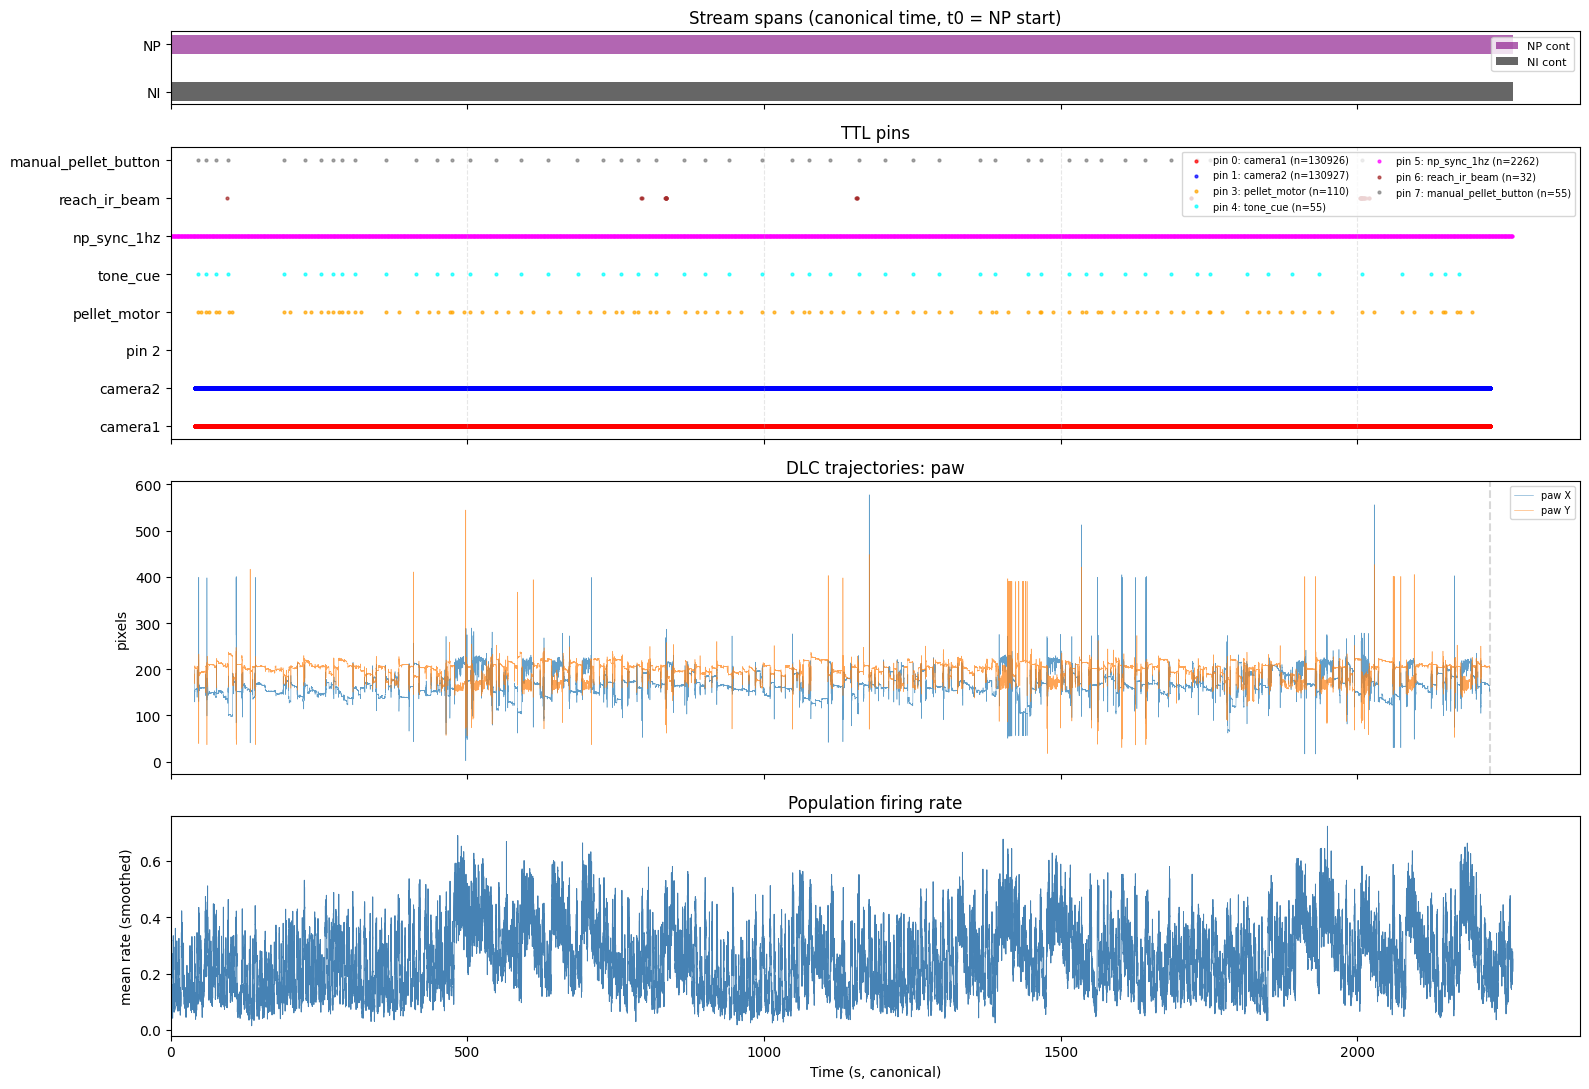


Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\camera_alignment\sanity_overview.png

===== CELL F COMPLETE =====



In [6]:
# ============================================================
# CELL F — SANITY PLOTS (PORTABLE)
# ============================================================
# One figure with: TTL pins raster, frame saved/dropped bar,
# DLC trajectory for selected bodyparts, NP/NI spans.
# Loads only from analysis_folder/ — no raw data needed.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL F — SANITY PLOTS =====")

# ------------------------------------------------------------
# USER EDIT — which bodyparts to overlay
# ------------------------------------------------------------
PLOT_BODYPARTS = ["paw"]
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
with open(analysis_folder / "metadata" / "np_ni_alignment.json") as f:
    align_meta = json.load(f)

pin_labels = session["pin_labels"]
rec_dur    = session["recording_duration_s"]
ni_start   = align_meta["ni_start_rel"]
ni_end     = align_meta["ni_end_rel"]

# Load all TTL pins
ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}
for pin in range(8):
    p = ttls_dir / f"TTL_Pin_{pin}.npy"
    all_pin_ttls[pin] = np.load(p) if p.exists() else np.array([])

# Load full-session DLC
dlc_npz = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
dlc_t = dlc_npz["canonical_time"]

# Load population firing-rate trace
centers = np.load(analysis_folder / "qc" / "centers.npy")
rate_matrix = np.load(analysis_folder / "qc" / "rate_matrix.npy")
pop_rate = rate_matrix.mean(axis=0)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True,
                         gridspec_kw={"height_ratios": [0.5, 2, 2, 1.5]})

# Row 0: NP / NI stream spans
ax = axes[0]
ax.barh(1, rec_dur, left=0, height=0.4, color="purple", alpha=0.6, label="NP cont")
ax.barh(0, ni_end - ni_start, left=ni_start, height=0.4, color="black", alpha=0.6, label="NI cont")
ax.set_yticks([0, 1]); ax.set_yticklabels(["NI", "NP"])
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Stream spans (canonical time, t0 = NP start)")

# Row 1: TTL pin raster, color-coded with labels
ax = axes[1]
colors = ['red','blue','green','orange','cyan','magenta','brown','gray']
for pin in range(8):
    t = all_pin_ttls[pin]
    if len(t) == 0:
        continue
    label = pin_labels.get(str(pin), pin_labels.get(pin, f"pin {pin}"))
    ax.scatter(t, np.full_like(t, pin), s=4, color=colors[pin], alpha=0.7,
               label=f"pin {pin}: {label} (n={len(t)})")
ax.set_yticks(range(8))
ax.set_yticklabels([pin_labels.get(str(p), pin_labels.get(p, f"pin {p}"))
                    for p in range(8)])
ax.legend(fontsize=7, loc="upper right", ncol=2)
ax.set_title("TTL pins")
ax.grid(True, axis="x", linestyle="--", alpha=0.3)

# Row 2: DLC traces
ax = axes[2]
for bp in PLOT_BODYPARTS:
    if f"{bp}_x" not in dlc_npz.files:
        print(f"  WARNING: bodypart '{bp}' not in DLC file.")
        continue
    ax.plot(dlc_t, dlc_npz[f"{bp}_x"], lw=0.4, alpha=0.7, label=f"{bp} X")
    ax.plot(dlc_t, dlc_npz[f"{bp}_y"], lw=0.4, alpha=0.7, label=f"{bp} Y")
# block boundaries
for block in session["blocks"]:
    ax.axvline(block["end_canonical"], color="gray", linestyle="--", alpha=0.3)
ax.set_ylabel("pixels")
ax.legend(fontsize=7, loc="upper right")
ax.set_title(f"DLC trajectories: {', '.join(PLOT_BODYPARTS)}")

# Row 3: population firing rate
ax = axes[3]
ax.plot(centers, pop_rate, color="steelblue", lw=0.7)
ax.set_ylabel("mean rate (smoothed)")
ax.set_title("Population firing rate")
ax.set_xlabel("Time (s, canonical)")

plt.tight_layout()

# Save
save_dir = analysis_folder / "camera_alignment"
save_path = save_dir / "sanity_overview.png"
i = 1
while save_path.exists():
    save_path = save_dir / f"sanity_overview_{i}.png"; i += 1
fig.savefig(save_path, dpi=200)
plt.show()
print(f"\nSaved → {save_path}")
print("\n===== CELL F COMPLETE =====\n")


===== CELL G — PERI-EVENT DIAGNOSTIC =====
Event pin 4 (tone_cue): 55 TTLs

===== EVENT REFERENCE TABLE =====
  # |  canonical (s) | block | video frame | video time (s) | lookup err (ms)
--------------------------------------------------------------------------------
  1 |         45.852 |     0 |         339 |          5.650 |             2.7
  2 |         59.116 |     0 |        1134 |         18.900 |             4.2
  3 |         75.810 |     0 |        2135 |         35.583 |             6.9
  4 |         97.002 |     0 |        3406 |         56.767 |             4.5
  5 |        190.556 |     0 |        9017 |        150.283 |             4.8
  6 |        225.391 |     0 |       11106 |        185.100 |             4.5
  7 |        253.610 |     0 |       12798 |        213.300 |             0.5
  8 |        273.324 |     0 |       13980 |        233.000 |             4.4



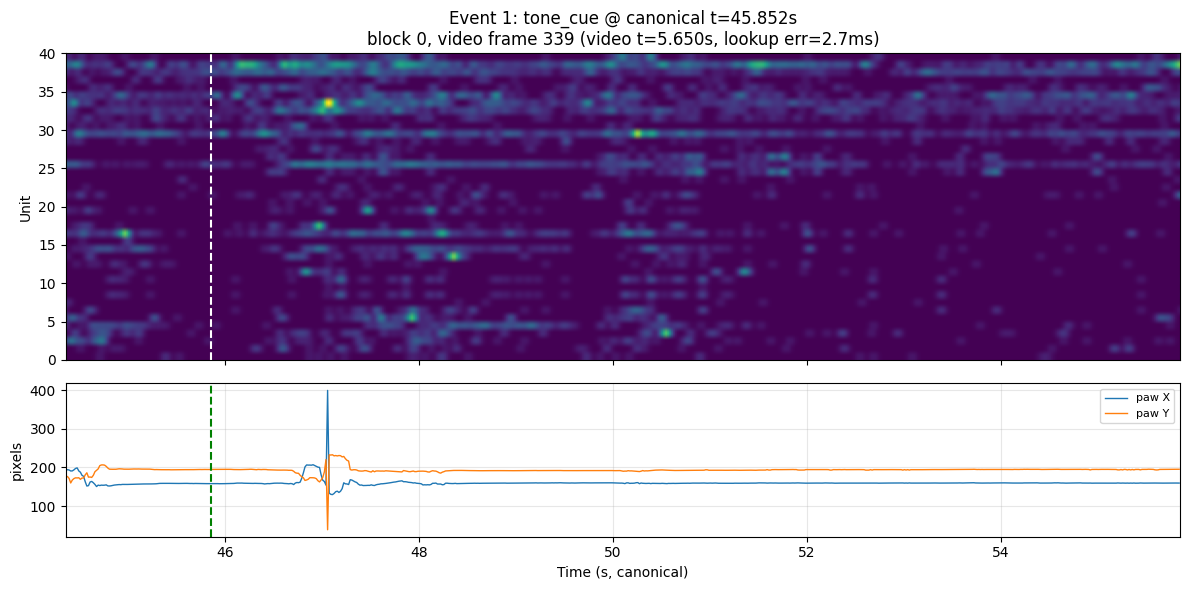

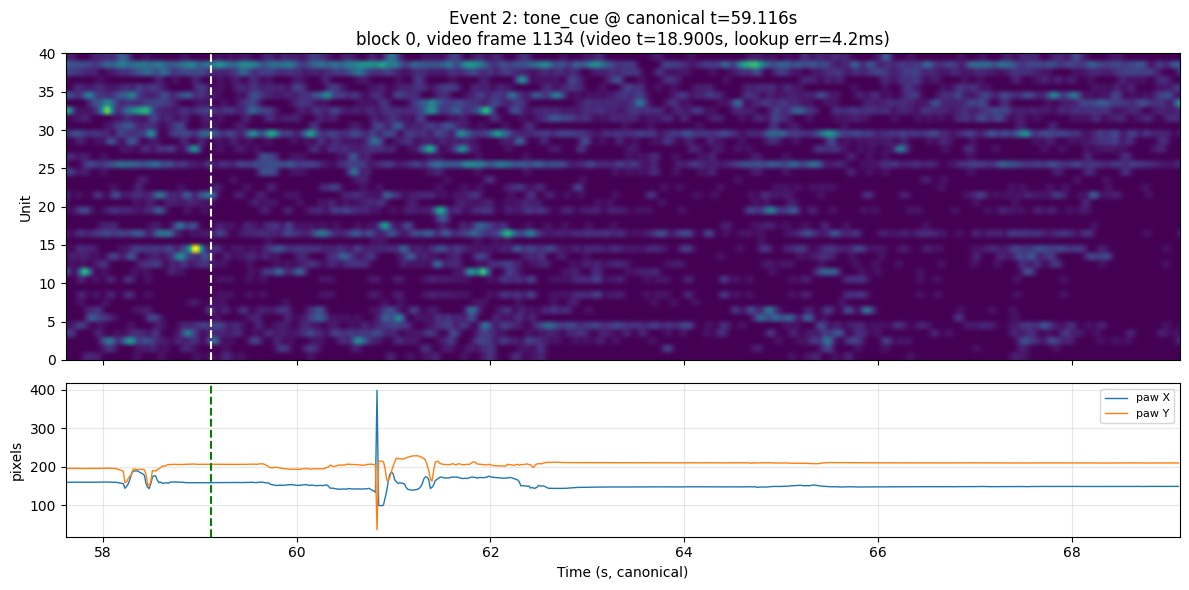

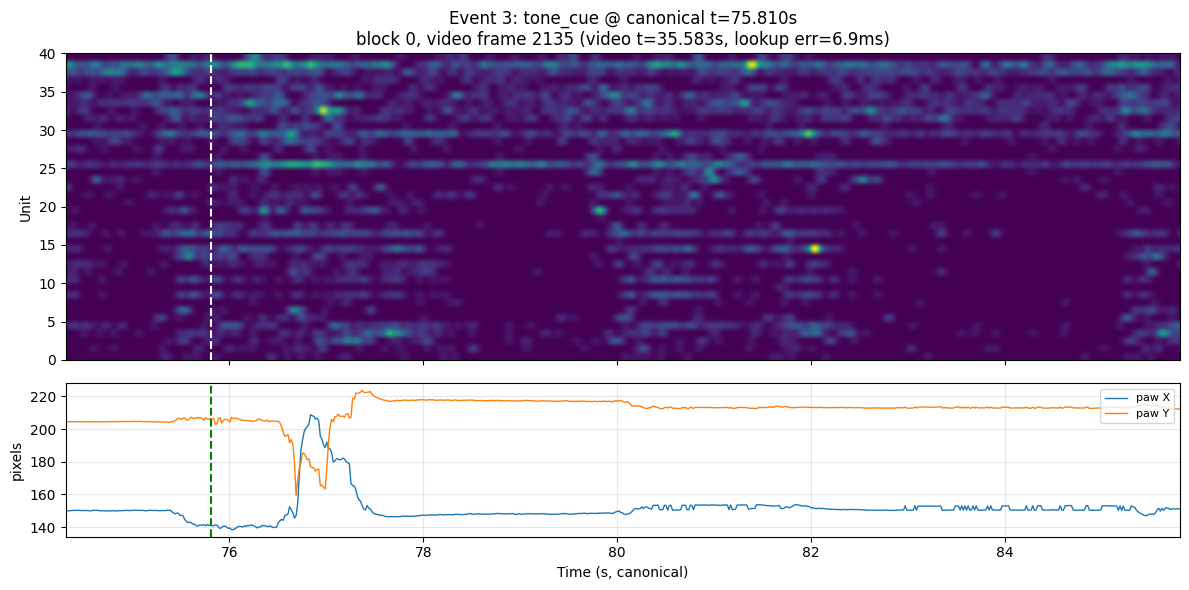

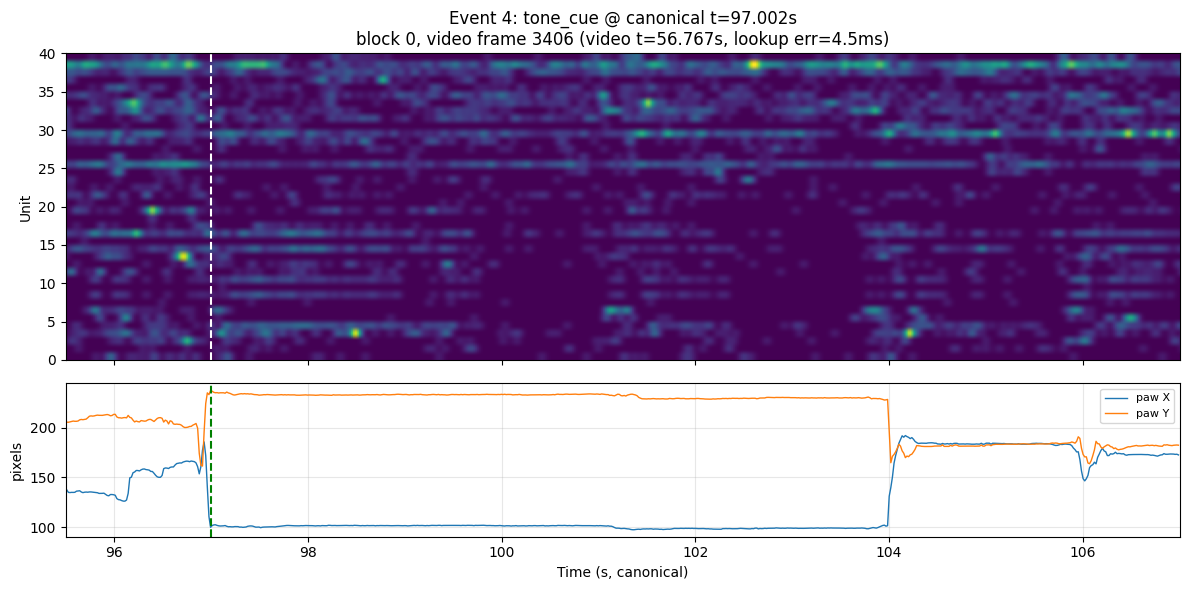

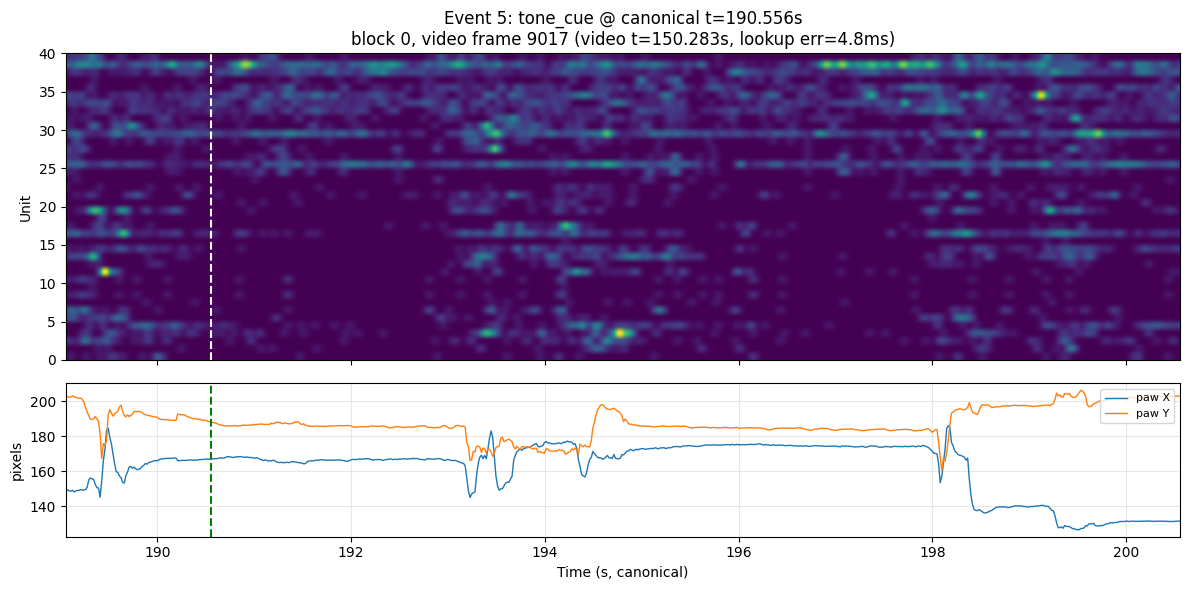

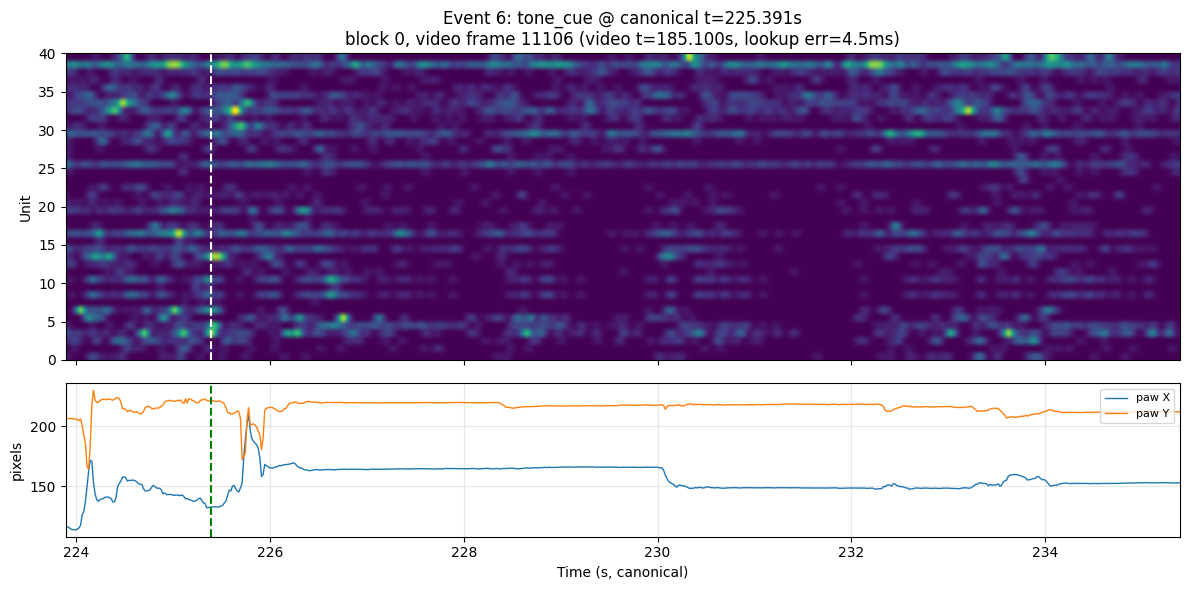

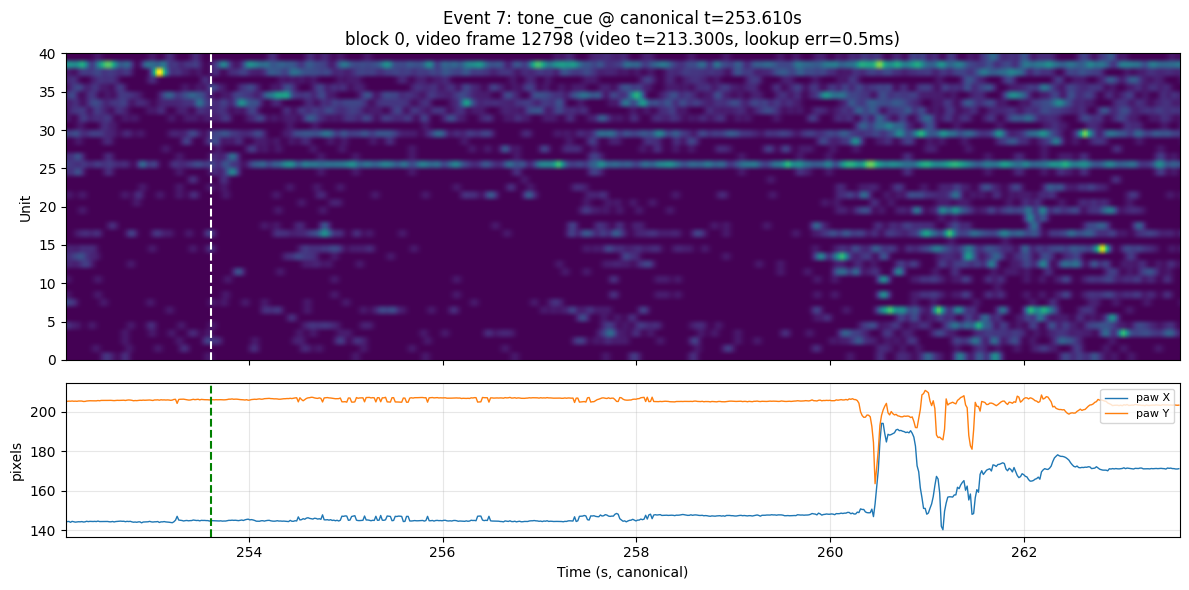

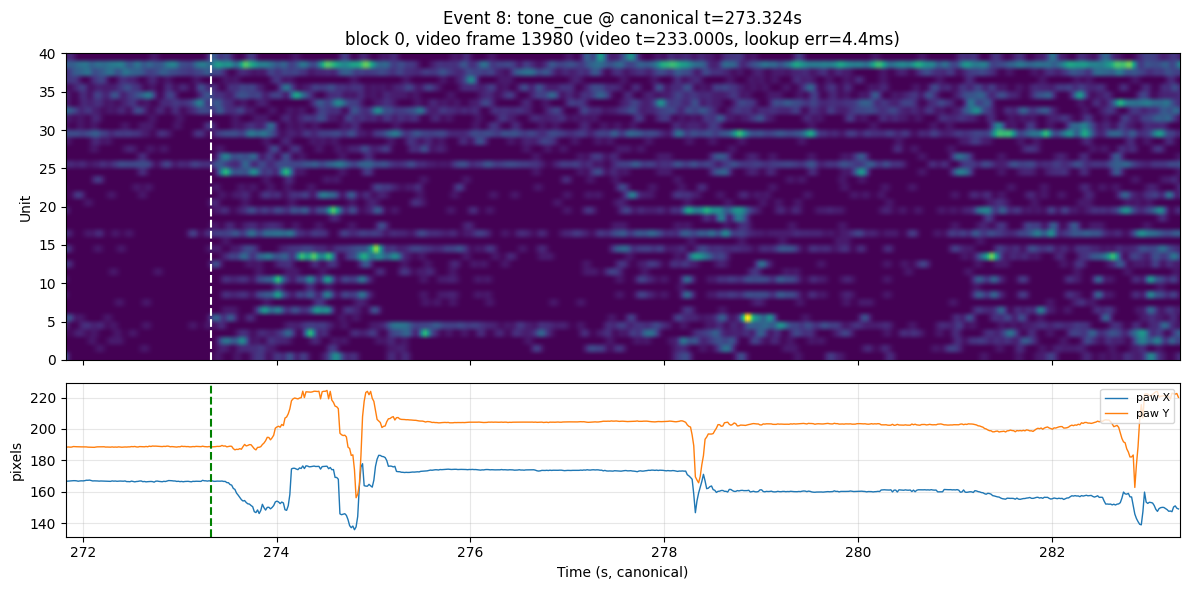


===== CELL G COMPLETE =====



In [7]:
# ============================================================
# CELL G — PERI-EVENT DIAGNOSTIC (PORTABLE)
# ============================================================
# For each event time on a chosen behavioral pin:
#   - shows firing-rate heatmap windowed around the event
#   - overlays DLC trace(s) for selected bodyparts
#   - marks the event with a vertical line
#   - PRINTS canonical time, video frame, and video time
#     so events can be cross-referenced in Fiji/VLC
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL G — PERI-EVENT DIAGNOSTIC =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN       = 4              # 6 = reach, 4 = tone, 3 = motor, etc.
PLOT_BODYPARTS  = ["paw"]
WIN_PRE         = 1.5            # seconds before event
WIN_POST        = 10.0           # seconds after event
MAX_EVENTS_PLOT = 8
ONE_PER_TRIAL   = False          # collapse multi-events per trial to first
TRIAL_PIN       = 4              # trial reference for "one per trial"
VIDEO_FPS       = 60.0           # for video time-from-frame conversion
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]

# ------------------------------------------------------------
# HELPER: canonical time → video frame number (per block)
# ------------------------------------------------------------
# Each block has its own frame_canonical_times array — element i
# is the canonical time of saved frame i (= MP4 frame i, = DLC row i).
# To go canonical→video, find the saved frame whose canonical time
# is closest to the event. This automatically handles per-session
# offsets (NI-to-camera delay) without needing a stored constant.
# ------------------------------------------------------------

# Pre-load per-block frame canonical times for lookups
block_frame_times = {}
for blk in session["blocks"]:
    b = blk["block_index"]
    block_frame_times[b] = np.load(blk["frame_canonical_times_path"])

def canonical_to_video(t_canonical):
    """Return (block_index, video_frame_number, video_time_s, lookup_error_s).

    video_frame_number = MP4 row that DLC sees as row N
    video_time_s       = seconds from start of MP4 (= frame / fps)
    lookup_error_s     = |canonical time of returned frame - requested t|.
                         Small (< ~17 ms) if the event falls during a saved
                         frame. Larger if the event is in a dropped-frame
                         window — in that case the returned frame is the
                         nearest neighbor, and Fiji will show a frame off
                         by lookup_error_s from the real event.
    Returns (None, None, None, None) if the event is outside all blocks.
    """
    for b, frame_t in block_frame_times.items():
        if frame_t[0] <= t_canonical <= frame_t[-1]:
            # bisect for nearest frame
            idx = np.searchsorted(frame_t, t_canonical)
            # check neighbor on the left in case it's closer
            candidates = []
            if idx < len(frame_t):
                candidates.append(idx)
            if idx > 0:
                candidates.append(idx - 1)
            best = min(candidates, key=lambda i: abs(frame_t[i] - t_canonical))
            err = abs(frame_t[best] - t_canonical)
            video_time = best / VIDEO_FPS
            return b, int(best), float(video_time), float(err)
    return None, None, None, None

# ------------------------------------------------------------
# LOAD EVENT TIMES
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
event_times = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")
print(f"Event pin {EVENT_PIN} ({event_label}): {len(event_times)} TTLs")

if ONE_PER_TRIAL:
    trial_times = np.load(ttls_dir / f"TTL_Pin_{TRIAL_PIN}.npy")
    kept = []
    for ts in trial_times:
        idx = np.searchsorted(event_times, ts)
        if idx < len(event_times) and event_times[idx] - ts < 25:
            kept.append(event_times[idx])
    event_times = np.array(kept)
    print(f"After 'first per trial' filter: {len(event_times)} events")

event_times = event_times[:MAX_EVENTS_PLOT]

# ------------------------------------------------------------
# PRINT REFERENCE TABLE (BEFORE PLOTTING)
# ------------------------------------------------------------
print(f"\n===== EVENT REFERENCE TABLE =====")
print(f"{'#':>3} | {'canonical (s)':>14} | {'block':>5} | "
      f"{'video frame':>11} | {'video time (s)':>14} | {'lookup err (ms)':>15}")
print("-" * 80)
for i, t_evt in enumerate(event_times):
    b, vframe, vtime, err = canonical_to_video(t_evt)
    if b is None:
        print(f"{i+1:>3} | {t_evt:>14.3f} | {'OOB':>5} | "
              f"{'—':>11} | {'—':>14} | {'—':>15}")
    else:
        flag = " ⚠ in drop?" if err is not None and err > 0.030 else ""
        print(f"{i+1:>3} | {t_evt:>14.3f} | {b:>5} | "
              f"{vframe:>11} | {vtime:>14.3f} | {err*1000:>15.1f}{flag}")
print()

# ------------------------------------------------------------
# LOAD PHYSIOLOGY + DLC
# ------------------------------------------------------------
centers     = np.load(analysis_folder / "qc" / "centers.npy")
rate_matrix = np.load(analysis_folder / "qc" / "rate_matrix.npy")
good_units  = np.load(analysis_folder / "qc" / "good_units.npy")

dlc = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
dlc_t = dlc["canonical_time"]

# ------------------------------------------------------------
# PLOT EACH EVENT
# ------------------------------------------------------------
for i, t_evt in enumerate(event_times):
    t0, t1 = t_evt - WIN_PRE, t_evt + WIN_POST
    mask_fr  = (centers >= t0) & (centers <= t1)
    mask_dlc = (dlc_t   >= t0) & (dlc_t   <= t1)

    b, vframe, vtime, err = canonical_to_video(t_evt)
    if b is not None:
        video_str = (f"block {b}, video frame {vframe} "
                     f"(video t={vtime:.3f}s, lookup err={err*1000:.1f}ms)")
    else:
        video_str = "outside any block"

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})

    # Firing rate
    ax = axes[0]
    ax.imshow(rate_matrix[:, mask_fr], aspect="auto",
              extent=[t0, t1, 0, len(good_units)], origin="lower")
    ax.axvline(t_evt, color="white", linestyle="--", lw=1.5)
    ax.set_ylabel("Unit")
    ax.set_title(f"Event {i+1}: {event_label} @ canonical t={t_evt:.3f}s\n"
                 f"{video_str}")

    # DLC
    ax = axes[1]
    for bp in PLOT_BODYPARTS:
        if f"{bp}_x" not in dlc.files:
            continue
        ax.plot(dlc_t[mask_dlc], dlc[f"{bp}_x"][mask_dlc], lw=1.0, label=f"{bp} X")
        ax.plot(dlc_t[mask_dlc], dlc[f"{bp}_y"][mask_dlc], lw=1.0, label=f"{bp} Y")
    ax.axvline(t_evt, color="green", linestyle="--", lw=1.5)
    ax.set_xlabel("Time (s, canonical)")
    ax.set_ylabel("pixels")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n===== CELL G COMPLETE =====\n")


===== CELL H — UNIT MODULATION + LATENCY SORT =====
Aligning to: tone_cue (pin 4), 55 events
Computing PSTHs for 40 units × 55 events × 300 bins...

Modulated units (|z|>2.5 for ≥60 ms in 0.0–2.0s post-event): 36 / 40


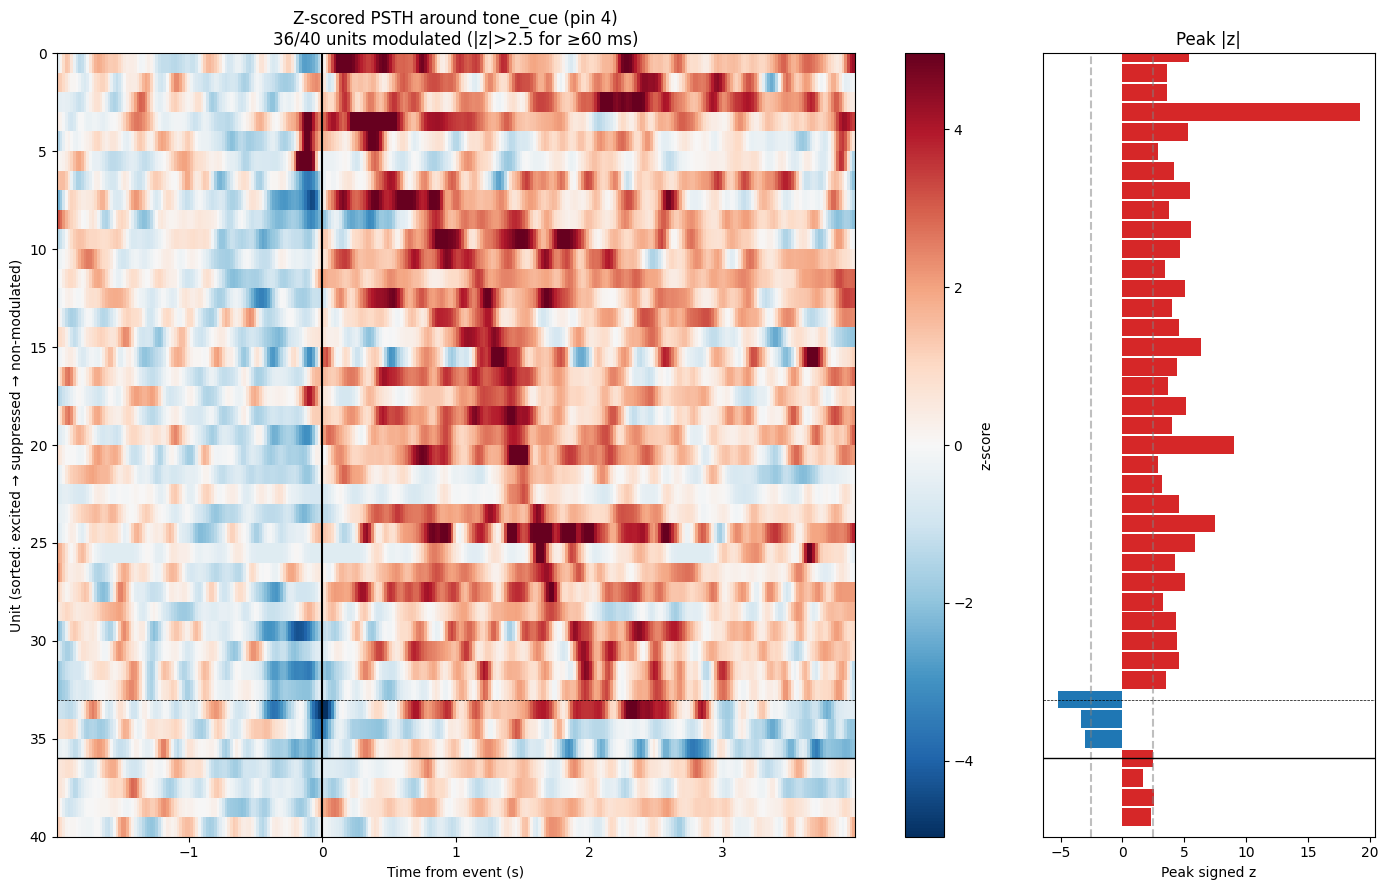


Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\modulation_pin4_tone_cue.png
Saved arrays → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\modulation_pin4_tone_cue_arrays.npz

===== CELL H COMPLETE =====



In [8]:
# ============================================================
# CELL H — UNIT MODULATION DETECTION + LATENCY SORT (PORTABLE)
# ============================================================
# For each good unit, build a peri-event PSTH around the chosen
# TTL pin. Z-score against a pre-event baseline, flag units that
# cross a threshold, sort by peak latency, plot as heatmap.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL H — UNIT MODULATION + LATENCY SORT =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN          = 4          # 4 = tone, 3 = motor (use [0::2] for expose),
                                # 6 = reach, 7 = button
EVENT_LABEL_FOR_3  = None       # if EVENT_PIN==3, set to "expose" or "retract"
                                # (uses [0::2] or [1::2])
WIN_PRE            = 2.0        # seconds before event (for plotting and baseline)
WIN_POST           = 4.0        # seconds after event
BASELINE_WIN       = (-2.0, -0.5)  # baseline window (relative to event) for z-scoring
RESPONSE_WIN       = ( 0.0, 2.0)   # window in which to look for modulation
BIN_SIZE           = 0.020      # seconds (20 ms)
SMOOTH_SIGMA_BINS  = 2          # Gaussian smoothing, in bins (40 ms σ for 20 ms bins)
Z_THRESHOLD        = 2.5        # |z| crossing threshold for "modulated"
MIN_CONSECUTIVE_MS = 60         # must be |z|>threshold for at least this long
ONE_PER_TRIAL      = False
TRIAL_PIN          = 4
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")

# ------------------------------------------------------------
# LOAD EVENT TIMES
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
event_times = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
if EVENT_PIN == 3 and EVENT_LABEL_FOR_3 is not None:
    if EVENT_LABEL_FOR_3 == "expose":
        event_times = event_times[0::2]
        event_label = "pellet_expose"
    elif EVENT_LABEL_FOR_3 == "retract":
        event_times = event_times[1::2]
        event_label = "pellet_retract"
    else:
        raise ValueError("EVENT_LABEL_FOR_3 must be 'expose' or 'retract'")

if ONE_PER_TRIAL:
    trial_times = np.load(ttls_dir / f"TTL_Pin_{TRIAL_PIN}.npy")
    kept = []
    for ts in trial_times:
        idx = np.searchsorted(event_times, ts)
        if idx < len(event_times) and event_times[idx] - ts < 25:
            kept.append(event_times[idx])
    event_times = np.array(kept)

print(f"Aligning to: {event_label} (pin {EVENT_PIN}), {len(event_times)} events")

# ------------------------------------------------------------
# BIN EDGES (in PERI-EVENT TIME, not canonical)
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)

baseline_mask = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])

# ------------------------------------------------------------
# COMPUTE PSTH PER UNIT
# ------------------------------------------------------------
good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"

psth        = np.zeros((len(good_units), n_bins), dtype=np.float64)  # mean rate
psth_per_trial = np.zeros((len(good_units), len(event_times), n_bins))

print(f"Computing PSTHs for {len(good_units)} units × {len(event_times)} events × {n_bins} bins...")

for u_i, unit in enumerate(good_units):
    spk = np.load(spikes_dir / f"unit_{unit}.npy")
    for e_i, t_evt in enumerate(event_times):
        # spikes in the peri-event window, expressed as time-from-event
        rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
        h, _ = np.histogram(rel, bins=edges)
        psth_per_trial[u_i, e_i] = h / BIN_SIZE  # convert to Hz

# trial-averaged PSTH per unit
psth = psth_per_trial.mean(axis=1)

# smooth
psth_smooth = gaussian_filter1d(psth, sigma=SMOOTH_SIGMA_BINS, axis=1)

# ------------------------------------------------------------
# Z-SCORE EACH UNIT AGAINST ITS OWN BASELINE
# ------------------------------------------------------------
baseline_mean = psth_smooth[:, baseline_mask].mean(axis=1, keepdims=True)
baseline_std  = psth_smooth[:, baseline_mask].std (axis=1, keepdims=True)
baseline_std[baseline_std < 0.5] = 0.5   # floor to avoid div-by-near-zero
                                          # for very quiet baselines (0.5 Hz)

z = (psth_smooth - baseline_mean) / baseline_std   # (n_units, n_bins)

# ------------------------------------------------------------
# MODULATION DETECTION
# ------------------------------------------------------------
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))
z_response = z[:, response_mask]

def has_consecutive_crossing(z_row, thresh, min_consec):
    """True if z_row has min_consec consecutive bins with |z|>thresh of same sign."""
    pos = z_row > thresh
    neg = z_row < -thresh
    # run-length detection
    for arr in (pos, neg):
        # find runs of True
        if not arr.any():
            continue
        # quick run-length: pad with False, find rising/falling edges
        padded = np.concatenate([[False], arr, [False]])
        diffs = np.diff(padded.astype(int))
        starts = np.where(diffs == 1)[0]
        ends   = np.where(diffs == -1)[0]
        if (ends - starts).max() >= min_consec:
            return True
    return False

modulated = np.array([
    has_consecutive_crossing(z_response[i], Z_THRESHOLD, min_consec_bins)
    for i in range(len(good_units))
])

n_modulated = int(modulated.sum())
print(f"\nModulated units (|z|>{Z_THRESHOLD} for ≥{MIN_CONSECUTIVE_MS} ms in "
      f"{RESPONSE_WIN[0]}–{RESPONSE_WIN[1]}s post-event): "
      f"{n_modulated} / {len(good_units)}")

# ------------------------------------------------------------
# LATENCY = time of peak signed z within response window
# ------------------------------------------------------------
response_centers = centers[response_mask]
# argmax of absolute z, but keep the sign
peak_idx  = np.argmax(np.abs(z_response), axis=1)
peak_lat  = response_centers[peak_idx]                        # signed latency
peak_z    = z_response[np.arange(len(good_units)), peak_idx]  # signed magnitude

# Among modulated units, sort by latency (excited first, then suppressed,
# each sorted by peak time)
mod_idx       = np.where(modulated)[0]
mod_peak_lat  = peak_lat[mod_idx]
mod_peak_z    = peak_z[mod_idx]

# Sort: excited (peak_z>0) by ascending latency, then suppressed (peak_z<0) by ascending latency
excited_mask  = mod_peak_z > 0
sup_mask      = ~excited_mask

excited_order = mod_idx[excited_mask][np.argsort(mod_peak_lat[excited_mask])]
suppressed_order = mod_idx[sup_mask][np.argsort(mod_peak_lat[sup_mask])]
sorted_mod_idx = np.concatenate([excited_order, suppressed_order])

# Non-modulated units at the bottom, unsorted
non_mod_idx = np.where(~modulated)[0]
full_sort_idx = np.concatenate([sorted_mod_idx, non_mod_idx])

# ------------------------------------------------------------
# PLOT: SORTED Z-SCORE HEATMAP
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 9),
                          gridspec_kw={"width_ratios": [3, 1]})

ax = axes[0]
vmax = max(3.0, np.percentile(np.abs(z), 99))
im = ax.imshow(z[full_sort_idx], aspect="auto",
               extent=[centers[0], centers[-1], len(good_units), 0],
               cmap="RdBu_r", vmin=-vmax, vmax=vmax,
               interpolation="nearest")
ax.axvline(0, color="black", lw=1.5)
ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel("Unit (sorted: excited → suppressed → non-modulated)")
ax.set_title(f"Z-scored PSTH around {event_label} (pin {EVENT_PIN})\n"
             f"{n_modulated}/{len(good_units)} units modulated "
             f"(|z|>{Z_THRESHOLD} for ≥{MIN_CONSECUTIVE_MS} ms)")
plt.colorbar(im, ax=ax, label="z-score")

# Side panel: signed peak z for each unit (in same sort order)
ax = axes[1]
y = np.arange(len(good_units))
peak_z_sorted = peak_z[full_sort_idx]
colors = np.where(peak_z_sorted > 0, "C3", "C0")
ax.barh(y, peak_z_sorted, color=colors, height=0.9)
ax.axvline(Z_THRESHOLD, color="gray", linestyle="--", alpha=0.5)
ax.axvline(-Z_THRESHOLD, color="gray", linestyle="--", alpha=0.5)
ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(good_units), 0)
ax.set_xlabel("Peak signed z")
ax.set_yticks([])
ax.set_title("Peak |z|")

plt.tight_layout()

# Save
out_dir = analysis_folder / "qc"
out_path = out_dir / f"modulation_pin{EVENT_PIN}_{event_label}.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"modulation_pin{EVENT_PIN}_{event_label}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SAVE RESULTS TO DISK
# ------------------------------------------------------------
results = {
    "event_pin": int(EVENT_PIN),
    "event_label": event_label,
    "n_events": int(len(event_times)),
    "bin_size_s": float(BIN_SIZE),
    "win_pre_s":  float(WIN_PRE),
    "win_post_s": float(WIN_POST),
    "baseline_win_s": list(BASELINE_WIN),
    "response_win_s": list(RESPONSE_WIN),
    "z_threshold": float(Z_THRESHOLD),
    "min_consecutive_ms": float(MIN_CONSECUTIVE_MS),
    "n_units": int(len(good_units)),
    "n_modulated": int(n_modulated),
}
results_path = out_dir / f"modulation_pin{EVENT_PIN}_{event_label}_summary.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

# Save per-unit arrays
np.savez(out_dir / f"modulation_pin{EVENT_PIN}_{event_label}_arrays.npz",
         good_units=good_units,
         psth_smooth=psth_smooth,
         z=z,
         modulated=modulated,
         peak_latency=peak_lat,
         peak_z=peak_z,
         sort_order=full_sort_idx,
         centers=centers)
print(f"Saved arrays → {out_dir / f'modulation_pin{EVENT_PIN}_{event_label}_arrays.npz'}")

print("\n===== CELL H COMPLETE =====\n")


===== CELL I — SHUFFLED CONTROLS =====
Real events (tone_cue, pin 4): 55
Loaded spike times for 40 units

Computing real-data PSTHs...
Real data: 36 / 40 modulated (90.0%)

--- Test 1: shuffling event times (100 iterations) ---
  10/100 done. Running mean modulated (shuffled): 21.6
  20/100 done. Running mean modulated (shuffled): 21.6
  30/100 done. Running mean modulated (shuffled): 20.1
  40/100 done. Running mean modulated (shuffled): 19.8
  50/100 done. Running mean modulated (shuffled): 20.1
  60/100 done. Running mean modulated (shuffled): 20.4
  70/100 done. Running mean modulated (shuffled): 20.6
  80/100 done. Running mean modulated (shuffled): 20.5
  90/100 done. Running mean modulated (shuffled): 20.5
  100/100 done. Running mean modulated (shuffled): 20.4

Test 1 results:
  Real:           36 modulated units
  Shuffled mean:  20.4 ± 4.6
  Shuffled 95th:  29
  Real / shuffled-mean ratio: 1.8×
  p-value (real ≥ shuffled):  0.0000

--- Test 2: shuffling PSTH bins within each

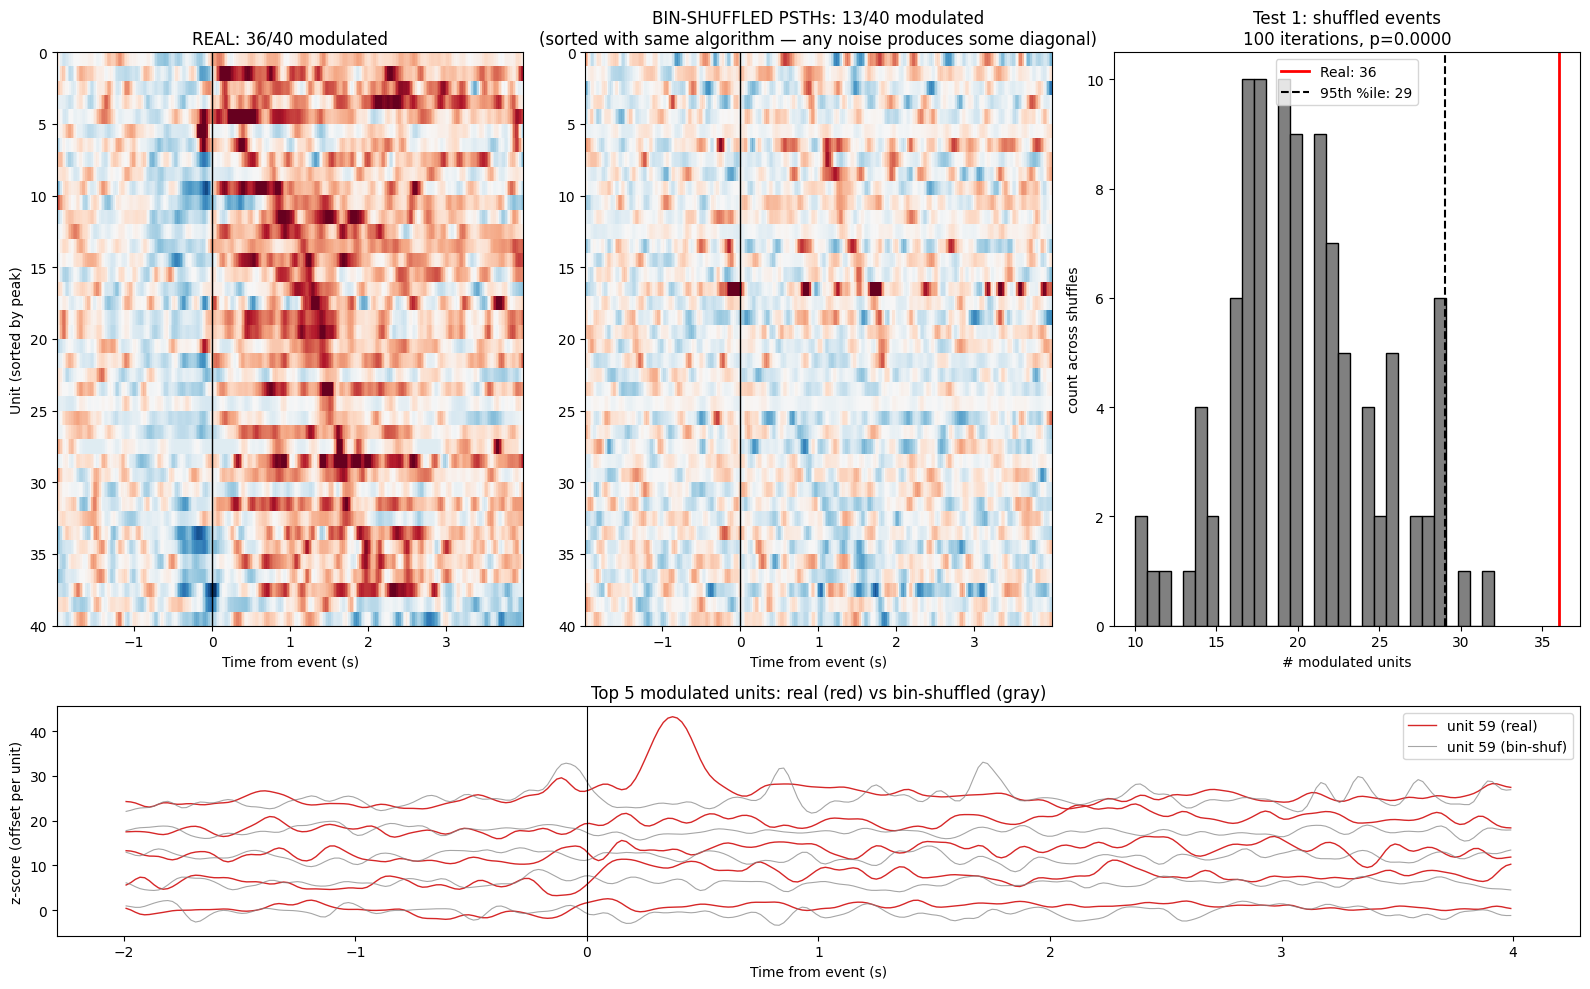


Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\falsification_pin4_tone_cue.png

===== INTERPRETATION =====

Test 1 (shuffled event times):
  ~ MARGINAL. Real exceeds shuffled (p=0.0000) but ratio (1.8×) is modest. Some signal, but weaker than the plot suggests.

Test 2 (bin-shuffled PSTHs):
  ✗ FAILED. Bin-shuffled PSTHs (13) modulate almost as much as real (36). The diagonal is largely a sorting artifact (any data sorted by argmax forms a diagonal). STOP and reconsider.

===== CELL I COMPLETE =====



In [9]:
# ============================================================
# CELL I — FALSIFICATION TESTS: SHUFFLED CONTROLS
# ============================================================
# Two independent null distributions to test whether the
# modulation pattern in Cell H is real signal or analysis artifact.
#
# Test 1: SHUFFLED EVENT TIMES
#   Replace the 48 real event times with 48 random times drawn
#   from the recording, run the full Cell H analysis, count
#   modulated units. Repeat N_SHUFFLES times.
#   → Tests: is the population response time-locked to the actual
#     events, or would *any* set of events produce this pattern?
#
# Test 2: PER-BIN SHUFFLED PSTHs
#   Take the real PSTHs and shuffle each unit's bins independently.
#   Re-detect modulation and re-sort. The resulting heatmap will
#   look superficially similar (any sorted-by-argmax data forms a
#   diagonal) but the # of "modulated" units and the strength of
#   the diagonal should be much lower.
#   → Tests: is the sort doing the work, or is there real structure?
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL I — SHUFFLED CONTROLS =====")

# ------------------------------------------------------------
# USER EDIT — must match Cell H parameters exactly
# ------------------------------------------------------------
EVENT_PIN          = 4
WIN_PRE            = 2.0
WIN_POST           = 4.0
BASELINE_WIN       = (-2.0, -0.5)
RESPONSE_WIN       = ( 0.0,  2.0)
BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
Z_THRESHOLD        = 2.5
MIN_CONSECUTIVE_MS = 60
N_SHUFFLES         = 100      # 100 is enough for a strong test; 1000 for publication
RANDOM_SEED        = 42
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD EVENT TIMES + UNITS
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
real_events = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
print(f"Real events ({event_label}, pin {EVENT_PIN}): {len(real_events)}")

good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"

# Pre-load all spike trains
all_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}
print(f"Loaded spike times for {len(good_units)} units")

# ------------------------------------------------------------
# SHARED HELPERS
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)

baseline_mask = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

def compute_psth_zscore(events):
    """Returns (psth_smooth, z) given a set of event times."""
    psth_per_trial = np.zeros((len(good_units), len(events), n_bins))
    for u_i, u in enumerate(good_units):
        spk = all_spikes[int(u)]
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            psth_per_trial[u_i, e_i] = h / BIN_SIZE
    psth = psth_per_trial.mean(axis=1)
    psth_smooth = gaussian_filter1d(psth, sigma=SMOOTH_SIGMA_BINS, axis=1)
    base_mean = psth_smooth[:, baseline_mask].mean(axis=1, keepdims=True)
    base_std  = psth_smooth[:, baseline_mask].std (axis=1, keepdims=True)
    base_std[base_std < 0.5] = 0.5
    z = (psth_smooth - base_mean) / base_std
    return psth_smooth, z

def count_modulated(z):
    """Returns number of units with |z|>thresh for ≥min_consec_bins in response window."""
    z_resp = z[:, response_mask]
    count = 0
    for i in range(z_resp.shape[0]):
        for arr in (z_resp[i] > Z_THRESHOLD, z_resp[i] < -Z_THRESHOLD):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            diffs = np.diff(padded.astype(int))
            starts = np.where(diffs ==  1)[0]
            ends   = np.where(diffs == -1)[0]
            if (ends - starts).max() >= min_consec_bins:
                count += 1
                break
    return count

# ------------------------------------------------------------
# REAL DATA — recompute for comparison
# ------------------------------------------------------------
print("\nComputing real-data PSTHs...")
real_psth, real_z = compute_psth_zscore(real_events)
real_n_modulated = count_modulated(real_z)
print(f"Real data: {real_n_modulated} / {len(good_units)} modulated "
      f"({100*real_n_modulated/len(good_units):.1f}%)")

# ============================================================
# TEST 1: SHUFFLED EVENT TIMES
# ============================================================
print(f"\n--- Test 1: shuffling event times ({N_SHUFFLES} iterations) ---")

rng = np.random.default_rng(RANDOM_SEED)

# Constrain shuffled events to leave room for WIN_PRE / WIN_POST
t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0

shuffled_n_modulated = np.zeros(N_SHUFFLES, dtype=int)
for s in range(N_SHUFFLES):
    fake_events = rng.uniform(t_min, t_max, size=len(real_events))
    fake_events.sort()
    _, fake_z = compute_psth_zscore(fake_events)
    shuffled_n_modulated[s] = count_modulated(fake_z)
    if (s + 1) % 10 == 0:
        print(f"  {s+1}/{N_SHUFFLES} done. "
              f"Running mean modulated (shuffled): "
              f"{shuffled_n_modulated[:s+1].mean():.1f}")

shuffled_mean = shuffled_n_modulated.mean()
shuffled_std  = shuffled_n_modulated.std()
shuffled_95   = np.percentile(shuffled_n_modulated, 95)
p_value       = (shuffled_n_modulated >= real_n_modulated).sum() / N_SHUFFLES

print(f"\nTest 1 results:")
print(f"  Real:           {real_n_modulated} modulated units")
print(f"  Shuffled mean:  {shuffled_mean:.1f} ± {shuffled_std:.1f}")
print(f"  Shuffled 95th:  {shuffled_95:.0f}")
print(f"  Real / shuffled-mean ratio: {real_n_modulated / max(shuffled_mean, 1):.1f}×")
print(f"  p-value (real ≥ shuffled):  {p_value:.4f}")

# ============================================================
# TEST 2: PER-BIN SHUFFLED PSTHs (sort-order falsification)
# ============================================================
print(f"\n--- Test 2: shuffling PSTH bins within each unit ---")

# Take the real PSTH, shuffle each row's bins independently
shuffled_psth = real_psth.copy()
for i in range(shuffled_psth.shape[0]):
    rng.shuffle(shuffled_psth[i])

# Re-smooth (since smoothing assumed temporal structure)
shuffled_psth_smooth = gaussian_filter1d(shuffled_psth, sigma=SMOOTH_SIGMA_BINS, axis=1)
base_m = shuffled_psth_smooth[:, baseline_mask].mean(axis=1, keepdims=True)
base_s = shuffled_psth_smooth[:, baseline_mask].std (axis=1, keepdims=True)
base_s[base_s < 0.5] = 0.5
shuffled_z = (shuffled_psth_smooth - base_m) / base_s

# Modulation count
binshuf_n_modulated = count_modulated(shuffled_z)
print(f"  Bin-shuffled modulated: {binshuf_n_modulated}")

# Sort by peak latency in response window (same algorithm as Cell H)
def sort_by_peak(z_mat):
    z_resp = z_mat[:, response_mask]
    response_centers = centers[response_mask]
    peak_idx = np.argmax(np.abs(z_resp), axis=1)
    peak_lat = response_centers[peak_idx]
    peak_z   = z_resp[np.arange(z_resp.shape[0]), peak_idx]
    excited  = peak_z > 0
    order    = np.concatenate([
        np.where(excited)[0][np.argsort(peak_lat[excited])],
        np.where(~excited)[0][np.argsort(peak_lat[~excited])],
    ])
    return order

real_order   = sort_by_peak(real_z)
shuf_order   = sort_by_peak(shuffled_z)

# ============================================================
# FIGURE: SIDE-BY-SIDE HEATMAPS + HISTOGRAM
# ============================================================
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[2.5, 1])

vmax = max(3.0, np.percentile(np.abs(real_z), 99))

ax = fig.add_subplot(gs[0, 0])
ax.imshow(real_z[real_order], aspect="auto",
          extent=[centers[0], centers[-1], len(good_units), 0],
          cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel("Unit (sorted by peak)")
ax.set_title(f"REAL: {real_n_modulated}/{len(good_units)} modulated")

ax = fig.add_subplot(gs[0, 1])
ax.imshow(shuffled_z[shuf_order], aspect="auto",
          extent=[centers[0], centers[-1], len(good_units), 0],
          cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_title(f"BIN-SHUFFLED PSTHs: {binshuf_n_modulated}/{len(good_units)} modulated\n"
             "(sorted with same algorithm — any noise produces some diagonal)")

# Histogram of shuffled-events modulated counts
ax = fig.add_subplot(gs[0, 2])
ax.hist(shuffled_n_modulated, bins=30, color="gray", edgecolor="black")
ax.axvline(real_n_modulated, color="red", lw=2,
           label=f"Real: {real_n_modulated}")
ax.axvline(shuffled_95, color="black", linestyle="--",
           label=f"95th %ile: {shuffled_95:.0f}")
ax.set_xlabel("# modulated units")
ax.set_ylabel("count across shuffles")
ax.set_title(f"Test 1: shuffled events\n{N_SHUFFLES} iterations, p={p_value:.4f}")
ax.legend()

# Bottom row: example PSTHs to compare
ax = fig.add_subplot(gs[1, :])
# Show real vs shuffled for a few top-modulated units
top_units_idx = real_order[:5]
for k, u_i in enumerate(top_units_idx):
    ax.plot(centers, real_z[u_i] + k * 6, color="C3", lw=1.0,
            label=f"unit {good_units[u_i]} (real)" if k == 0 else None)
    ax.plot(centers, shuffled_z[u_i] + k * 6, color="gray", lw=0.8, alpha=0.7,
            label=f"unit {good_units[u_i]} (bin-shuf)" if k == 0 else None)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel("z-score (offset per unit)")
ax.set_title("Top 5 modulated units: real (red) vs bin-shuffled (gray)")
ax.legend(loc="upper right")

plt.tight_layout()

out_dir = analysis_folder / "qc"
out_path = out_dir / f"falsification_pin{EVENT_PIN}_{event_label}.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"falsification_pin{EVENT_PIN}_{event_label}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ============================================================
# INTERPRETATION
# ============================================================
print("\n===== INTERPRETATION =====")

print(f"\nTest 1 (shuffled event times):")
if p_value < 0.01 and real_n_modulated > shuffled_mean * 3:
    print(f"  ✓ PASSED. Real modulation count ({real_n_modulated}) is "
          f"{real_n_modulated/shuffled_mean:.1f}× the shuffled mean. "
          f"The temporal structure is locked to actual events.")
elif p_value < 0.05:
    print(f"  ~ MARGINAL. Real exceeds shuffled (p={p_value:.4f}) but ratio "
          f"({real_n_modulated/max(shuffled_mean,1):.1f}×) is modest. "
          f"Some signal, but weaker than the plot suggests.")
else:
    print(f"  ✗ FAILED. Shuffled events produce similar modulation counts. "
          f"The diagonal in your Cell H plot is likely an analysis artifact, "
          f"NOT real time-locked response. STOP and investigate.")

print(f"\nTest 2 (bin-shuffled PSTHs):")
if real_n_modulated > binshuf_n_modulated * 3:
    print(f"  ✓ PASSED. Real ({real_n_modulated}) vs bin-shuffled "
          f"({binshuf_n_modulated}): real shows much more modulation than "
          f"randomly-permuted bins. Real structure is in the temporal "
          f"pattern, not just in the sorting.")
else:
    print(f"  ✗ FAILED. Bin-shuffled PSTHs ({binshuf_n_modulated}) modulate "
          f"almost as much as real ({real_n_modulated}). The diagonal is "
          f"largely a sorting artifact (any data sorted by argmax forms a "
          f"diagonal). STOP and reconsider.")

print("\n===== CELL I COMPLETE =====\n")


===== CELL J — FAST-RESPONDER ARTIFACT CHECK =====
Inspecting 10 fastest excited modulated units:
  #1: unit 30  peak latency = 150.0 ms, peak z = 5.40
  #2: unit 168  peak latency = 150.0 ms, peak z = 3.59
  #3: unit 275  peak latency = 170.0 ms, peak z = 3.63
  #4: unit 430  peak latency = 370.0 ms, peak z = 19.20
  #5: unit 416  peak latency = 390.0 ms, peak z = 5.28
  #6: unit 315  peak latency = 390.0 ms, peak z = 2.87
  #7: unit 290  peak latency = 510.0 ms, peak z = 4.15
  #8: unit 283  peak latency = 830.0 ms, peak z = 5.45
  #9: unit 259  peak latency = 850.0 ms, peak z = 3.77
  #10: unit 288  peak latency = 890.0 ms, peak z = 5.55

Fastest peak latency: 150.0 ms
  ✓ OK: ≥10 ms is consistent with biological response latencies.

Loaded templates: shape (437, 61, 384)


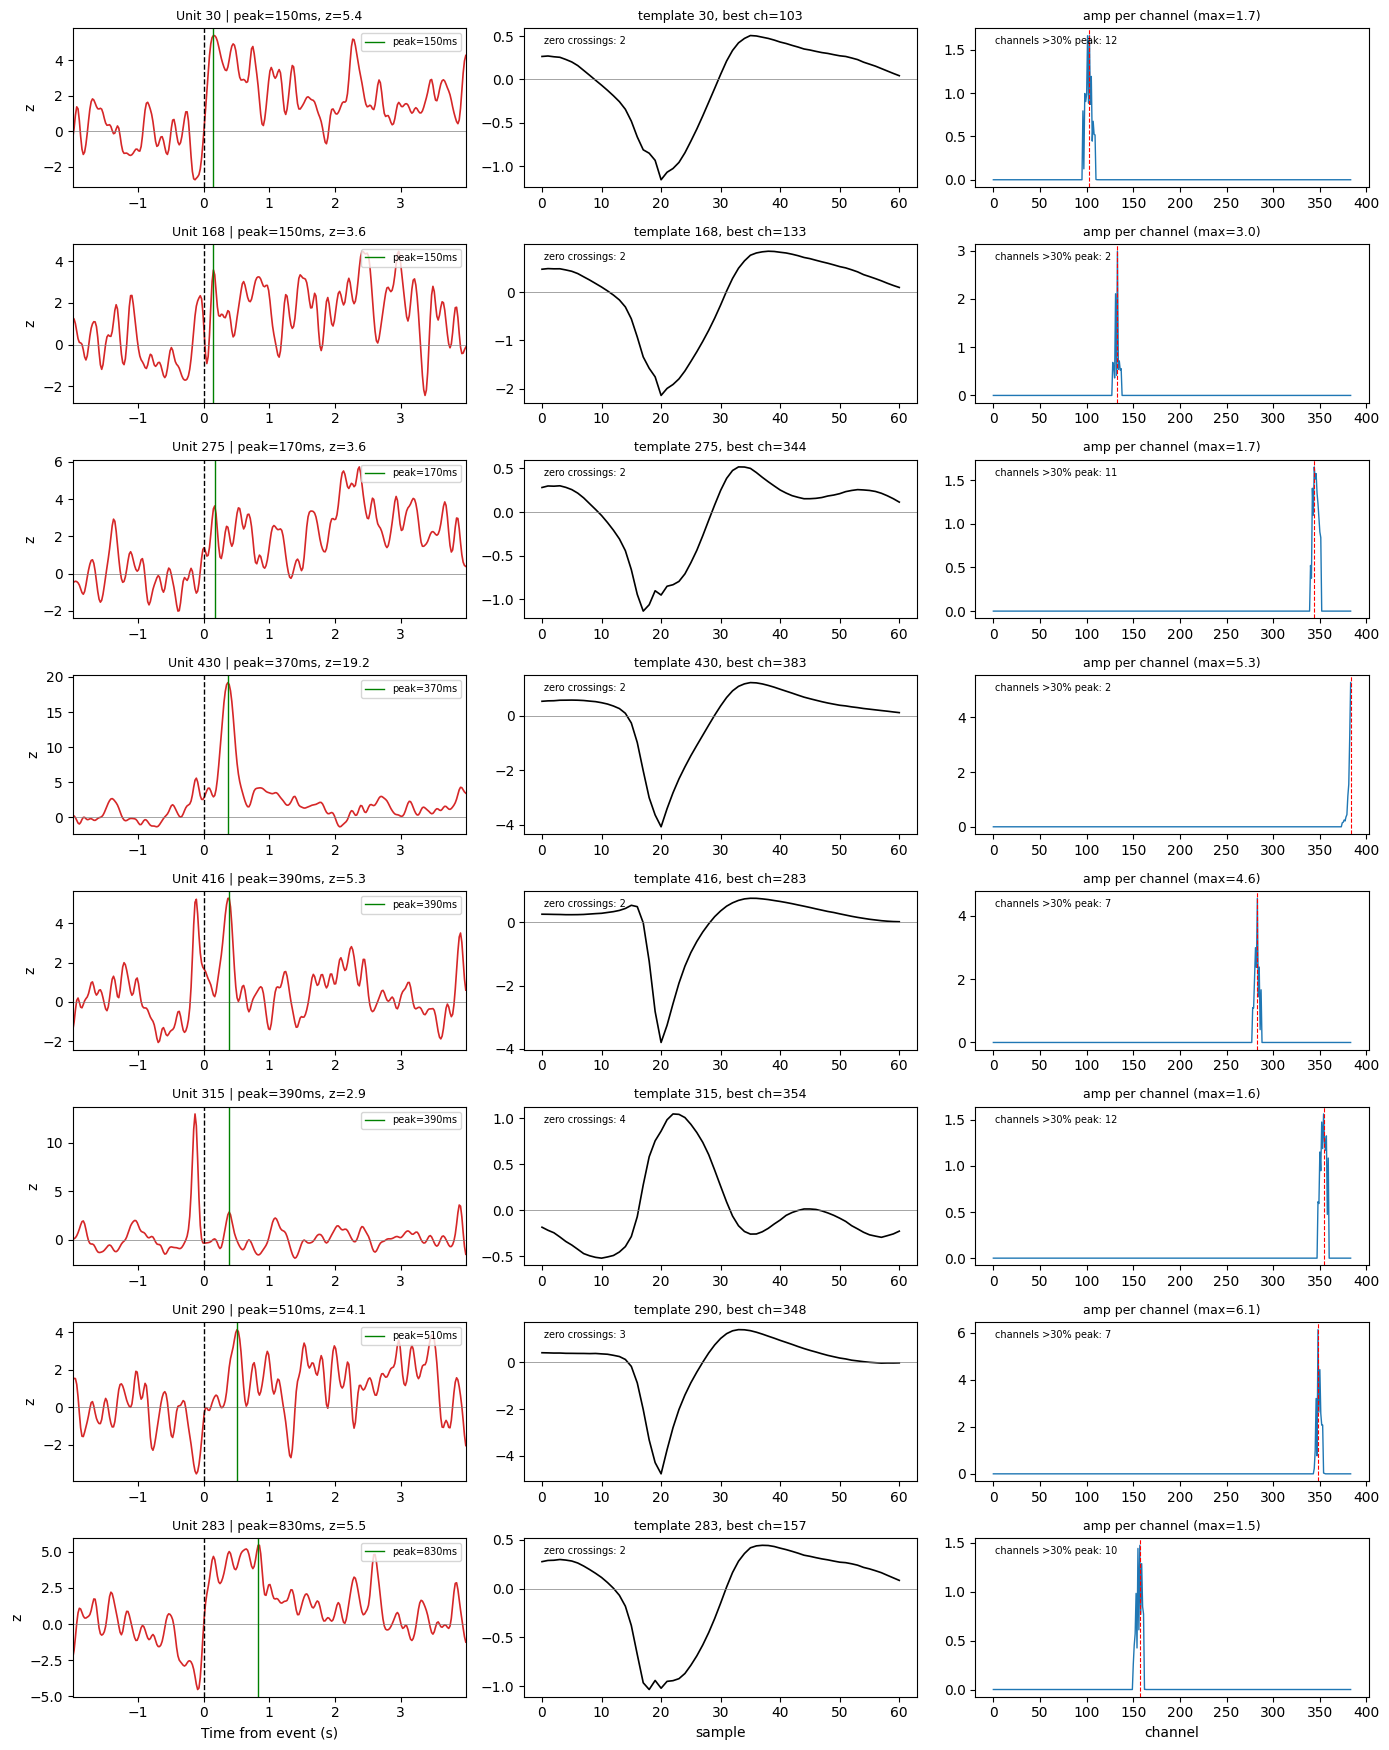


Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\fast_responder_check_pin4.png

===== INTERPRETATION HEURISTICS =====
For each unit, check:
  • Peak latency: <5 ms is suspicious; 10-50 ms is typical cortical;
    50-500 ms is typical for movement/cognitive responses.
  • Waveform: should be biphasic (~2-4 zero crossings near baseline),
    with peak-to-trough width ~0.3-1.5 ms. Symmetric or many-zero-crossing
    waveforms suggest noise/artifact.
  • Channel spread: real units appear on <~10 channels at >30% of peak.
    Units appearing strongly on >20 channels are likely common-mode
    artifacts contaminating multiple channels.

===== CELL J COMPLETE =====



In [10]:
# ============================================================
# CELL J — FAST-RESPONDER ARTIFACT CHECK
# ============================================================
# Inspects the fastest-peaking units from Cell H for signs of
# electrical / EMF artifact:
#   1. Peak latency — biological cortical responses are
#      typically ≥10-15 ms. Sub-5-ms responses are suspicious.
#   2. Waveform shape — pulls templates from the Kilosort
#      folder for the top-responding units.
#   3. Channel spread — real units live on a few neighboring
#      channels; artifacts often span the entire probe.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL J — FAST-RESPONDER ARTIFACT CHECK =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN     = 4
PROBEA_PATH   = r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4"
N_TOP_INSPECT = 10        # how many fastest-peaking modulated units to examine
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")

# ------------------------------------------------------------
# LOAD CELL H RESULTS
# ------------------------------------------------------------
arrays_path = analysis_folder / "qc" / f"modulation_pin{EVENT_PIN}_{event_label}_arrays.npz"
if not arrays_path.exists():
    raise FileNotFoundError(f"Run Cell H first. Missing: {arrays_path}")

H = np.load(arrays_path)
good_units    = H["good_units"]
z             = H["z"]
modulated     = H["modulated"]
peak_latency  = H["peak_latency"]
peak_z        = H["peak_z"]
centers       = H["centers"]

# Among modulated EXCITED units, find the fastest-peaking
mod_excited = modulated & (peak_z > 0)
mod_excited_idx = np.where(mod_excited)[0]
order_by_latency = mod_excited_idx[np.argsort(peak_latency[mod_excited_idx])]
top_idx = order_by_latency[:N_TOP_INSPECT]

print(f"Inspecting {len(top_idx)} fastest excited modulated units:")
for rank, ui in enumerate(top_idx):
    print(f"  #{rank+1}: unit {good_units[ui]}  "
          f"peak latency = {peak_latency[ui]*1000:.1f} ms, "
          f"peak z = {peak_z[ui]:.2f}")

# ------------------------------------------------------------
# LATENCY DIAGNOSTIC
# ------------------------------------------------------------
fastest_lat_ms = peak_latency[top_idx[0]] * 1000
print(f"\nFastest peak latency: {fastest_lat_ms:.1f} ms")
if fastest_lat_ms < 5:
    print("  ⚠ SUSPICIOUS: <5 ms is too fast for biological response.")
    print("    Likely candidates: EMF artifact, common-mode noise, "
          "shared spike-sorting template.")
elif fastest_lat_ms < 10:
    print("  ~ BORDERLINE: 5-10 ms is fast but possible for some "
          "subcortical or fast-fiber responses. Check waveforms.")
else:
    print("  ✓ OK: ≥10 ms is consistent with biological response latencies.")

# ------------------------------------------------------------
# LOAD KILOSORT TEMPLATES
# ------------------------------------------------------------
probe_dir = Path(PROBEA_PATH)
try:
    templates = np.load(probe_dir / "templates.npy")
    # templates.shape = (n_templates, n_timepoints, n_channels)
    spike_clusters = np.load(probe_dir / "spike_clusters.npy").flatten()
    spike_templates = np.load(probe_dir / "spike_templates.npy").flatten()
    print(f"\nLoaded templates: shape {templates.shape}")
except FileNotFoundError as e:
    print(f"\nCould not load templates: {e}")
    print("Skipping waveform analysis.")
    templates = None

# ------------------------------------------------------------
# FIGURE: PSTH + waveform + channel-amplitude for each top unit
# ------------------------------------------------------------
n_show = min(len(top_idx), 8)
fig, axes = plt.subplots(n_show, 3, figsize=(14, 2.2 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for k in range(n_show):
    ui = top_idx[k]
    unit_id = int(good_units[ui])

    # --- (1) PSTH ---
    ax = axes[k, 0]
    ax.plot(centers, z[ui], color="C3", lw=1.2)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="black", lw=1.0, linestyle="--")
    ax.axvline(peak_latency[ui], color="green", lw=1.0,
               label=f"peak={peak_latency[ui]*1000:.0f}ms")
    ax.set_xlim(centers[0], centers[-1])
    ax.set_ylabel("z")
    if k == n_show - 1:
        ax.set_xlabel("Time from event (s)")
    ax.set_title(f"Unit {unit_id} | peak={peak_latency[ui]*1000:.0f}ms, "
                 f"z={peak_z[ui]:.1f}", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")

    # --- (2) Waveform on best channel ---
    ax = axes[k, 1]
    if templates is not None:
        # Find the most-used template for this cluster
        cluster_spike_templates = spike_templates[spike_clusters == unit_id]
        if len(cluster_spike_templates) == 0:
            ax.text(0.5, 0.5, "no spikes", ha="center", va="center",
                    transform=ax.transAxes)
        else:
            t_id = np.bincount(cluster_spike_templates).argmax()
            wf = templates[t_id]   # (n_timepoints, n_channels)
            # peak-to-peak amplitude per channel
            ch_amp = wf.max(axis=0) - wf.min(axis=0)
            best_ch = int(np.argmax(ch_amp))
            ax.plot(wf[:, best_ch], color="black", lw=1.2)
            ax.set_title(f"template {t_id}, best ch={best_ch}", fontsize=9)
            # rough width estimate
            trace = wf[:, best_ch]
            ax.axhline(0, color="gray", lw=0.5)
            # check if waveform is biphasic
            n_zero_crossings = np.sum(np.diff(np.sign(trace)) != 0)
            ax.text(0.05, 0.95, f"zero crossings: {n_zero_crossings}",
                    transform=ax.transAxes, fontsize=7, va="top")
    else:
        ax.text(0.5, 0.5, "templates not loaded",
                ha="center", va="center", transform=ax.transAxes)
    if k == n_show - 1:
        ax.set_xlabel("sample")

    # --- (3) Amplitude across channels ---
    ax = axes[k, 2]
    if templates is not None and len(cluster_spike_templates) > 0:
        ax.plot(ch_amp, color="C0", lw=1.0)
        ax.set_title(f"amp per channel (max={ch_amp.max():.1f})", fontsize=9)
        ax.axvline(best_ch, color="red", lw=0.8, linestyle="--")
        # count channels with > 30% of peak
        n_strong = int((ch_amp > 0.3 * ch_amp.max()).sum())
        ax.text(0.05, 0.95, f"channels >30% peak: {n_strong}",
                transform=ax.transAxes, fontsize=7, va="top",
                color="red" if n_strong > 20 else "black")
    if k == n_show - 1:
        ax.set_xlabel("channel")

plt.tight_layout()

out_path = analysis_folder / "qc" / f"fast_responder_check_pin{EVENT_PIN}.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"fast_responder_check_pin{EVENT_PIN}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SUMMARY INTERPRETATION
# ------------------------------------------------------------
print("\n===== INTERPRETATION HEURISTICS =====")
print("For each unit, check:")
print("  • Peak latency: <5 ms is suspicious; 10-50 ms is typical cortical;")
print("    50-500 ms is typical for movement/cognitive responses.")
print("  • Waveform: should be biphasic (~2-4 zero crossings near baseline),")
print("    with peak-to-trough width ~0.3-1.5 ms. Symmetric or many-zero-crossing")
print("    waveforms suggest noise/artifact.")
print("  • Channel spread: real units appear on <~10 channels at >30% of peak.")
print("    Units appearing strongly on >20 channels are likely common-mode")
print("    artifacts contaminating multiple channels.")

print("\n===== CELL J COMPLETE =====\n")


===== CELL H — STRINGENT MODULATION DETECTION =====
Aligning to: tone_cue (pin 4), 55 events
Loaded 40 good units
Units with ≥1.0 Hz baseline: 38 / 40
Excluding 2 low-rate units from analysis

Computing session-wide baseline per unit...
Baseline rates: median=10.15 Hz, range 1.92 – 48.41 Hz

Calibrating Z threshold to give 10% false-positive rate under shuffled events (100 iterations)...
  25/100 done
  50/100 done
  75/100 done
  100/100 done

Shuffled FPR by Z threshold:
  Z>2.00:  shuffled FPR = 0.0%
  Z>2.25:  shuffled FPR = 0.0%
  Z>2.50:  shuffled FPR = 0.0%
  Z>2.75:  shuffled FPR = 0.0%
  Z>3.00:  shuffled FPR = 0.0%
  Z>3.25:  shuffled FPR = 0.0%
  Z>3.50:  shuffled FPR = 0.0%
  Z>3.75:  shuffled FPR = 0.0%
  Z>4.00:  shuffled FPR = 0.0%
  Z>4.25:  shuffled FPR = 0.0%
  Z>4.50:  shuffled FPR = 0.0%
  Z>4.75:  shuffled FPR = 0.0%
  Z>5.00:  shuffled FPR = 0.0%
  Z>5.25:  shuffled FPR = 0.0%
  Z>5.50:  shuffled FPR = 0.0%
  Z>5.75:  shuffled FPR = 0.0%
  Z>6.00:  shuffled FPR =

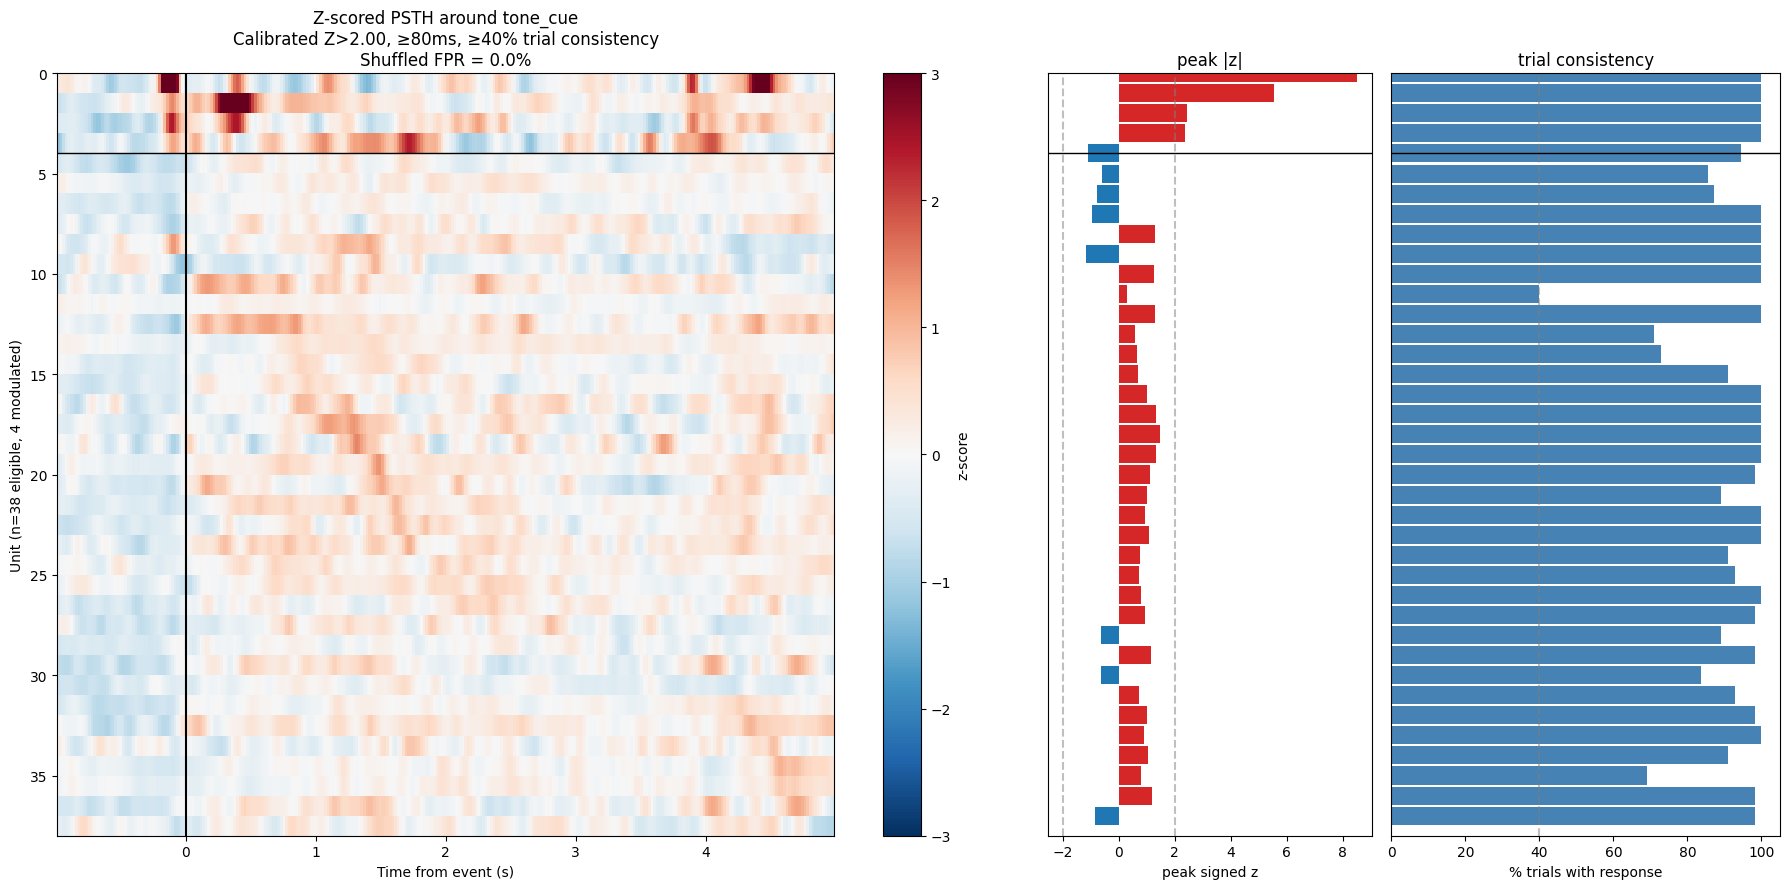


Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\modulation_strict_pin4_tone_cue.png

===== INTERPRETATION =====
  Eligible units (≥1.0 Hz):       38 / 40
  Calibrated threshold:                Z > 2.00
  Shuffled FPR at this threshold:      0.0%
  Modulated units (real data):         4
  Excess over chance:                  4 units above expected FPR

These 4 units are your defensible modulated set for tone_cue.

===== CELL H COMPLETE =====



In [11]:
# ============================================================
# CELL H — STRINGENT MODULATION DETECTION (PORTABLE)
# ============================================================
# Replaces the old Cell H + Cell I workflow.
#
# Core principles:
# 1. Session-wide baseline — each unit's null distribution comes
#    from random windows throughout the recording, not the brief
#    pre-event window (which can be contaminated by other events).
# 2. Auto-calibrated threshold — the Z threshold is set so that
#    shuffled-event analysis produces ~5% false positives in this
#    session. This makes the criterion adapt to per-session noise.
# 3. Per-trial consistency — a unit must show the response on
#    ≥CONSISTENCY_FRAC of trials, not just in trial-average.
# 4. Min baseline firing rate — units below this are excluded
#    from analysis (PSTHs are too noisy to be informative).
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL H — STRINGENT MODULATION DETECTION =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
EVENT_PIN          = 4            # 4=tone, 3=motor, 6=reach, 7=button
WIN_PRE            = 1.0          # seconds before event
WIN_POST           = 5.0          # seconds after event
RESPONSE_WIN       = (-0.5, 5.0)   # window where modulation must occur
BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
MIN_CONSECUTIVE_MS = 80          # need this long of |z|>threshold
MIN_BASELINE_HZ    = 1.0          # exclude units firing below this
CONSISTENCY_FRAC   = 0.40         # response must appear on ≥40% of trials
N_SHUFFLES_CALIB   = 100          # shuffles used to calibrate threshold
TARGET_FPR         = 0.10         # target shuffled false-positive rate
RANDOM_SEED        = 42
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
pin_labels = session["pin_labels"]
event_label = pin_labels.get(str(EVENT_PIN), f"pin {EVENT_PIN}")
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD EVENT TIMES + UNITS
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
event_times = np.load(ttls_dir / f"TTL_Pin_{EVENT_PIN}.npy")
n_events = len(event_times)
print(f"Aligning to: {event_label} (pin {EVENT_PIN}), {n_events} events")

good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"
all_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}
print(f"Loaded {len(good_units)} good units")

# ------------------------------------------------------------
# FILTER UNITS BY MIN BASELINE FIRING RATE
# ------------------------------------------------------------
unit_rates = np.array([len(all_spikes[int(u)]) / recording_duration
                       for u in good_units])
eligible = unit_rates >= MIN_BASELINE_HZ
n_eligible = int(eligible.sum())
print(f"Units with ≥{MIN_BASELINE_HZ} Hz baseline: {n_eligible} / {len(good_units)}")
print(f"Excluding {len(good_units) - n_eligible} low-rate units from analysis")

eligible_units = good_units[eligible]

# ------------------------------------------------------------
# SHARED COMPUTATION HELPERS
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

# ------------------------------------------------------------
# COMPUTE SESSION-WIDE BASELINE PER UNIT
# ------------------------------------------------------------
# For each unit, sample many random windows of duration matching
# the response window. The mean and std of these "null" rates
# becomes that unit's baseline distribution.
# ------------------------------------------------------------
print("\nComputing session-wide baseline per unit...")
rng = np.random.default_rng(RANDOM_SEED)

resp_dur = RESPONSE_WIN[1] - RESPONSE_WIN[0]
t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0
n_null_windows = 500

baseline_mean = np.zeros(len(eligible_units))
baseline_std  = np.zeros(len(eligible_units))

for i, u in enumerate(eligible_units):
    spk = all_spikes[int(u)]
    null_starts = rng.uniform(t_min, t_max - resp_dur, size=n_null_windows)
    null_rates = np.zeros(n_null_windows)
    for j, ts in enumerate(null_starts):
        null_rates[j] = ((spk >= ts) & (spk < ts + resp_dur)).sum() / resp_dur
    baseline_mean[i] = null_rates.mean()
    baseline_std[i]  = null_rates.std()
# floor std at 1% of mean to avoid div-by-zero for very stable units
baseline_std = np.maximum(baseline_std, baseline_mean * 0.01 + 0.1)

print(f"Baseline rates: median={np.median(baseline_mean):.2f} Hz, "
      f"range {baseline_mean.min():.2f} – {baseline_mean.max():.2f} Hz")

# ------------------------------------------------------------
# CORE: compute per-trial PSTH and z-score for a set of events
# ------------------------------------------------------------
def compute_per_trial_z(events):
    """Returns (psth_smooth_per_trial, psth_smooth_mean) z-scored against
    SESSION-WIDE baseline (not per-event baseline).
    Shape: (n_units, n_trials, n_bins) and (n_units, n_bins)"""
    psth_per_trial = np.zeros((len(eligible_units), len(events), n_bins))
    for u_i, u in enumerate(eligible_units):
        spk = all_spikes[int(u)]
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            psth_per_trial[u_i, e_i] = h / BIN_SIZE
    # smooth each trial
    psth_smooth_per_trial = gaussian_filter1d(psth_per_trial,
                                              sigma=SMOOTH_SIGMA_BINS, axis=2)
    psth_smooth_mean = psth_smooth_per_trial.mean(axis=1)
    # z-score against session-wide baseline
    z_mean = ((psth_smooth_mean - baseline_mean[:, None])
              / baseline_std[:, None])
    return psth_smooth_per_trial, psth_smooth_mean, z_mean

# ------------------------------------------------------------
# MODULATION CRITERION (parameterized so we can tune Z threshold)
# ------------------------------------------------------------
def count_modulated(z_mat, z_thresh):
    """Returns boolean array per unit: |z|>thresh for ≥min_consec_bins in
    response window."""
    z_resp = z_mat[:, response_mask]
    out = np.zeros(z_resp.shape[0], dtype=bool)
    for i in range(z_resp.shape[0]):
        for arr in (z_resp[i] > z_thresh, z_resp[i] < -z_thresh):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            diffs = np.diff(padded.astype(int))
            starts = np.where(diffs ==  1)[0]
            ends   = np.where(diffs == -1)[0]
            if (ends - starts).max() >= min_consec_bins:
                out[i] = True
                break
    return out

# ------------------------------------------------------------
# CALIBRATE Z THRESHOLD ON SHUFFLED EVENTS
# ------------------------------------------------------------
# Run N_SHUFFLES_CALIB shuffles. For each, compute z-scored PSTHs and
# tally "modulated unit count" at a grid of Z thresholds.
# Pick the lowest Z threshold that gives ≤TARGET_FPR mean shuffled rate.
# ------------------------------------------------------------
print(f"\nCalibrating Z threshold to give {TARGET_FPR*100:.0f}% false-positive rate "
      f"under shuffled events ({N_SHUFFLES_CALIB} iterations)...")

z_thresh_grid = np.arange(2.0, 6.01, 0.25)
shuffled_fpr = np.zeros((N_SHUFFLES_CALIB, len(z_thresh_grid)))

for s in range(N_SHUFFLES_CALIB):
    fake_events = rng.uniform(t_min, t_max, size=n_events)
    fake_events.sort()
    _, _, fake_z = compute_per_trial_z(fake_events)
    for j, thr in enumerate(z_thresh_grid):
        shuffled_fpr[s, j] = count_modulated(fake_z, thr).sum() / len(eligible_units)
    if (s + 1) % 25 == 0:
        print(f"  {s+1}/{N_SHUFFLES_CALIB} done")

mean_fpr_by_thresh = shuffled_fpr.mean(axis=0)
print("\nShuffled FPR by Z threshold:")
for thr, fpr in zip(z_thresh_grid, mean_fpr_by_thresh):
    flag = "  ← target" if (fpr <= TARGET_FPR and (
        len(z_thresh_grid) == 0 or fpr > TARGET_FPR - 0.02)) else ""
    print(f"  Z>{thr:.2f}:  shuffled FPR = {fpr*100:.1f}%{flag}")

# Pick smallest Z that achieves target FPR
viable = np.where(mean_fpr_by_thresh <= TARGET_FPR)[0]
if len(viable) == 0:
    print(f"\nWARNING: no threshold achieves ≤{TARGET_FPR*100:.0f}% FPR even at "
          f"Z=6. Picking Z={z_thresh_grid[-1]} and reporting actual FPR.")
    z_thresh_chosen = float(z_thresh_grid[-1])
else:
    z_thresh_chosen = float(z_thresh_grid[viable[0]])

calibrated_fpr = mean_fpr_by_thresh[
    np.argmin(np.abs(z_thresh_grid - z_thresh_chosen))]
print(f"\nCalibrated Z threshold: {z_thresh_chosen:.2f}  "
      f"(shuffled FPR = {calibrated_fpr*100:.1f}%)")

# ------------------------------------------------------------
# APPLY CALIBRATED CRITERION TO REAL EVENTS
# ------------------------------------------------------------
print(f"\nApplying calibrated criterion to real {event_label} events...")
real_per_trial, real_mean, real_z = compute_per_trial_z(event_times)
modulated_initial = count_modulated(real_z, z_thresh_chosen)
n_initial = int(modulated_initial.sum())
print(f"Units passing Z criterion (trial-averaged): {n_initial} / {len(eligible_units)}")

# ------------------------------------------------------------
# CONSISTENCY FILTER: response must appear on ≥CONSISTENCY_FRAC trials
# ------------------------------------------------------------
# For each unit that passed the trial-averaged criterion, ask: on what
# fraction of individual trials does the unit show ANY bin in the
# response window with rate > baseline_mean + z_thresh*baseline_std?
# ------------------------------------------------------------
print(f"\nApplying consistency filter (≥{CONSISTENCY_FRAC*100:.0f}% of trials)...")

per_trial_z = ((real_per_trial - baseline_mean[:, None, None])
               / baseline_std[:, None, None])
per_trial_z_resp = per_trial_z[:, :, response_mask]

# fraction of trials where the unit has at least one bin |z|>thresh
trial_resp_pos = (per_trial_z_resp > z_thresh_chosen).any(axis=2)
trial_resp_neg = (per_trial_z_resp < -z_thresh_chosen).any(axis=2)
trial_resp_either = trial_resp_pos | trial_resp_neg
trial_consistency = trial_resp_either.mean(axis=1)

modulated_final = modulated_initial & (trial_consistency >= CONSISTENCY_FRAC)
n_final = int(modulated_final.sum())
print(f"Units also passing consistency filter: {n_final} / {len(eligible_units)}")

# ------------------------------------------------------------
# LATENCY + SIGN
# ------------------------------------------------------------
response_centers = centers[response_mask]
z_resp = real_z[:, response_mask]
peak_idx = np.argmax(np.abs(z_resp), axis=1)
peak_latency = response_centers[peak_idx]
peak_z = z_resp[np.arange(len(eligible_units)), peak_idx]

# ------------------------------------------------------------
# SORT FOR PLOTTING
# ------------------------------------------------------------
final_idx = np.where(modulated_final)[0]
excited_mask = peak_z[final_idx] > 0
excited_order = final_idx[excited_mask][np.argsort(peak_latency[final_idx[excited_mask]])]
suppressed_order = final_idx[~excited_mask][np.argsort(peak_latency[final_idx[~excited_mask]])]
sorted_mod_idx = np.concatenate([excited_order, suppressed_order])

# Non-modulated at bottom (also sorted, just for readability)
non_mod_idx = np.where(~modulated_final)[0]
non_mod_order = non_mod_idx[np.argsort(peak_latency[non_mod_idx])]
full_sort_idx = np.concatenate([sorted_mod_idx, non_mod_order])

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 9),
                          gridspec_kw={"width_ratios": [3, 1, 1.2]})

vmax = max(3.0, np.percentile(np.abs(real_z), 99))

ax = axes[0]
im = ax.imshow(real_z[full_sort_idx], aspect="auto",
               extent=[centers[0], centers[-1], len(eligible_units), 0],
               cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_xlabel("Time from event (s)")
ax.set_ylabel(f"Unit (n={len(eligible_units)} eligible, "
              f"{n_final} modulated)")
ax.set_title(f"Z-scored PSTH around {event_label}\n"
             f"Calibrated Z>{z_thresh_chosen:.2f}, ≥{MIN_CONSECUTIVE_MS}ms, "
             f"≥{CONSISTENCY_FRAC*100:.0f}% trial consistency\n"
             f"Shuffled FPR = {calibrated_fpr*100:.1f}%")
plt.colorbar(im, ax=ax, label="z-score")

# Side: peak signed z
ax = axes[1]
y = np.arange(len(eligible_units))
peak_z_sorted = peak_z[full_sort_idx]
colors = np.where(peak_z_sorted > 0, "C3", "C0")
ax.barh(y, peak_z_sorted, color=colors, height=0.9)
ax.axvline(z_thresh_chosen, color="gray", linestyle="--", alpha=0.5)
ax.axvline(-z_thresh_chosen, color="gray", linestyle="--", alpha=0.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(eligible_units), 0)
ax.set_xlabel("peak signed z")
ax.set_yticks([])
ax.set_title("peak |z|")

# Side: trial consistency
ax = axes[2]
ax.barh(y, trial_consistency[full_sort_idx] * 100,
        color="steelblue", height=0.9)
ax.axvline(CONSISTENCY_FRAC * 100, color="gray", linestyle="--", alpha=0.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(eligible_units), 0)
ax.set_xlabel("% trials with response")
ax.set_yticks([])
ax.set_title("trial consistency")

plt.tight_layout()

out_dir = analysis_folder / "qc"
out_path = out_dir / f"modulation_strict_pin{EVENT_PIN}_{event_label}.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"modulation_strict_pin{EVENT_PIN}_{event_label}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------
results = {
    "event_pin": int(EVENT_PIN),
    "event_label": event_label,
    "n_events": int(n_events),
    "n_units_total": int(len(good_units)),
    "n_units_eligible": int(len(eligible_units)),
    "n_modulated": int(n_final),
    "z_threshold_calibrated": float(z_thresh_chosen),
    "shuffled_fpr_at_threshold": float(calibrated_fpr),
    "min_baseline_hz": float(MIN_BASELINE_HZ),
    "consistency_frac": float(CONSISTENCY_FRAC),
    "min_consecutive_ms": float(MIN_CONSECUTIVE_MS),
    "bin_size_s": float(BIN_SIZE),
    "response_win_s": list(RESPONSE_WIN),
    "n_shuffles_calib": int(N_SHUFFLES_CALIB),
    "target_fpr": float(TARGET_FPR),
}
with open(out_dir / f"modulation_strict_pin{EVENT_PIN}_{event_label}.json", "w") as f:
    json.dump(results, f, indent=2)

np.savez(out_dir / f"modulation_strict_pin{EVENT_PIN}_{event_label}_arrays.npz",
         eligible_units=eligible_units,
         z_mean=real_z,
         modulated=modulated_final,
         trial_consistency=trial_consistency,
         peak_latency=peak_latency,
         peak_z=peak_z,
         sort_order=full_sort_idx,
         centers=centers,
         z_threshold=z_thresh_chosen)

print("\n===== INTERPRETATION =====")
print(f"  Eligible units (≥{MIN_BASELINE_HZ} Hz):       {len(eligible_units)} / {len(good_units)}")
print(f"  Calibrated threshold:                Z > {z_thresh_chosen:.2f}")
print(f"  Shuffled FPR at this threshold:      {calibrated_fpr*100:.1f}%")
print(f"  Modulated units (real data):         {n_final}")
print(f"  Excess over chance:                  "
      f"{n_final - len(eligible_units)*calibrated_fpr:.0f} units above expected FPR")
print(f"\nThese {n_final} units are your defensible modulated set for "
      f"{event_label}.")
print("\n===== CELL H COMPLETE =====\n")


===== CELL I — REACH DETECTION DIAGNOSTIC =====

Loaded 130925 frames
Time range: 40.202 → 2223.363 s
Effective FPS (median Δt): 59.97 Hz

Dropped-frame gaps (Δt > 25.0 ms): 0
Total time inside gaps: 0.0 s (0.0% of session)

Frame validity:
  In range (150-380): 106218 / 130925
  Likelihood ≥ 0.9: 107201 / 130925
  Both (kept for analysis): 84467 / 130925 (64.5%)

Pin 3 (motor): 110 events
Trials: 55
Trial durations: mean=18.097 s, std=4.750 s, range 5.263 - 20.284 s

Frames outside trial windows (and valid): 47832 / 130925
Non-trial paw X: median=165.8, 5–95th pct=[151.3, 209.2], IQR=15.5
In-trial paw X: median=168.9, 95th pct=210.2, 99th pct=217.8

Computing stability metric (range of paw X in ±250 ms window)...
  Rolling window (30 frames)...
  Frames with valid stability metric: 66068
  Within-window range distribution (pixels):
    10th pct: 0.48
    25th pct: 0.65
    50th pct: 1.06
    75th pct: 2.59
    90th pct: 6.02
  → Recommended stability threshold (25th pct): 0.65 pixels

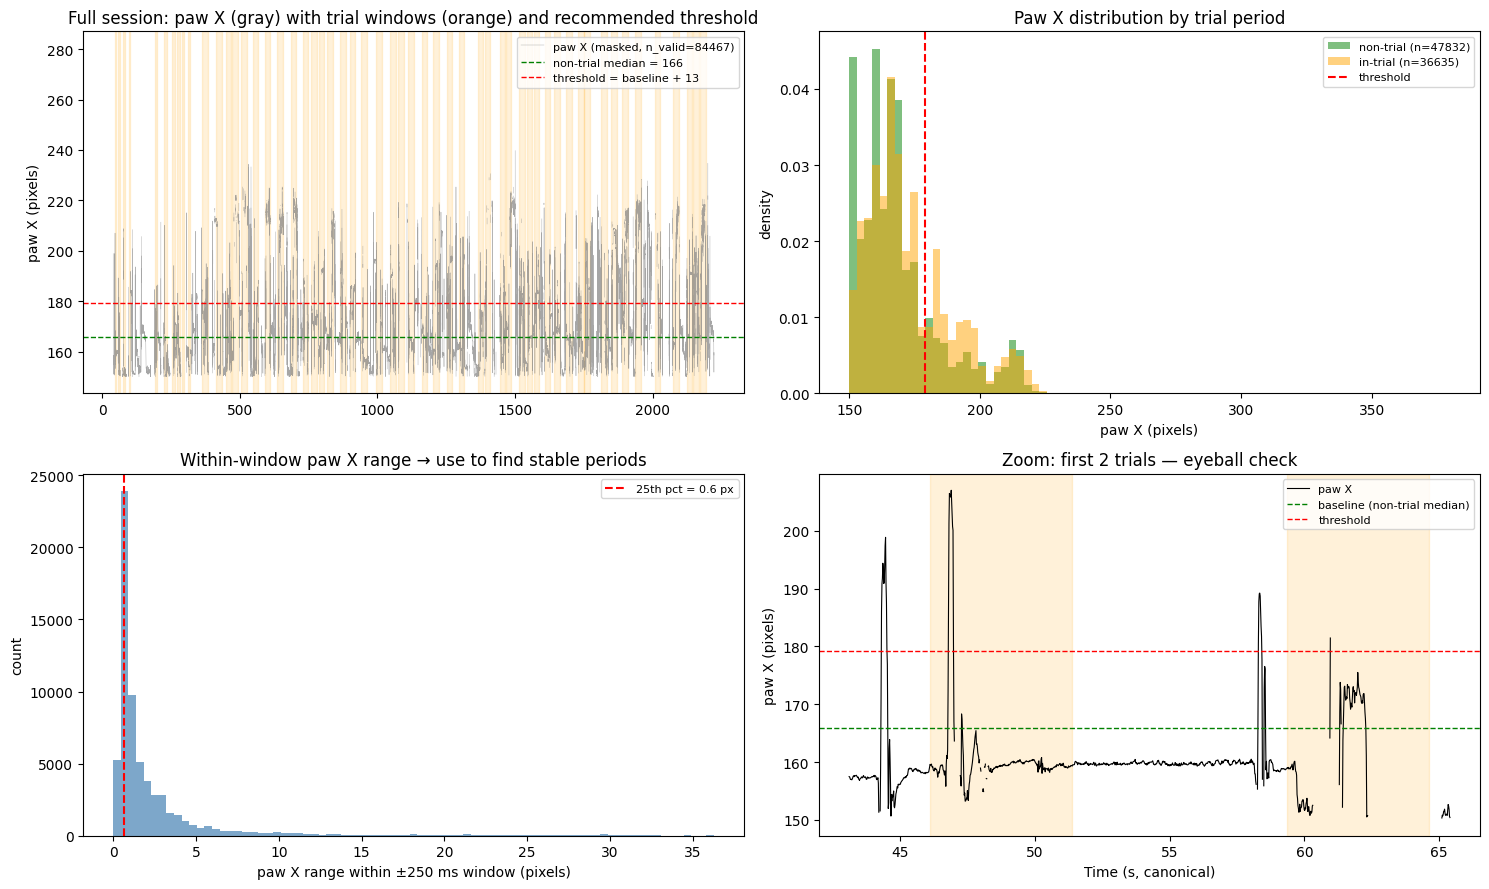


Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\reach_detection_diagnostic.png

RECOMMENDED PARAMETERS FOR CELL J
  AMPLITUDE_THRESH      = 13.3   # pixels above baseline
  STABILITY_THRESH      = 0.6   # max within-window range
  STABILITY_WIN_S       = 0.5   # sliding-window width
  PAW_X_VALID           = (150, 380)
  PAW_LIKELIHOOD_MIN    = 0.9
  BASELINE_INIT         = 165.8   # starting baseline X
  PELLET_MOTOR_PIN      = 3

Look at the diagnostic plot, especially the bottom-right zoom panel.
If the red threshold line cleanly separates baseline from reaches,
the recommended values are good. Otherwise tune and re-run.

===== CELL I COMPLETE =====



In [12]:
# ============================================================
# CELL I — REACH DETECTION DIAGNOSTIC (PORTABLE)
# ============================================================
# Examines paw kinematics to recommend detection parameters.
# Does NOT detect reaches — only prints/plots distributions
# that inform what thresholds to use in Cell J.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import uniform_filter1d

print("\n===== CELL I — REACH DETECTION DIAGNOSTIC =====")

# ------------------------------------------------------------
# USER EDIT — sanity bounds for paw X (mask anything outside)
# ------------------------------------------------------------
PAW_X_VALID = (150, 380)   # generous bounds; everything outside = mask out
PAW_LIKELIHOOD_MIN = 0.90  # DLC likelihood threshold
STABILITY_WIN_S = 0.5      # sliding-window width for "is paw stable?"
PELLET_MOTOR_PIN = 3
TRIAL_DURATION_S = 20.0    # expected window between pellet expose & retract
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# Load DLC + frame timing
dlc = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
frame_t = dlc["canonical_time"]
paw_x   = dlc["paw_x"].astype(float)
paw_y   = dlc["paw_y"].astype(float)
paw_lik = dlc["paw_likelihood"].astype(float)
n_frames = len(frame_t)

print(f"\nLoaded {n_frames} frames")
print(f"Time range: {frame_t[0]:.3f} → {frame_t[-1]:.3f} s")

# Estimate effective FPS from median frame interval
median_dt = float(np.median(np.diff(frame_t)))
fps = 1.0 / median_dt
print(f"Effective FPS (median Δt): {fps:.2f} Hz")

# ------------------------------------------------------------
# DROPPED-FRAME GAP DETECTION
# ------------------------------------------------------------
diffs = np.diff(frame_t)
gap_threshold = 1.5 * median_dt
gap_mask_per_diff = diffs > gap_threshold
n_gaps = int(gap_mask_per_diff.sum())
total_gap_time = float(diffs[gap_mask_per_diff].sum())
print(f"\nDropped-frame gaps (Δt > {gap_threshold*1000:.1f} ms): {n_gaps}")
print(f"Total time inside gaps: {total_gap_time:.1f} s "
      f"({100*total_gap_time/recording_duration:.1f}% of session)")
if n_gaps > 0:
    print(f"Gap durations: median={np.median(diffs[gap_mask_per_diff]):.3f} s, "
          f"max={diffs[gap_mask_per_diff].max():.3f} s")

# ------------------------------------------------------------
# MASKING: out-of-range OR low-likelihood
# ------------------------------------------------------------
valid = ((paw_x >= PAW_X_VALID[0]) & (paw_x <= PAW_X_VALID[1])
         & (paw_lik >= PAW_LIKELIHOOD_MIN))
n_valid = int(valid.sum())
print(f"\nFrame validity:")
print(f"  In range ({PAW_X_VALID[0]}-{PAW_X_VALID[1]}): "
      f"{int(((paw_x >= PAW_X_VALID[0]) & (paw_x <= PAW_X_VALID[1])).sum())} "
      f"/ {n_frames}")
print(f"  Likelihood ≥ {PAW_LIKELIHOOD_MIN}: "
      f"{int((paw_lik >= PAW_LIKELIHOOD_MIN).sum())} / {n_frames}")
print(f"  Both (kept for analysis): {n_valid} / {n_frames} "
      f"({100*n_valid/n_frames:.1f}%)")

# Build masked paw X (NaN where invalid)
paw_x_masked = paw_x.copy()
paw_x_masked[~valid] = np.nan

# ------------------------------------------------------------
# TRIAL WINDOWS FROM PIN 3
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
motor_times = np.load(ttls_dir / f"TTL_Pin_{PELLET_MOTOR_PIN}.npy")
print(f"\nPin {PELLET_MOTOR_PIN} (motor): {len(motor_times)} events")

if len(motor_times) % 2 != 0:
    print(f"  WARNING: odd number of motor events. "
          f"Last event ({motor_times[-1]:.3f} s) will be ignored.")
    motor_times = motor_times[:-1]

trial_starts = motor_times[0::2]   # pellet expose
trial_ends   = motor_times[1::2]   # pellet retract
trial_durs   = trial_ends - trial_starts
print(f"Trials: {len(trial_starts)}")
print(f"Trial durations: mean={trial_durs.mean():.3f} s, "
      f"std={trial_durs.std():.3f} s, "
      f"range {trial_durs.min():.3f} - {trial_durs.max():.3f} s")

if abs(trial_durs.mean() - TRIAL_DURATION_S) > 0.5:
    print(f"  WARNING: mean trial duration ({trial_durs.mean():.2f} s) "
          f"differs from expected ({TRIAL_DURATION_S} s) by >0.5 s. "
          f"Check that pin {PELLET_MOTOR_PIN} is the right pin.")

# ------------------------------------------------------------
# CHARACTERIZE NON-TRIAL "BASELINE-ONLY" PERIODS
# ------------------------------------------------------------
# Find frames that are NOT inside any trial window — these should be
# mostly paw-at-rest periods that characterize the baseline distribution.
# ------------------------------------------------------------
in_trial = np.zeros(n_frames, dtype=bool)
for ts, te in zip(trial_starts, trial_ends):
    in_trial |= (frame_t >= ts) & (frame_t <= te)
non_trial_valid = valid & ~in_trial
print(f"\nFrames outside trial windows (and valid): "
      f"{int(non_trial_valid.sum())} / {n_frames}")

baseline_x_samples = paw_x[non_trial_valid]
if len(baseline_x_samples) > 100:
    bx_median = float(np.median(baseline_x_samples))
    bx_p5  = float(np.percentile(baseline_x_samples, 5))
    bx_p95 = float(np.percentile(baseline_x_samples, 95))
    bx_iqr = float(np.percentile(baseline_x_samples, 75)
                   - np.percentile(baseline_x_samples, 25))
    print(f"Non-trial paw X: median={bx_median:.1f}, "
          f"5–95th pct=[{bx_p5:.1f}, {bx_p95:.1f}], IQR={bx_iqr:.1f}")
else:
    print("Not enough non-trial frames — using full session as baseline reference.")
    baseline_x_samples = paw_x[valid]
    bx_median = float(np.median(baseline_x_samples))
    bx_iqr = float(np.percentile(baseline_x_samples, 75)
                   - np.percentile(baseline_x_samples, 25))

# ------------------------------------------------------------
# IN-TRIAL PAW X DISTRIBUTION (REACHES + REST)
# ------------------------------------------------------------
in_trial_valid = valid & in_trial
trial_x_samples = paw_x[in_trial_valid]
if len(trial_x_samples) > 100:
    tx_median = float(np.median(trial_x_samples))
    tx_p95   = float(np.percentile(trial_x_samples, 95))
    tx_p99   = float(np.percentile(trial_x_samples, 99))
    print(f"In-trial paw X: median={tx_median:.1f}, "
          f"95th pct={tx_p95:.1f}, 99th pct={tx_p99:.1f}")

# ------------------------------------------------------------
# STABILITY WINDOW: distribution of within-window range
# ------------------------------------------------------------
# For each frame, compute the range (max - min) of paw X in a window of
# ±STABILITY_WIN_S/2 around it. Use only valid frames.
# ------------------------------------------------------------
print(f"\nComputing stability metric (range of paw X in ±{STABILITY_WIN_S/2*1000:.0f} ms window)...")
win_frames = max(3, int(round(STABILITY_WIN_S * fps)))
half = win_frames // 2

# For speed, compute rolling max and min on the masked array
# (NaN-aware would be ideal but slow; we replace NaN with a sentinel and
# discard ranges where any NaN appears)
sentinel = np.inf
x_for_range = np.where(valid, paw_x, sentinel)
roll_max = np.empty_like(paw_x)
roll_min = np.empty_like(paw_x)
roll_max[:] = np.nan
roll_min[:] = np.nan
# Brute-force is fine here for ~100k frames
print(f"  Rolling window ({win_frames} frames)...")
for i in range(half, n_frames - half):
    window = x_for_range[i - half : i + half + 1]
    if np.isinf(window).any():
        continue
    roll_max[i] = window.max()
    roll_min[i] = window.min()

roll_range = roll_max - roll_min
valid_range = roll_range[~np.isnan(roll_range)]
print(f"  Frames with valid stability metric: {len(valid_range)}")
if len(valid_range) > 0:
    print(f"  Within-window range distribution (pixels):")
    for pct in [10, 25, 50, 75, 90]:
        print(f"    {pct}th pct: {np.percentile(valid_range, pct):.2f}")
    stable_thresh_recommended = float(np.percentile(valid_range, 25))
    print(f"  → Recommended stability threshold (25th pct): "
          f"{stable_thresh_recommended:.2f} pixels")

# ------------------------------------------------------------
# RECOMMENDED REACH AMPLITUDE THRESHOLD
# ------------------------------------------------------------
# A reach is "X excursion above baseline" where the baseline is the
# resting position. A reasonable threshold: 0.3 × (in-trial 95th pct
# minus non-trial median). This is roughly 30% of the typical reach
# amplitude — large enough to ignore baseline jitter, small enough to
# catch most movements.
# ------------------------------------------------------------
if len(trial_x_samples) > 100 and len(baseline_x_samples) > 100:
    typical_reach_amp = tx_p95 - bx_median
    amp_thresh_recommended = 0.3 * typical_reach_amp
    print(f"\nReach amplitude analysis:")
    print(f"  Non-trial baseline (median X): {bx_median:.1f} pixels")
    print(f"  In-trial 95th pct X:           {tx_p95:.1f} pixels")
    print(f"  Typical reach amplitude:        {typical_reach_amp:.1f} pixels")
    print(f"  → Recommended threshold (0.3 ×): {amp_thresh_recommended:.1f} pixels")
    print(f"     (your old default was +25 pixels)")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# (1) Paw X over full session, color-coded by trial
ax = axes[0, 0]
ax.plot(frame_t, paw_x_masked, lw=0.3, color="gray", alpha=0.7,
        label=f"paw X (masked, n_valid={n_valid})")
for ts, te in zip(trial_starts, trial_ends):
    ax.axvspan(ts, te, alpha=0.15, color="orange")
ax.axhline(bx_median, color="green", lw=1.0, linestyle="--",
           label=f"non-trial median = {bx_median:.0f}")
ax.axhline(bx_median + amp_thresh_recommended, color="red", lw=1.0,
           linestyle="--",
           label=f"threshold = baseline + {amp_thresh_recommended:.0f}")
ax.set_ylabel("paw X (pixels)")
ax.set_title("Full session: paw X (gray) with trial windows (orange) "
             "and recommended threshold")
ax.legend(fontsize=8)

# (2) Histogram of paw X — non-trial vs in-trial
ax = axes[0, 1]
bins = np.linspace(PAW_X_VALID[0], PAW_X_VALID[1], 80)
ax.hist(baseline_x_samples, bins=bins, alpha=0.5, color="green",
        label=f"non-trial (n={len(baseline_x_samples)})", density=True)
ax.hist(trial_x_samples, bins=bins, alpha=0.5, color="orange",
        label=f"in-trial (n={len(trial_x_samples)})", density=True)
ax.axvline(bx_median + amp_thresh_recommended, color="red", lw=1.5,
           linestyle="--", label="threshold")
ax.set_xlabel("paw X (pixels)")
ax.set_ylabel("density")
ax.set_title("Paw X distribution by trial period")
ax.legend(fontsize=8)

# (3) Histogram of within-window range (stability metric)
ax = axes[1, 0]
if len(valid_range) > 0:
    bins = np.linspace(0, np.percentile(valid_range, 99), 80)
    ax.hist(valid_range, bins=bins, color="steelblue", alpha=0.7)
    ax.axvline(stable_thresh_recommended, color="red", lw=1.5, linestyle="--",
               label=f"25th pct = {stable_thresh_recommended:.1f} px")
    ax.set_xlabel(f"paw X range within ±{STABILITY_WIN_S/2*1000:.0f} ms window (pixels)")
    ax.set_ylabel("count")
    ax.set_title("Within-window paw X range → use to find stable periods")
    ax.legend(fontsize=8)

# (4) Zoom on first 2 trials
ax = axes[1, 1]
if len(trial_starts) >= 1:
    ts0 = trial_starts[0] - 3
    te0 = (trial_ends[1] + 3) if len(trial_ends) > 1 else trial_ends[0] + 5
    zoom_mask = (frame_t >= ts0) & (frame_t <= te0)
    ax.plot(frame_t[zoom_mask], paw_x_masked[zoom_mask], lw=0.8, color="black",
            label="paw X")
    for ts, te in zip(trial_starts[:2], trial_ends[:2]):
        ax.axvspan(ts, te, alpha=0.15, color="orange")
    ax.axhline(bx_median, color="green", lw=1.0, linestyle="--",
               label="baseline (non-trial median)")
    ax.axhline(bx_median + amp_thresh_recommended, color="red", lw=1.0,
               linestyle="--", label="threshold")
    ax.set_xlabel("Time (s, canonical)")
    ax.set_ylabel("paw X (pixels)")
    ax.set_title("Zoom: first 2 trials — eyeball check")
    ax.legend(fontsize=8)

plt.tight_layout()

# Save
out_path = analysis_folder / "qc" / "reach_detection_diagnostic.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"reach_detection_diagnostic_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# RECOMMENDATIONS SUMMARY
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RECOMMENDED PARAMETERS FOR CELL J")
print("=" * 60)
print(f"  AMPLITUDE_THRESH      = {amp_thresh_recommended:.1f}   # pixels above baseline")
print(f"  STABILITY_THRESH      = {stable_thresh_recommended:.1f}   # max within-window range")
print(f"  STABILITY_WIN_S       = {STABILITY_WIN_S}   # sliding-window width")
print(f"  PAW_X_VALID           = {PAW_X_VALID}")
print(f"  PAW_LIKELIHOOD_MIN    = {PAW_LIKELIHOOD_MIN}")
print(f"  BASELINE_INIT         = {bx_median:.1f}   # starting baseline X")
print(f"  PELLET_MOTOR_PIN      = {PELLET_MOTOR_PIN}")
print()
print("Look at the diagnostic plot, especially the bottom-right zoom panel.")
print("If the red threshold line cleanly separates baseline from reaches,")
print("the recommended values are good. Otherwise tune and re-run.")
print()
print("===== CELL I COMPLETE =====\n")


===== CELL J — REACH DETECTION (v3) =====
Loaded 130925 frames, FPS=60.0
Trials: 55
IR beam breaks (pin 6): 32

Validity layers:
  In bounds:               129989 / 130925 (99.3%)
  Likelihood ≥ 0.5:        129434 / 130925 (98.9%)
  Jump filter (>50 px from prev good): computing...
  Frames flagged as jumps: 67
  Final valid:             128714 / 130925 (98.3%)

Computing rolling stability (0.5s window, threshold ≤2.0 px)...
Stable frames: 65481 / 130925 (50.0%)

Building running baseline (lookback 3.0s, extending to 10.0s if needed)...
Global fallback baseline (median of stable frames): 162.6 px
Frames with valid local baseline: 122493 / 130925 (93.6%)
Frames using global-fallback baseline: 8432 (6.4%)

Detecting reaches...
Candidate threshold-crossings: 1106
Detected reaches: 4283

Clustering into bouts (merge window 0.8s)...
Reaches grouped into 225 bouts
Reaches against global-fallback baseline: 1011 / 4283 (check these manually if many)

Saved reaches → G:\Kevin\2026-03-03_10-26-

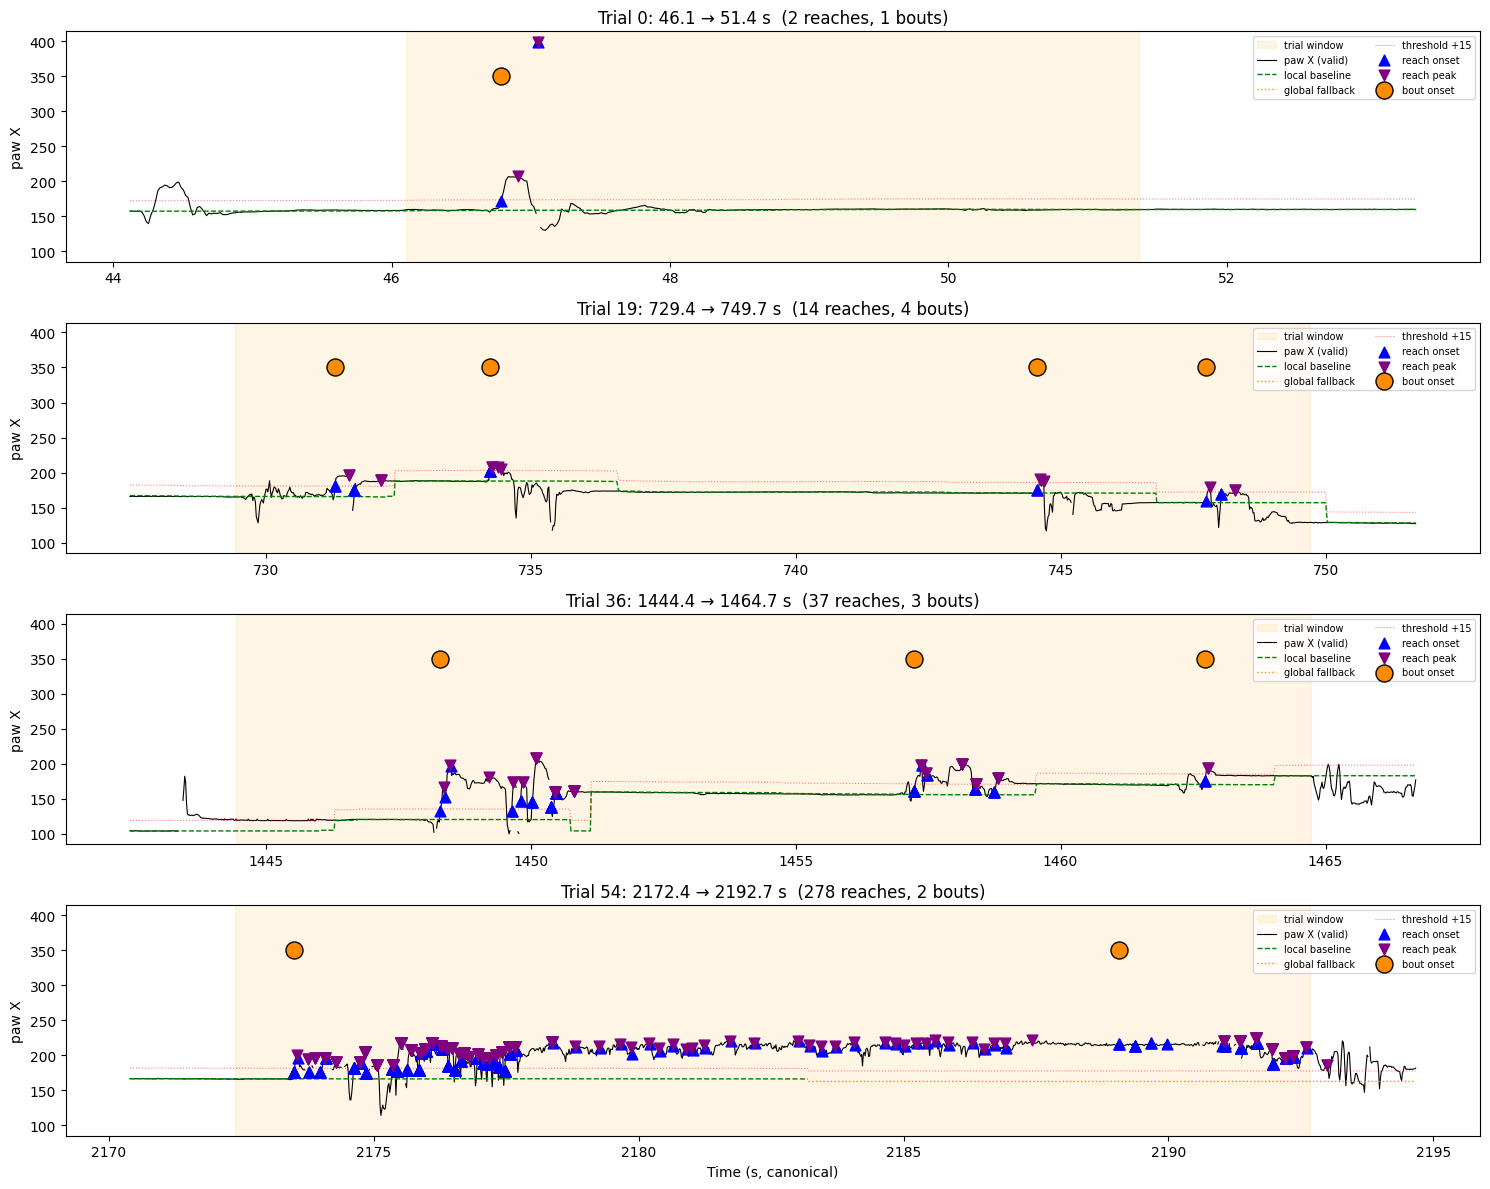

Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\reach_detection_examples_v3_1.png

===== SUMMARY =====
  Likelihood threshold:        ≥ 0.5
  Stability threshold:         ≤ 2.0 px
  Jump filter:                 < 50 px / frame
  Final valid frame %:         98.3%
  Stable frames %:             50.0%
  Local-baseline frames %:     93.6%
  Global-fallback frames %:    6.4%

  Total reaches:               4283
   ...against global baseline: 1011
  Bouts:                       225
  Reaches per trial (mean):    52.33
  Bouts per trial (mean):      1.93
  Trials with ≥1 reach:        53 / 55

  In-trial reaches:            2878
  Out-of-trial reaches:        1405
  Beam-breaking reaches:       520

===== CELL J v3 COMPLETE =====



In [14]:
# ============================================================
# CELL J — REACH DETECTION (PORTABLE) — v3
# ============================================================
# Changes from v2:
#   - Stability threshold raised from 0.7 to 2.0 (tolerates DLC jitter)
#   - BASELINE_MIN_STABLE lowered from 5 to 3 (faster cold-start)
#   - Global-fallback baseline for frames with no nearby stable period
#   - Reaches tagged with whether they used local or global baseline
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL J — REACH DETECTION (v3) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
AMPLITUDE_THRESH    = 15.0      # pixels above local baseline
STABILITY_THRESH    = 2.0       # max within-window range to count as "stable"
STABILITY_WIN_S     = 0.5       # window for stability check
PAW_X_VALID         = (100, 260)
PAW_LIKELIHOOD_MIN  = 0.5
MAX_JUMP_PX         = 50.0

BASELINE_LOOKBACK_S = 3.0
BASELINE_MIN_STABLE = 3
BASELINE_EXTEND_S   = 10.0

MERGE_WINDOW_S      = 0.8
ONSET_FRAC          = 0.10
PEAK_SEARCH_S       = 1.5

PELLET_MOTOR_PIN    = 3
IR_BEAM_PIN         = 6
IR_BEAM_TOLERANCE_S = 0.5
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
dlc = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
frame_t = dlc["canonical_time"]
paw_x   = dlc["paw_x"].astype(float)
paw_y   = dlc["paw_y"].astype(float)
paw_lik = dlc["paw_likelihood"].astype(float)
n_frames = len(frame_t)
fps = 1.0 / float(np.median(np.diff(frame_t)))
print(f"Loaded {n_frames} frames, FPS={fps:.1f}")

ttls_dir = analysis_folder / "ttls"
motor_times = np.load(ttls_dir / f"TTL_Pin_{PELLET_MOTOR_PIN}.npy")
if len(motor_times) % 2 != 0:
    motor_times = motor_times[:-1]
trial_starts = motor_times[0::2]
trial_ends   = motor_times[1::2]
print(f"Trials: {len(trial_starts)}")

beam_times = np.load(ttls_dir / f"TTL_Pin_{IR_BEAM_PIN}.npy")
print(f"IR beam breaks (pin {IR_BEAM_PIN}): {len(beam_times)}")

# ------------------------------------------------------------
# VALIDITY
# ------------------------------------------------------------
in_bounds     = (paw_x >= PAW_X_VALID[0]) & (paw_x <= PAW_X_VALID[1])
likelihood_ok = paw_lik >= PAW_LIKELIHOOD_MIN

print(f"\nValidity layers:")
print(f"  In bounds:               {int(in_bounds.sum()):6d} / {n_frames} "
      f"({100*in_bounds.sum()/n_frames:.1f}%)")
print(f"  Likelihood ≥ {PAW_LIKELIHOOD_MIN}:        "
      f"{int(likelihood_ok.sum()):6d} / {n_frames} "
      f"({100*likelihood_ok.sum()/n_frames:.1f}%)")
print(f"  Jump filter (>{MAX_JUMP_PX:.0f} px from prev good): computing...")

jump_ok = np.ones(n_frames, dtype=bool)
last_good_idx = None
n_jumps = 0
for i in range(n_frames):
    if not (in_bounds[i] and likelihood_ok[i]):
        jump_ok[i] = False
        continue
    if last_good_idx is None:
        last_good_idx = i
        continue
    dx = paw_x[i] - paw_x[last_good_idx]
    dy = paw_y[i] - paw_y[last_good_idx]
    disp = (dx * dx + dy * dy) ** 0.5
    dt = frame_t[i] - frame_t[last_good_idx]
    max_allowed = MAX_JUMP_PX * max(1.0, dt * fps)
    if disp > max_allowed:
        jump_ok[i] = False
        n_jumps += 1
    else:
        last_good_idx = i

print(f"  Frames flagged as jumps: {n_jumps}")

valid = in_bounds & likelihood_ok & jump_ok
print(f"  Final valid:             {int(valid.sum()):6d} / {n_frames} "
      f"({100*valid.sum()/n_frames:.1f}%)")

# ------------------------------------------------------------
# STABILITY DETECTOR
# ------------------------------------------------------------
print(f"\nComputing rolling stability ({STABILITY_WIN_S}s window, "
      f"threshold ≤{STABILITY_THRESH} px)...")
win_frames = max(3, int(round(STABILITY_WIN_S * fps)))
half = win_frames // 2

sentinel = np.inf
x_safe = np.where(valid, paw_x, sentinel)

is_stable = np.zeros(n_frames, dtype=bool)
for i in range(half, n_frames - half):
    window = x_safe[i - half : i + half + 1]
    if np.isinf(window).any():
        continue
    if (window.max() - window.min()) <= STABILITY_THRESH:
        is_stable[i] = True

n_stable = int(is_stable.sum())
print(f"Stable frames: {n_stable} / {n_frames} ({100*n_stable/n_frames:.1f}%)")

# ------------------------------------------------------------
# RUNNING LOCAL BASELINE (with global fallback)
# ------------------------------------------------------------
print(f"\nBuilding running baseline (lookback {BASELINE_LOOKBACK_S}s, "
      f"extending to {BASELINE_EXTEND_S}s if needed)...")

stable_indices = np.where(is_stable)[0]
stable_times = frame_t[stable_indices]
stable_x = paw_x[stable_indices]

# Global fallback = median of all stable frames
if len(stable_x) >= BASELINE_MIN_STABLE:
    global_baseline = float(np.median(stable_x))
    print(f"Global fallback baseline (median of stable frames): "
          f"{global_baseline:.1f} px")
else:
    global_baseline = float(np.median(paw_x[valid]))
    print(f"Not enough stable frames for global fallback. "
          f"Using median of valid frames: {global_baseline:.1f} px")

baseline = np.full(n_frames, np.nan)

for i in range(n_frames):
    t_now = frame_t[i]
    lo = t_now - BASELINE_LOOKBACK_S
    mask = (stable_times >= lo) & (stable_times <= t_now)
    if mask.sum() < BASELINE_MIN_STABLE:
        lo = t_now - BASELINE_EXTEND_S
        mask = (stable_times >= lo) & (stable_times <= t_now)
    if mask.sum() >= BASELINE_MIN_STABLE:
        baseline[i] = np.median(stable_x[mask])

n_with_local = int(np.sum(~np.isnan(baseline)))
print(f"Frames with valid local baseline: {n_with_local} / {n_frames} "
      f"({100*n_with_local/n_frames:.1f}%)")

# Fill NaNs with global fallback (and mark them)
baseline_is_global = np.isnan(baseline)
baseline[baseline_is_global] = global_baseline
n_using_global = int(baseline_is_global.sum())
print(f"Frames using global-fallback baseline: {n_using_global} "
      f"({100*n_using_global/n_frames:.1f}%)")

# ------------------------------------------------------------
# REACH DETECTION
# ------------------------------------------------------------
print("\nDetecting reaches...")

excursion = paw_x - baseline
above_threshold = (excursion > AMPLITUDE_THRESH) & valid

padded = np.concatenate([[False], above_threshold, [False]])
diffs = np.diff(padded.astype(int))
run_starts = np.where(diffs == 1)[0]
run_ends   = np.where(diffs == -1)[0] - 1

print(f"Candidate threshold-crossings: {len(run_starts)}")

reach_onset_t, reach_peak_t = [], []
reach_amp, reach_baseline_at_onset = [], []
reach_frame_onset, reach_frame_peak = [], []

from scipy.signal import find_peaks

reach_onset_t, reach_peak_t = [], []
reach_amp, reach_baseline_at_onset = [], []
reach_frame_onset, reach_frame_peak = [], []

# Minimum prominence for a peak to count as a separate reach (in pixels above
# the surrounding minima). Higher → fewer detected sub-peaks within a run.
MIN_PEAK_PROMINENCE_PX = 8.0
# Minimum separation between adjacent peaks (in frames)
MIN_PEAK_SEPARATION_S  = 0.10
min_peak_sep_frames = max(1, int(round(MIN_PEAK_SEPARATION_S * fps)))

for r_start, r_end in zip(run_starts, run_ends):
    extend_frames = int(round(PEAK_SEARCH_S * fps))
    search_end = min(n_frames - 1, max(r_end, r_start + extend_frames))
    seg = excursion[r_start:search_end + 1]
    seg_clean = np.where(np.isnan(seg), -np.inf, seg)
    if seg_clean.size == 0:
        continue

    # Find ALL prominent peaks within this run
    peak_offsets, props = find_peaks(seg_clean,
                                      prominence=MIN_PEAK_PROMINENCE_PX,
                                      distance=min_peak_sep_frames)
    # Always include the global argmax even if it didn't pass prominence
    # (handles small isolated reaches with no flanking dips)
    global_argmax = int(np.argmax(seg_clean))
    if global_argmax not in peak_offsets:
        peak_offsets = np.append(peak_offsets, global_argmax)
        peak_offsets.sort()

    for peak_offset in peak_offsets:
        peak_idx = r_start + int(peak_offset)
        peak_amp_val = excursion[peak_idx]
        if not np.isfinite(peak_amp_val) or peak_amp_val < AMPLITUDE_THRESH:
            continue

        # Walk back to onset, but stop at the previous detected peak
        # within this run if there is one (don't walk through it)
        prev_peaks_in_run = [r_start + int(p) for p in peak_offsets
                              if p < peak_offset]
        walk_floor = max(0, peak_idx - int(2.0 * fps))
        if prev_peaks_in_run:
            walk_floor = max(walk_floor, prev_peaks_in_run[-1] + 1)

        onset_thresh = ONSET_FRAC * peak_amp_val
        onset_idx = peak_idx
        for j in range(peak_idx, walk_floor - 1, -1):
            if np.isnan(excursion[j]) or excursion[j] < onset_thresh:
                onset_idx = j + 1
                break
            onset_idx = j

        reach_onset_t.append(float(frame_t[onset_idx]))
        reach_peak_t.append(float(frame_t[peak_idx]))
        reach_amp.append(float(peak_amp_val))
        reach_baseline_at_onset.append(float(baseline[onset_idx]))
        reach_frame_onset.append(int(onset_idx))
        reach_frame_peak.append(int(peak_idx))

reach_onset_t = np.array(reach_onset_t)
reach_peak_t  = np.array(reach_peak_t)
reach_amp     = np.array(reach_amp)
reach_baseline_at_onset = np.array(reach_baseline_at_onset)
reach_frame_onset = np.array(reach_frame_onset)
reach_frame_peak  = np.array(reach_frame_peak)

print(f"Detected reaches: {len(reach_onset_t)}")

# ------------------------------------------------------------
# BOUT CLUSTERING
# ------------------------------------------------------------
print(f"\nClustering into bouts (merge window {MERGE_WINDOW_S}s)...")

if len(reach_onset_t) > 0:
    bout_id = np.zeros(len(reach_onset_t), dtype=int)
    for i in range(1, len(reach_onset_t)):
        if reach_onset_t[i] - reach_peak_t[i - 1] <= MERGE_WINDOW_S:
            bout_id[i] = bout_id[i - 1]
        else:
            bout_id[i] = bout_id[i - 1] + 1
    n_bouts = int(bout_id.max()) + 1
else:
    bout_id = np.array([], dtype=int)
    n_bouts = 0

print(f"Reaches grouped into {n_bouts} bouts")

# ------------------------------------------------------------
# TRIAL TAGGING
# ------------------------------------------------------------
reach_trial_id = np.full(len(reach_onset_t), -1, dtype=int)
for t_i, (ts, te) in enumerate(zip(trial_starts, trial_ends)):
    in_trial = (reach_onset_t >= ts) & (reach_onset_t <= te)
    reach_trial_id[in_trial] = t_i

# ------------------------------------------------------------
# BEAM TAGGING
# ------------------------------------------------------------
reach_broke_beam = np.zeros(len(reach_peak_t), dtype=bool)
for i, t_peak in enumerate(reach_peak_t):
    if len(beam_times) and np.any(np.abs(beam_times - t_peak) < IR_BEAM_TOLERANCE_S):
        reach_broke_beam[i] = True

# ------------------------------------------------------------
# FLAG REACHES DETECTED AGAINST GLOBAL-FALLBACK BASELINE
# ------------------------------------------------------------
if len(reach_frame_onset) > 0:
    reach_baseline_was_global = baseline_is_global[reach_frame_onset]
else:
    reach_baseline_was_global = np.array([], dtype=bool)
n_global_baseline_reaches = int(reach_baseline_was_global.sum())
print(f"Reaches against global-fallback baseline: "
      f"{n_global_baseline_reaches} / {len(reach_onset_t)} "
      f"(check these manually if many)")

# ------------------------------------------------------------
# BOUT-LEVEL SUMMARY
# ------------------------------------------------------------
bout_onset_t    = np.zeros(n_bouts)
bout_peak_t     = np.zeros(n_bouts)
bout_max_amp    = np.zeros(n_bouts)
bout_n_reaches  = np.zeros(n_bouts, dtype=int)
bout_trial_id   = np.full(n_bouts, -1, dtype=int)
bout_broke_beam = np.zeros(n_bouts, dtype=bool)
bout_used_global_baseline = np.zeros(n_bouts, dtype=bool)

for b in range(n_bouts):
    mask = bout_id == b
    bout_onset_t[b]   = reach_onset_t[mask].min()
    bout_max_amp[b]   = reach_amp[mask].max()
    bout_peak_t[b]    = reach_peak_t[mask][np.argmax(reach_amp[mask])]
    bout_n_reaches[b] = int(mask.sum())
    bout_trial_id[b]  = reach_trial_id[mask][0]
    bout_broke_beam[b] = bool(reach_broke_beam[mask].any())
    bout_used_global_baseline[b] = bool(reach_baseline_was_global[mask].any())

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
reaches_dir = analysis_folder / "peak_detection"
reaches_dir.mkdir(exist_ok=True)

np.savez(reaches_dir / "reaches.npz",
         onset_t=reach_onset_t,
         peak_t=reach_peak_t,
         amplitude=reach_amp,
         baseline_at_onset=reach_baseline_at_onset,
         frame_onset=reach_frame_onset,
         frame_peak=reach_frame_peak,
         bout_id=bout_id,
         trial_id=reach_trial_id,
         broke_beam=reach_broke_beam,
         baseline_was_global=reach_baseline_was_global)

np.savez(reaches_dir / "bouts.npz",
         onset_t=bout_onset_t,
         peak_t=bout_peak_t,
         max_amplitude=bout_max_amp,
         n_reaches=bout_n_reaches,
         trial_id=bout_trial_id,
         broke_beam=bout_broke_beam,
         used_global_baseline=bout_used_global_baseline)

np.save(reaches_dir / "running_baseline.npy", baseline)
np.save(reaches_dir / "baseline_is_global.npy", baseline_is_global)
np.save(reaches_dir / "frame_valid.npy", valid)

meta = {
    "n_reaches":                int(len(reach_onset_t)),
    "n_bouts":                  int(n_bouts),
    "n_in_trial":               int((reach_trial_id >= 0).sum()),
    "n_out_of_trial":           int((reach_trial_id == -1).sum()),
    "n_beam_breaking":          int(reach_broke_beam.sum()),
    "n_global_baseline":        int(n_global_baseline_reaches),
    "n_bouts_in_trial":         int((bout_trial_id >= 0).sum()),
    "n_bouts_out_of_trial":     int((bout_trial_id == -1).sum()),
    "n_bouts_beam_breaking":    int(bout_broke_beam.sum()),
    "trial_count":              int(len(trial_starts)),
    "trials_with_reaches":      int(len(np.unique(reach_trial_id[reach_trial_id >= 0]))),
    "params": {
        "amplitude_thresh_px":   float(AMPLITUDE_THRESH),
        "stability_thresh_px":   float(STABILITY_THRESH),
        "stability_win_s":       float(STABILITY_WIN_S),
        "paw_x_valid":           list(PAW_X_VALID),
        "paw_likelihood_min":    float(PAW_LIKELIHOOD_MIN),
        "max_jump_px":           float(MAX_JUMP_PX),
        "baseline_lookback_s":   float(BASELINE_LOOKBACK_S),
        "baseline_extend_s":     float(BASELINE_EXTEND_S),
        "baseline_min_stable":   int(BASELINE_MIN_STABLE),
        "merge_window_s":        float(MERGE_WINDOW_S),
        "onset_frac":            float(ONSET_FRAC),
        "peak_search_s":         float(PEAK_SEARCH_S),
        "ir_beam_tolerance_s":   float(IR_BEAM_TOLERANCE_S),
    }
}
with open(reaches_dir / "reaches_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"\nSaved reaches → {reaches_dir / 'reaches.npz'}")
print(f"Saved bouts   → {reaches_dir / 'bouts.npz'}")

# ------------------------------------------------------------
# DIAGNOSTIC PLOTS
# ------------------------------------------------------------
print("\nPlotting diagnostics...")

trials_with_reaches = np.unique(reach_trial_id[reach_trial_id >= 0])
if len(trials_with_reaches) > 0:
    plot_trial_idx = trials_with_reaches[
        np.linspace(0, len(trials_with_reaches) - 1,
                    min(4, len(trials_with_reaches))).astype(int)
    ]
else:
    plot_trial_idx = np.arange(min(4, len(trial_starts)))

fig, axes = plt.subplots(len(plot_trial_idx), 1,
                         figsize=(15, 3 * len(plot_trial_idx)),
                         sharey=True)
if len(plot_trial_idx) == 1:
    axes = [axes]

paw_x_masked = paw_x.copy()
paw_x_masked[~valid] = np.nan

for ax, t_i in zip(axes, plot_trial_idx):
    ts, te = trial_starts[t_i], trial_ends[t_i]
    pad = 2.0
    mask = (frame_t >= ts - pad) & (frame_t <= te + pad)

    ax.axvspan(ts, te, alpha=0.10, color="orange", label="trial window")
    ax.plot(frame_t[mask], paw_x_masked[mask], lw=0.8, color="black",
            label="paw X (valid)")
    # baseline: solid where local, dotted where global
    bl = baseline[mask].copy()
    bg = baseline_is_global[mask]
    bl_local = bl.copy();  bl_local[bg]  = np.nan
    bl_global = bl.copy(); bl_global[~bg] = np.nan
    ax.plot(frame_t[mask], bl_local, lw=1.0, color="green",
            linestyle="--", label="local baseline")
    ax.plot(frame_t[mask], bl_global, lw=1.0, color="darkorange",
            linestyle=":", label="global fallback")
    ax.plot(frame_t[mask], baseline[mask] + AMPLITUDE_THRESH, lw=0.8,
            color="red", linestyle=":", alpha=0.5,
            label=f"threshold +{AMPLITUDE_THRESH:.0f}")

    in_this = reach_trial_id == t_i
    if in_this.any():
        ax.scatter(reach_onset_t[in_this],
                   paw_x[reach_frame_onset[in_this]],
                   marker="^", color="blue", s=60, zorder=10, label="reach onset")
        ax.scatter(reach_peak_t[in_this],
                   paw_x[reach_frame_peak[in_this]],
                   marker="v", color="purple", s=60, zorder=10, label="reach peak")

    bouts_in_trial = np.where(bout_trial_id == t_i)[0]
    if len(bouts_in_trial):
        ax.scatter(bout_onset_t[bouts_in_trial],
                   np.full(len(bouts_in_trial), 350),
                   marker="o", color="darkorange", s=150, zorder=11,
                   edgecolor="black", label="bout onset")

    beam_in_window = beam_times[(beam_times >= ts - pad) & (beam_times <= te + pad)]
    for bt in beam_in_window:
        ax.axvline(bt, color="red", alpha=0.3, lw=0.8)

    n_b = len(bouts_in_trial)
    n_r = int(in_this.sum())
    ax.set_title(f"Trial {t_i}: {ts:.1f} → {te:.1f} s  "
                 f"({n_r} reaches, {n_b} bouts)")
    ax.set_ylabel("paw X")
    ax.legend(fontsize=7, loc="upper right", ncol=2)

axes[-1].set_xlabel("Time (s, canonical)")
plt.tight_layout()
out_path = analysis_folder / "qc" / "reach_detection_examples_v3.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"reach_detection_examples_v3_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"Saved → {out_path}")

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
print("\n===== SUMMARY =====")
print(f"  Likelihood threshold:        ≥ {PAW_LIKELIHOOD_MIN}")
print(f"  Stability threshold:         ≤ {STABILITY_THRESH} px")
print(f"  Jump filter:                 < {MAX_JUMP_PX:.0f} px / frame")
print(f"  Final valid frame %:         {100*valid.sum()/n_frames:.1f}%")
print(f"  Stable frames %:             {100*n_stable/n_frames:.1f}%")
print(f"  Local-baseline frames %:     {100*n_with_local/n_frames:.1f}%")
print(f"  Global-fallback frames %:    {100*n_using_global/n_frames:.1f}%")
print(f"")
print(f"  Total reaches:               {len(reach_onset_t)}")
print(f"   ...against global baseline: {n_global_baseline_reaches}")
print(f"  Bouts:                       {n_bouts}")
print(f"  Reaches per trial (mean):    {(reach_trial_id >= 0).sum() / max(len(trial_starts), 1):.2f}")
print(f"  Bouts per trial (mean):      {(bout_trial_id >= 0).sum() / max(len(trial_starts), 1):.2f}")
print(f"  Trials with ≥1 reach:        {len(trials_with_reaches)} / {len(trial_starts)}")
print(f"")
print(f"  In-trial reaches:            {(reach_trial_id >= 0).sum()}")
print(f"  Out-of-trial reaches:        {(reach_trial_id == -1).sum()}")
print(f"  Beam-breaking reaches:       {reach_broke_beam.sum()}")

print("\n===== CELL J v3 COMPLETE =====\n")


===== CELL K — REACH-ALIGNED KINEMATIC AVERAGE =====
Loaded 225 bouts

Subset sizes:
  all                 : 225
  in_trial            : 106
  out_of_trial        : 119
  beam_breaking       : 4
  in_trial_first      : 52

Building aligned traces (2.0s pre to 5.0s post, resampled to 60.0 fps)...

Usable traces per subset:
  all                 : 221 / 225
  in_trial            : 105 / 106
  out_of_trial        : 116 / 119
  beam_breaking       : 4 / 4
  in_trial_first      : 51 / 52

Plotting...


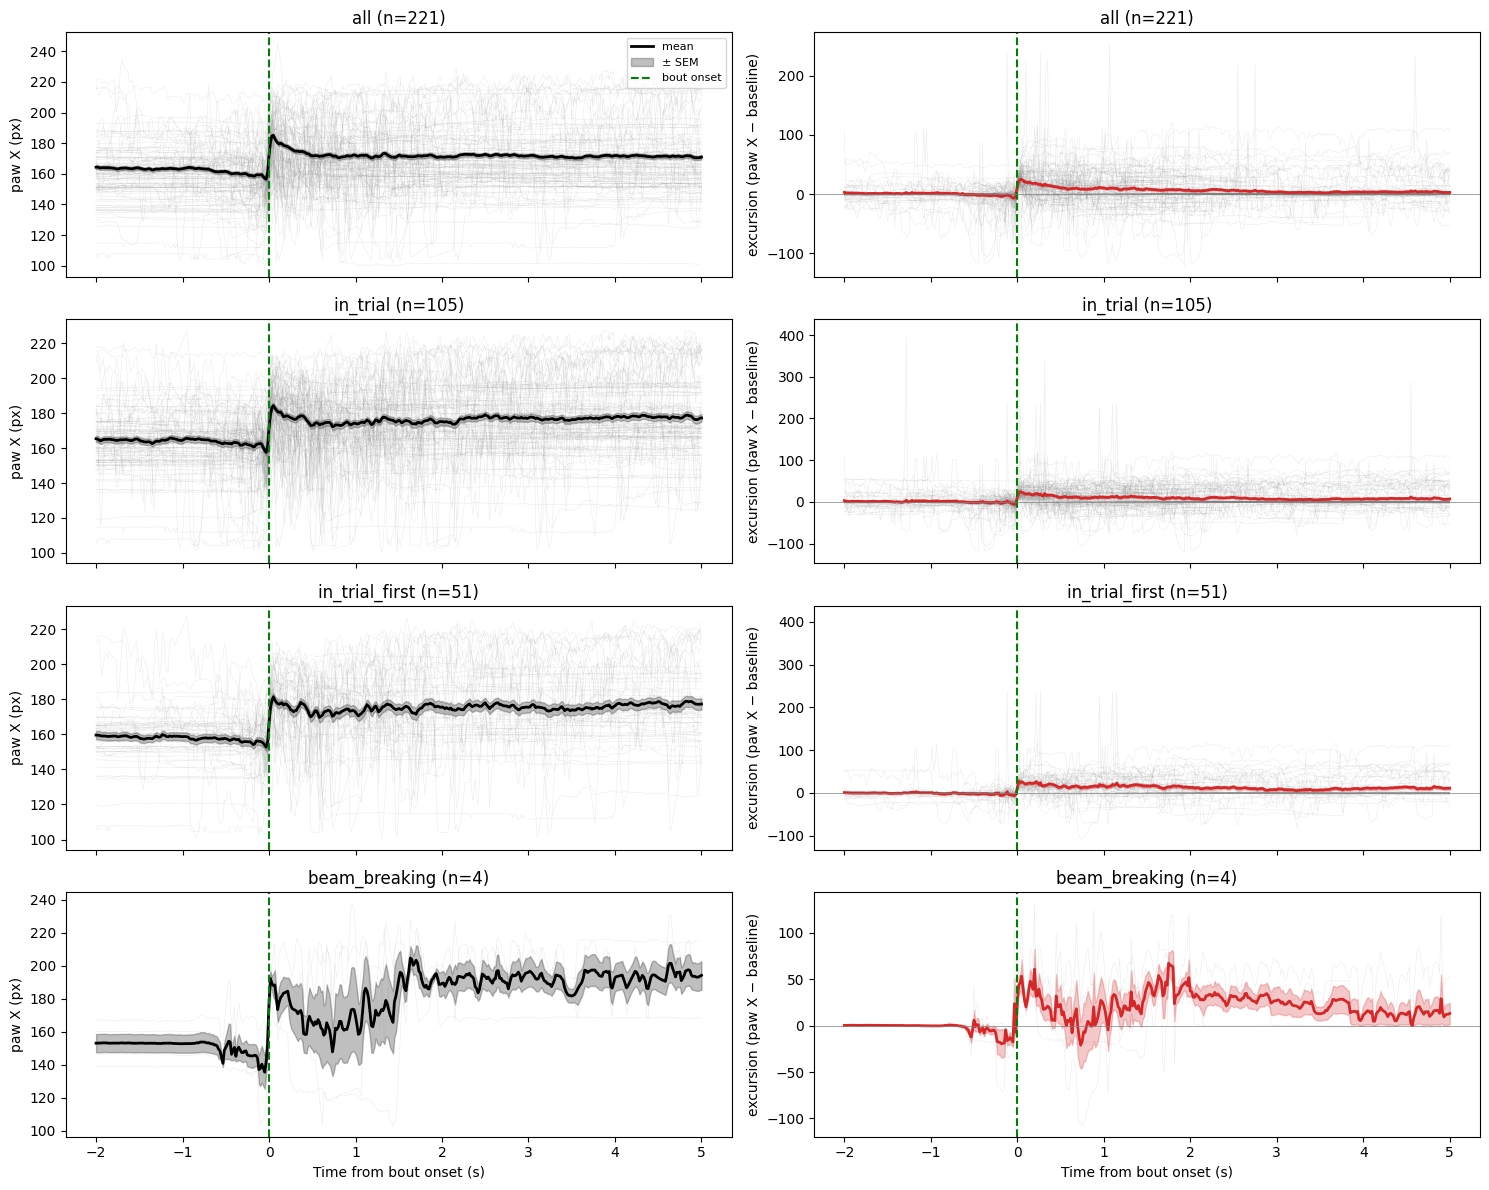

Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\kinematic_average.png
Saved kinematic traces → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\peak_detection\kinematic_traces.npz

===== CELL K COMPLETE =====



In [15]:
# ============================================================
# CELL K — REACH-ALIGNED KINEMATIC AVERAGE (PORTABLE)
# ============================================================
# For each subset of bouts, plot the average paw kinematic trace
# around bout onset (mean ± SEM, with overlay of all individual
# traces in faint gray). This is the diagnostic that tells us if
# bouts are stereotyped enough for clean neural alignment.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL K — REACH-ALIGNED KINEMATIC AVERAGE =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
WIN_PRE         = 2.0          # seconds before bout onset
WIN_POST        = 5.0          # seconds after
RESAMPLE_FPS    = 60.0         # interpolate to this grid (matches video)
MAX_TRACE_GAP_S = 0.5          # tolerate gaps up to this; longer → drop trace
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
dlc = np.load(analysis_folder / "dlc_alignment" / "full_session_dlc.npz")
frame_t = dlc["canonical_time"]
paw_x   = dlc["paw_x"].astype(float)
paw_y   = dlc["paw_y"].astype(float)

valid = np.load(analysis_folder / "peak_detection" / "frame_valid.npy")
baseline = np.load(analysis_folder / "peak_detection" / "running_baseline.npy")

bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
bout_onset_t   = bouts["onset_t"]
bout_trial_id  = bouts["trial_id"]
bout_broke_beam = bouts["broke_beam"]

print(f"Loaded {len(bout_onset_t)} bouts")

# Subset definitions
subsets = {
    "all":             np.ones(len(bout_onset_t), dtype=bool),
    "in_trial":        bout_trial_id >= 0,
    "out_of_trial":    bout_trial_id == -1,
    "beam_breaking":   bout_broke_beam,
    "in_trial_first":  np.zeros(len(bout_onset_t), dtype=bool),  # filled below
}

# "first bout per trial" — earliest bout for each trial
for t_i in np.unique(bout_trial_id):
    if t_i == -1:
        continue
    in_trial_idx = np.where(bout_trial_id == t_i)[0]
    first = in_trial_idx[np.argmin(bout_onset_t[in_trial_idx])]
    subsets["in_trial_first"][first] = True

print("\nSubset sizes:")
for name, mask in subsets.items():
    print(f"  {name:<20s}: {int(mask.sum())}")

# ------------------------------------------------------------
# BUILD ALIGNED KINEMATIC TRACES
# ------------------------------------------------------------
print(f"\nBuilding aligned traces ({WIN_PRE}s pre to {WIN_POST}s post, "
      f"resampled to {RESAMPLE_FPS} fps)...")

regular_t = np.arange(-WIN_PRE, WIN_POST + 1.0/RESAMPLE_FPS, 1.0/RESAMPLE_FPS)
n_t = len(regular_t)

paw_x_masked = np.where(valid, paw_x, np.nan)
paw_y_masked = np.where(valid, paw_y, np.nan)
excursion = paw_x - baseline

def aligned_trace(t_event, signal):
    t0, t1 = t_event - WIN_PRE, t_event + WIN_POST
    mask = (frame_t >= t0 - 0.1) & (frame_t <= t1 + 0.1)
    if mask.sum() < 5:
        return None
    rel_t = frame_t[mask] - t_event
    sig = signal[mask]
    if np.isfinite(sig).sum() < 0.5 * len(sig):
        return None
    finite_mask = np.isfinite(sig)
    if finite_mask.sum() < 5:
        return None
    finite_t = rel_t[finite_mask]
    finite_v = sig[finite_mask]
    gaps = np.diff(finite_t)
    if gaps.size and gaps.max() > MAX_TRACE_GAP_S:
        return None
    interp = np.full(n_t, np.nan)
    in_range = (regular_t >= finite_t[0]) & (regular_t <= finite_t[-1])
    interp[in_range] = np.interp(regular_t[in_range], finite_t, finite_v)
    return interp

trace_matrices_x   = {}
trace_matrices_y   = {}
trace_matrices_exc = {}
n_kept = {}

for name, mask in subsets.items():
    onsets = bout_onset_t[mask]
    x_rows, y_rows, exc_rows = [], [], []
    for t_evt in onsets:
        tx = aligned_trace(t_evt, paw_x_masked)
        ty = aligned_trace(t_evt, paw_y_masked)
        te = aligned_trace(t_evt, excursion)
        if tx is None or ty is None or te is None:
            continue
        x_rows.append(tx)
        y_rows.append(ty)
        exc_rows.append(te)
    if x_rows:
        trace_matrices_x[name]   = np.stack(x_rows)
        trace_matrices_y[name]   = np.stack(y_rows)
        trace_matrices_exc[name] = np.stack(exc_rows)
    else:
        trace_matrices_x[name]   = np.zeros((0, n_t))
        trace_matrices_y[name]   = np.zeros((0, n_t))
        trace_matrices_exc[name] = np.zeros((0, n_t))
    n_kept[name] = len(x_rows)

print("\nUsable traces per subset:")
for name in subsets:
    print(f"  {name:<20s}: {n_kept[name]} / {int(subsets[name].sum())}")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
print("\nPlotting...")

plot_subsets = ["all", "in_trial", "in_trial_first", "beam_breaking"]
fig, axes = plt.subplots(len(plot_subsets), 2, figsize=(15, 3 * len(plot_subsets)),
                         sharex=True)
if len(plot_subsets) == 1:
    axes = axes[np.newaxis, :]

for row, name in enumerate(plot_subsets):
    mat_x = trace_matrices_x[name]
    mat_e = trace_matrices_exc[name]
    n = mat_x.shape[0]

    # Paw X panel
    ax = axes[row, 0]
    if n > 0:
        for i in range(min(n, 100)):
            ax.plot(regular_t, mat_x[i], color="gray", alpha=0.15, lw=0.4)
        mean_x = np.nanmean(mat_x, axis=0)
        sem_x  = np.nanstd(mat_x, axis=0) / np.sqrt(np.sum(~np.isnan(mat_x), axis=0).clip(min=1))
        ax.plot(regular_t, mean_x, color="black", lw=2.0, label="mean")
        ax.fill_between(regular_t, mean_x - sem_x, mean_x + sem_x,
                        color="black", alpha=0.25, label="± SEM")
    ax.axvline(0, color="green", lw=1.5, linestyle="--", label="bout onset")
    ax.set_ylabel("paw X (px)")
    ax.set_title(f"{name} (n={n})")
    if row == 0:
        ax.legend(fontsize=8, loc="upper right")

    # Excursion panel
    ax = axes[row, 1]
    if n > 0:
        for i in range(min(n, 100)):
            ax.plot(regular_t, mat_e[i], color="gray", alpha=0.15, lw=0.4)
        mean_e = np.nanmean(mat_e, axis=0)
        sem_e  = np.nanstd(mat_e, axis=0) / np.sqrt(np.sum(~np.isnan(mat_e), axis=0).clip(min=1))
        ax.plot(regular_t, mean_e, color="C3", lw=2.0)
        ax.fill_between(regular_t, mean_e - sem_e, mean_e + sem_e,
                        color="C3", alpha=0.25)
    ax.axvline(0, color="green", lw=1.5, linestyle="--")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_ylabel("excursion (paw X − baseline)")
    ax.set_title(f"{name} (n={n})")

axes[-1, 0].set_xlabel("Time from bout onset (s)")
axes[-1, 1].set_xlabel("Time from bout onset (s)")

plt.tight_layout()

out_path = analysis_folder / "qc" / "kinematic_average.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"kinematic_average_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"Saved → {out_path}")

# ------------------------------------------------------------
# SAVE the trace matrices for downstream use
# ------------------------------------------------------------
out_npz = analysis_folder / "peak_detection" / "kinematic_traces.npz"
save_dict = {"time_s": regular_t}
for name in plot_subsets:
    save_dict[f"{name}_x"]   = trace_matrices_x[name]
    save_dict[f"{name}_y"]   = trace_matrices_y[name]
    save_dict[f"{name}_exc"] = trace_matrices_exc[name]
np.savez(out_npz, **save_dict)
print(f"Saved kinematic traces → {out_npz}")

print("\n===== CELL K COMPLETE =====\n")


===== CELL L — REACH-LOCKED MODULATION (v2) =====
Aligning to bout subset: in_trial_first
  N events: 52
  Time range: 46.79 → 2173.50 s

Units with ≥1.0 Hz baseline: 38 / 40

Building shuffled-events null distribution (200 shuffles, each averaging 52 random events)...
  25/200 shuffles done.
  50/200 shuffles done.
  75/200 shuffles done.
  100/200 shuffles done.
  125/200 shuffles done.
  150/200 shuffles done.
  175/200 shuffles done.
  200/200 shuffles done.

Null-distribution rate stats (averaged across bins):
  median null_mean: 10.03 Hz
  median null_std:  2.12 Hz

Calibrating Z threshold using matched null...

Shuffled FPR by Z threshold (proper null):
  Z>2.00:  31.3%
  Z>2.25:  17.7%
  Z>2.50:  9.8%
  Z>2.75:  5.0%  ← target
  Z>3.00:  2.5%
  Z>3.25:  1.3%
  Z>3.50:  0.7%
  Z>3.75:  0.4%
  Z>4.00:  0.1%
  Z>4.25:  0.0%
  Z>4.50:  0.0%
  Z>4.75:  0.0%
  Z>5.00:  0.0%
  Z>5.25:  0.0%
  Z>5.50:  0.0%
  Z>5.75:  0.0%
  Z>6.00:  0.0%

Calibrated Z threshold: 2.75  (shuffled FPR =

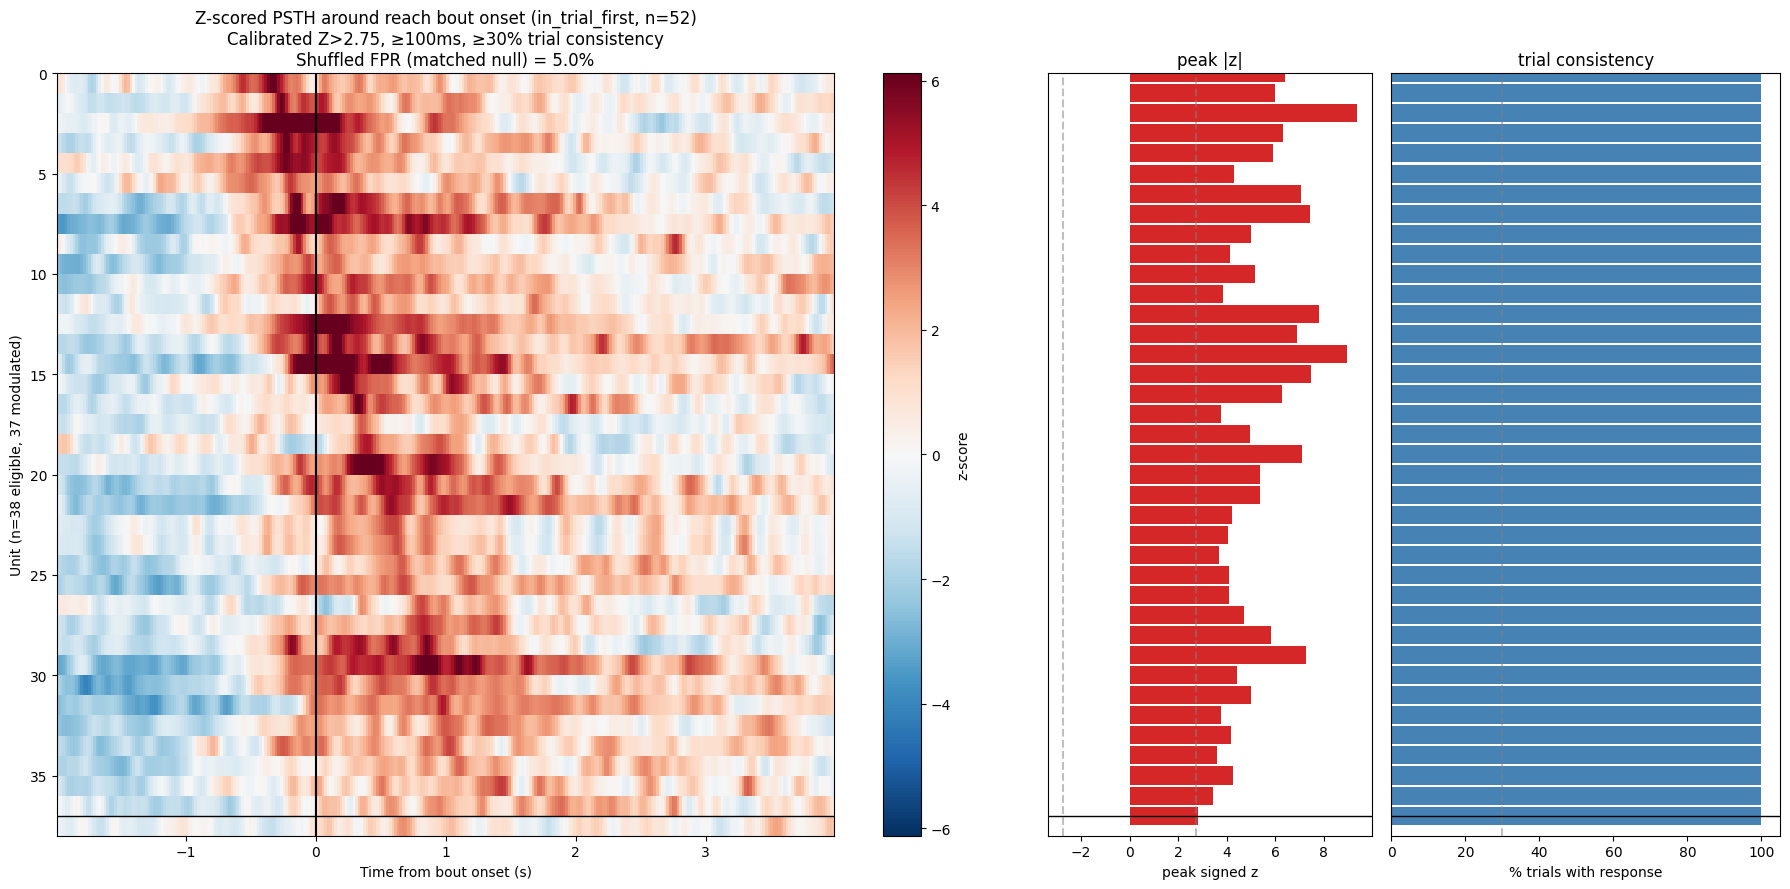


Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\modulation_reach_in_trial_first_v2.png

===== INTERPRETATION =====
  Subset:                       in_trial_first
  N reach bout events:          52
  Eligible units:               38
  Calibrated Z threshold:       2.75
  Shuffled FPR at threshold:    5.0%
  Modulated units (real):       37
  Expected by chance:           1.9 units
  Excess over chance:           35.1 units

These 37 units are reliably reach-modulated.

===== CELL L v2 COMPLETE =====



In [16]:
# ============================================================
# CELL L — REACH-LOCKED MODULATION ANALYSIS (PORTABLE) — v2
# ============================================================
# Fixed null: shuffled events are now drawn with the SAME structure
# as real events (n_events random times, trial-averaged), so the
# null distribution matches the analysis pipeline.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL L — REACH-LOCKED MODULATION (v2) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SUBSET_NAME        = "in_trial_first"
WIN_PRE            = 2.0
WIN_POST           = 4.0
RESPONSE_WIN       = (-0.5, 2.0)
BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
MIN_CONSECUTIVE_MS = 100
MIN_BASELINE_HZ    = 1.0
CONSISTENCY_FRAC   = 0.30
N_SHUFFLES_CALIB   = 200
TARGET_FPR         = 0.05
RANDOM_SEED        = 42
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD BOUT EVENT TIMES
# ------------------------------------------------------------
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
bout_onset_t   = bouts["onset_t"]
bout_trial_id  = bouts["trial_id"]
bout_broke_beam = bouts["broke_beam"]

if SUBSET_NAME == "all":
    mask = np.ones(len(bout_onset_t), dtype=bool)
elif SUBSET_NAME == "in_trial":
    mask = bout_trial_id >= 0
elif SUBSET_NAME == "out_of_trial":
    mask = bout_trial_id == -1
elif SUBSET_NAME == "beam_breaking":
    mask = bout_broke_beam
elif SUBSET_NAME == "in_trial_first":
    mask = np.zeros(len(bout_onset_t), dtype=bool)
    for t_i in np.unique(bout_trial_id):
        if t_i == -1:
            continue
        in_trial_idx = np.where(bout_trial_id == t_i)[0]
        first = in_trial_idx[np.argmin(bout_onset_t[in_trial_idx])]
        mask[first] = True
else:
    raise ValueError(f"Unknown SUBSET_NAME: {SUBSET_NAME}")

event_times = np.sort(bout_onset_t[mask])
n_events = len(event_times)
print(f"Aligning to bout subset: {SUBSET_NAME}")
print(f"  N events: {n_events}")
print(f"  Time range: {event_times[0]:.2f} → {event_times[-1]:.2f} s")

if n_events < 10:
    raise RuntimeError(f"Too few events ({n_events}) for meaningful analysis.")

# ------------------------------------------------------------
# LOAD UNITS + FILTER BY MIN BASELINE RATE
# ------------------------------------------------------------
good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"
all_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}

unit_rates = np.array([len(all_spikes[int(u)]) / recording_duration
                       for u in good_units])
eligible = unit_rates >= MIN_BASELINE_HZ
eligible_units = good_units[eligible]
print(f"\nUnits with ≥{MIN_BASELINE_HZ} Hz baseline: "
      f"{len(eligible_units)} / {len(good_units)}")

# ------------------------------------------------------------
# COMPUTATION HELPERS
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# CORE: trial-averaged smoothed PSTHs (and per-trial array)
# ------------------------------------------------------------
def compute_psth(events):
    """Returns (psth_smooth_per_trial, psth_smooth_mean)."""
    psth_per_trial = np.zeros((len(eligible_units), len(events), n_bins))
    for u_i, u in enumerate(eligible_units):
        spk = all_spikes[int(u)]
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            psth_per_trial[u_i, e_i] = h / BIN_SIZE
    psth_smooth_per_trial = gaussian_filter1d(psth_per_trial,
                                              sigma=SMOOTH_SIGMA_BINS, axis=2)
    psth_smooth_mean = psth_smooth_per_trial.mean(axis=1)
    return psth_smooth_per_trial, psth_smooth_mean

def count_modulated(z_mat, z_thresh):
    z_resp = z_mat[:, response_mask]
    out = np.zeros(z_resp.shape[0], dtype=bool)
    for i in range(z_resp.shape[0]):
        for arr in (z_resp[i] > z_thresh, z_resp[i] < -z_thresh):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            diffs = np.diff(padded.astype(int))
            starts = np.where(diffs ==  1)[0]
            ends   = np.where(diffs == -1)[0]
            if (ends - starts).max() >= min_consec_bins:
                out[i] = True
                break
    return out

# ------------------------------------------------------------
# BUILD NULL DISTRIBUTION (PROPERLY): for each shuffle, draw
# n_events random times, compute their trial-averaged PSTH,
# then we'll z-score it against itself.
# ------------------------------------------------------------
print(f"\nBuilding shuffled-events null distribution "
      f"({N_SHUFFLES_CALIB} shuffles, each averaging {n_events} random events)...")

t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0

# For each unit, collect the shuffled trial-averaged PSTHs.
# We use ALL the shuffles to estimate (mean, std) per bin per unit.
# This gives us a per-unit, per-bin "expected variability under chance",
# which is what we then z-score against.

shuffled_psths = np.zeros((N_SHUFFLES_CALIB, len(eligible_units), n_bins))

for s in range(N_SHUFFLES_CALIB):
    fake_events = rng.uniform(t_min, t_max, size=n_events)
    fake_events.sort()
    _, fake_mean = compute_psth(fake_events)
    shuffled_psths[s] = fake_mean
    if (s + 1) % 25 == 0:
        print(f"  {s+1}/{N_SHUFFLES_CALIB} shuffles done.")

# Per-unit, per-bin null statistics
null_mean = shuffled_psths.mean(axis=0)   # (n_units, n_bins)
null_std  = shuffled_psths.std(axis=0)
null_std  = np.maximum(null_std, null_mean * 0.01 + 0.1)   # floor

print(f"\nNull-distribution rate stats (averaged across bins):")
print(f"  median null_mean: {np.median(null_mean):.2f} Hz")
print(f"  median null_std:  {np.median(null_std):.2f} Hz")

# ------------------------------------------------------------
# CALIBRATE Z THRESHOLD: how often do shuffled events exceed each
# threshold WHEN Z-SCORED AGAINST THE NULL?
# ------------------------------------------------------------
print("\nCalibrating Z threshold using matched null...")

# Z-score each shuffle against the null. Count modulated units per shuffle.
z_thresh_grid = np.arange(2.0, 6.01, 0.25)
shuffled_fpr = np.zeros((N_SHUFFLES_CALIB, len(z_thresh_grid)))

for s in range(N_SHUFFLES_CALIB):
    # Leave-one-out z-scoring would be most rigorous, but
    # for speed we use the full null mean/std and accept tiny
    # under-estimate of variance (we have 200 shuffles)
    z_s = (shuffled_psths[s] - null_mean) / null_std
    for j, thr in enumerate(z_thresh_grid):
        shuffled_fpr[s, j] = count_modulated(z_s, thr).sum() / len(eligible_units)

mean_fpr = shuffled_fpr.mean(axis=0)
print("\nShuffled FPR by Z threshold (proper null):")
for thr, fpr in zip(z_thresh_grid, mean_fpr):
    marker = "  ← target" if (fpr <= TARGET_FPR
                              and (j == 0 or mean_fpr[max(0, np.where(z_thresh_grid==thr)[0][0]-1)] > TARGET_FPR)) else ""
    print(f"  Z>{thr:.2f}:  {fpr*100:.1f}%{marker}")

viable = np.where(mean_fpr <= TARGET_FPR)[0]
if len(viable) == 0:
    z_thresh_chosen = float(z_thresh_grid[-1])
    print(f"\nWARNING: no threshold reaches ≤{TARGET_FPR*100:.0f}% FPR. "
          f"Using Z={z_thresh_chosen}.")
else:
    z_thresh_chosen = float(z_thresh_grid[viable[0]])

calibrated_fpr = mean_fpr[np.argmin(np.abs(z_thresh_grid - z_thresh_chosen))]
print(f"\nCalibrated Z threshold: {z_thresh_chosen:.2f}  "
      f"(shuffled FPR = {calibrated_fpr*100:.1f}%)")

# ------------------------------------------------------------
# APPLY TO REAL EVENTS (z-score against the SAME null)
# ------------------------------------------------------------
print(f"\nComputing real {SUBSET_NAME} PSTHs and z-scoring against null...")
real_per_trial, real_mean = compute_psth(event_times)
real_z = (real_mean - null_mean) / null_std

modulated_initial = count_modulated(real_z, z_thresh_chosen)
n_initial = int(modulated_initial.sum())
print(f"  Units passing Z criterion (trial-averaged): "
      f"{n_initial} / {len(eligible_units)}")

# ------------------------------------------------------------
# CONSISTENCY FILTER
# ------------------------------------------------------------
# Per-trial z: use null mean/std to z each trial. A trial counts as
# "responsive" if it has |z|>thresh in the response window.
per_trial_z = (real_per_trial - null_mean[:, None, :]) / null_std[:, None, :]
per_trial_z_resp = per_trial_z[:, :, response_mask]
trial_resp_pos = (per_trial_z_resp > z_thresh_chosen).any(axis=2)
trial_resp_neg = (per_trial_z_resp < -z_thresh_chosen).any(axis=2)
trial_resp_either = trial_resp_pos | trial_resp_neg
trial_consistency = trial_resp_either.mean(axis=1)

modulated_final = modulated_initial & (trial_consistency >= CONSISTENCY_FRAC)
n_final = int(modulated_final.sum())
print(f"  Units also passing consistency (≥{CONSISTENCY_FRAC*100:.0f}% of trials): "
      f"{n_final} / {len(eligible_units)}")

# ------------------------------------------------------------
# LATENCY + SORT
# ------------------------------------------------------------
response_centers = centers[response_mask]
z_resp = real_z[:, response_mask]
peak_idx = np.argmax(np.abs(z_resp), axis=1)
peak_latency = response_centers[peak_idx]
peak_z = z_resp[np.arange(len(eligible_units)), peak_idx]

final_idx = np.where(modulated_final)[0]
excited_mask = peak_z[final_idx] > 0
excited_order = final_idx[excited_mask][np.argsort(peak_latency[final_idx[excited_mask]])]
suppressed_order = final_idx[~excited_mask][np.argsort(peak_latency[final_idx[~excited_mask]])]
sorted_mod_idx = np.concatenate([excited_order, suppressed_order])
non_mod_idx = np.where(~modulated_final)[0]
non_mod_order = non_mod_idx[np.argsort(peak_latency[non_mod_idx])]
full_sort_idx = np.concatenate([sorted_mod_idx, non_mod_order])

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 9),
                         gridspec_kw={"width_ratios": [3, 1, 1.2]})

vmax = max(3.0, np.percentile(np.abs(real_z), 99))

ax = axes[0]
im = ax.imshow(real_z[full_sort_idx], aspect="auto",
               extent=[centers[0], centers[-1], len(eligible_units), 0],
               cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax.axvline(0, color="black", lw=1.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_xlabel("Time from bout onset (s)")
ax.set_ylabel(f"Unit (n={len(eligible_units)} eligible, {n_final} modulated)")
ax.set_title(f"Z-scored PSTH around reach bout onset ({SUBSET_NAME}, n={n_events})\n"
             f"Calibrated Z>{z_thresh_chosen:.2f}, ≥{MIN_CONSECUTIVE_MS}ms, "
             f"≥{CONSISTENCY_FRAC*100:.0f}% trial consistency\n"
             f"Shuffled FPR (matched null) = {calibrated_fpr*100:.1f}%")
plt.colorbar(im, ax=ax, label="z-score")

ax = axes[1]
y = np.arange(len(eligible_units))
peak_z_sorted = peak_z[full_sort_idx]
colors = np.where(peak_z_sorted > 0, "C3", "C0")
ax.barh(y, peak_z_sorted, color=colors, height=0.9)
ax.axvline(z_thresh_chosen, color="gray", linestyle="--", alpha=0.5)
ax.axvline(-z_thresh_chosen, color="gray", linestyle="--", alpha=0.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(eligible_units), 0)
ax.set_xlabel("peak signed z")
ax.set_yticks([])
ax.set_title("peak |z|")

ax = axes[2]
ax.barh(y, trial_consistency[full_sort_idx] * 100,
        color="steelblue", height=0.9)
ax.axvline(CONSISTENCY_FRAC * 100, color="gray", linestyle="--", alpha=0.5)
if len(excited_order):
    ax.axhline(len(excited_order), color="black", lw=0.5, linestyle="--")
ax.axhline(len(sorted_mod_idx), color="black", lw=1.0)
ax.set_ylim(len(eligible_units), 0)
ax.set_xlabel("% trials with response")
ax.set_yticks([])
ax.set_title("trial consistency")

plt.tight_layout()

out_dir = analysis_folder / "qc"
out_path = out_dir / f"modulation_reach_{SUBSET_NAME}_v2.png"
i = 1
while out_path.exists():
    out_path = out_dir / f"modulation_reach_{SUBSET_NAME}_v2_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200)
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
results = {
    "subset_name": SUBSET_NAME,
    "n_events": int(n_events),
    "n_units_total": int(len(good_units)),
    "n_units_eligible": int(len(eligible_units)),
    "n_modulated": int(n_final),
    "z_threshold_calibrated": float(z_thresh_chosen),
    "shuffled_fpr_at_threshold": float(calibrated_fpr),
    "min_baseline_hz": float(MIN_BASELINE_HZ),
    "consistency_frac": float(CONSISTENCY_FRAC),
    "min_consecutive_ms": float(MIN_CONSECUTIVE_MS),
    "bin_size_s": float(BIN_SIZE),
    "response_win_s": list(RESPONSE_WIN),
    "n_shuffles_calib": int(N_SHUFFLES_CALIB),
    "target_fpr": float(TARGET_FPR),
    "null_method": "matched-structure: trial-averaged shuffled PSTHs",
}
with open(out_dir / f"modulation_reach_{SUBSET_NAME}_v2.json", "w") as f:
    json.dump(results, f, indent=2)

np.savez(out_dir / f"modulation_reach_{SUBSET_NAME}_v2_arrays.npz",
         eligible_units=eligible_units,
         z_mean=real_z,
         modulated=modulated_final,
         trial_consistency=trial_consistency,
         peak_latency=peak_latency,
         peak_z=peak_z,
         sort_order=full_sort_idx,
         centers=centers,
         z_threshold=z_thresh_chosen,
         event_times=event_times,
         null_mean=null_mean,
         null_std=null_std)

print("\n===== INTERPRETATION =====")
print(f"  Subset:                       {SUBSET_NAME}")
print(f"  N reach bout events:          {n_events}")
print(f"  Eligible units:               {len(eligible_units)}")
print(f"  Calibrated Z threshold:       {z_thresh_chosen:.2f}")
print(f"  Shuffled FPR at threshold:    {calibrated_fpr*100:.1f}%")
print(f"  Modulated units (real):       {n_final}")
print(f"  Expected by chance:           "
      f"{len(eligible_units) * calibrated_fpr:.1f} units")
print(f"  Excess over chance:           "
      f"{n_final - len(eligible_units) * calibrated_fpr:.1f} units")
print(f"\nThese {n_final} units are reliably reach-modulated.")
print("\n===== CELL L v2 COMPLETE =====\n")


===== CELL M v3 — EVENT-LOCKED MULTI-SUBSET REACH MODULATION =====
Eligible good units: 38 / 40
Eligible noise units: 38 / 40

===== RUNNING SUBSETS ON 38 GOOD UNITS =====
  in_trial_first: n_events=52, building null...
  in_trial_after_first: n_events=54, building null...
  in_trial: n_events=106, building null...
  Skipping beam_breaking: only 4 events.

===== RUNNING SAME SUBSETS ON 38 NOISE UNITS =====
  in_trial_first: n_events=52, building null...
  in_trial_after_first: n_events=54, building null...
  in_trial: n_events=106, building null...
  Skipping beam_breaking: only 4 events.

===== OVERLAP STATISTICS (good units) =====

in_trial_first: 37 modulated units
in_trial_after_first: 32 modulated units
in_trial: 36 modulated units
in_trial_first ∩ in_trial_after_first: 32   (in_trial_first only: 5, in_trial_after_first only: 0)
in_trial_first ∩ in_trial: 36   (in_trial_first only: 1, in_trial only: 0)
in_trial_after_first ∩ in_trial: 32   (in_trial_after_first only: 0, in_trial 

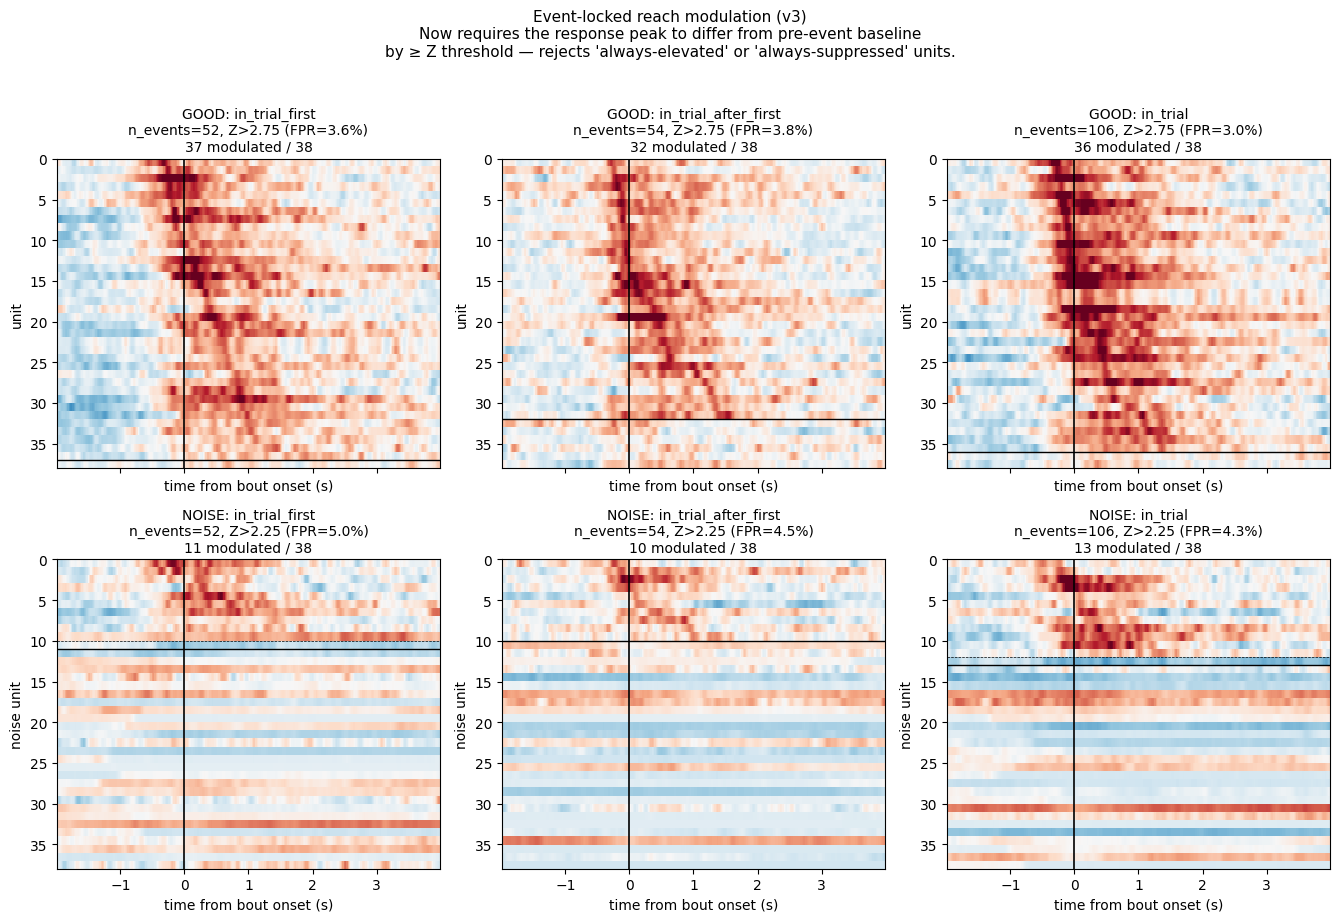


Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\modulation_multi_subset_v3.png

===== SUMMARY TABLE =====
Subset                 N_events  N_good_mod  Good_pct  N_noise_mod  Noise_pct
--------------------------------------------------------------------------------
in_trial_first               52          37     97.4%           11      28.9%
in_trial_after_first         54          32     84.2%           10      26.3%
in_trial                    106          36     94.7%           13      34.2%

===== INTERPRETATION GUIDE =====
 • Sustained background bands should now be excluded from modulated count
 • Remaining noise modulations should be either:
   - Leaked real neurons (diagonal cascade, similar to good units)
   - Spike-loss artifact (sharp t=0 silencing)
 • If your noise count drops significantly from v2, the event-locked
   criterion is doing its job — non-event-locked units removed.

===== CELL M v3 COMPLETE =====



In [3]:
# ============================================================
# CELL M v3 — MULTI-SUBSET REACH MODULATION + NOISE CONTROL
#             WITH EVENT-LOCKED CRITERION
# ============================================================
# Change vs v2: count_modulated now requires the response window
# peak to differ from pre-event baseline by at least Z_thresh.
# This rejects "sustained background" units that sit at a non-zero
# z level throughout the whole window (not actually event-locked).
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL M v3 — EVENT-LOCKED MULTI-SUBSET REACH MODULATION =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SUBSETS_TO_RUN     = ["in_trial_first", "in_trial_after_first",
                      "in_trial", "beam_breaking"]
RUN_NOISE_CONTROL  = True

WIN_PRE            = 2.0
WIN_POST           = 4.0
RESPONSE_WIN       = (-0.5, 2.0)
BASELINE_WIN       = (-2.0, -0.5)         # NEW: used for event-lock check
BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
MIN_CONSECUTIVE_MS = 100
MIN_BASELINE_HZ    = 1.0
CONSISTENCY_FRAC   = 0.30
N_SHUFFLES_CALIB   = 200
TARGET_FPR         = 0.05
RANDOM_SEED        = 42
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD BOUT DATA
# ------------------------------------------------------------
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
bout_onset_t   = bouts["onset_t"]
bout_trial_id  = bouts["trial_id"]
bout_broke_beam = bouts["broke_beam"]

def build_subset_mask(name):
    if name == "all":
        return np.ones(len(bout_onset_t), dtype=bool)
    if name == "in_trial":
        return bout_trial_id >= 0
    if name == "out_of_trial":
        return bout_trial_id == -1
    if name == "beam_breaking":
        return bout_broke_beam
    if name == "in_trial_first":
        m = np.zeros(len(bout_onset_t), dtype=bool)
        for t_i in np.unique(bout_trial_id):
            if t_i == -1:
                continue
            ii = np.where(bout_trial_id == t_i)[0]
            first = ii[np.argmin(bout_onset_t[ii])]
            m[first] = True
        return m
    if name == "in_trial_after_first":
        m = np.zeros(len(bout_onset_t), dtype=bool)
        for t_i in np.unique(bout_trial_id):
            if t_i == -1:
                continue
            ii = np.where(bout_trial_id == t_i)[0]
            if len(ii) > 1:
                first = ii[np.argmin(bout_onset_t[ii])]
                for k in ii:
                    if k != first:
                        m[k] = True
        return m
    raise ValueError(f"Unknown subset: {name}")

# ------------------------------------------------------------
# LOAD UNITS
# ------------------------------------------------------------
good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"
good_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}
unit_rates = np.array([len(good_spikes[int(u)]) / recording_duration
                       for u in good_units])
eligible_good = good_units[unit_rates >= MIN_BASELINE_HZ]
print(f"Eligible good units: {len(eligible_good)} / {len(good_units)}")

noise_unit_ids = []
noise_spikes = {}
if RUN_NOISE_CONTROL:
    saved_noise_files = sorted(spikes_dir.glob("noise_unit_*.npy"))
    for f in saved_noise_files:
        u = int(f.stem.replace("noise_unit_", ""))
        spk = np.load(f)
        rate = len(spk) / recording_duration
        if rate >= MIN_BASELINE_HZ:
            noise_unit_ids.append(u)
            noise_spikes[u] = spk
    print(f"Eligible noise units: {len(noise_unit_ids)} / {len(saved_noise_files)}")
    if len(noise_unit_ids) == 0:
        print("WARNING: no eligible noise units; disabling noise control.")
        RUN_NOISE_CONTROL = False

# ------------------------------------------------------------
# SHARED COMPUTATION
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
baseline_mask = (centers >= BASELINE_WIN[0]) & (centers < BASELINE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0

def compute_psth_set(units, spike_dict, events):
    psth_per_trial = np.zeros((len(units), len(events), n_bins))
    for u_i, u in enumerate(units):
        spk = spike_dict[int(u)]
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            psth_per_trial[u_i, e_i] = h / BIN_SIZE
    smooth = gaussian_filter1d(psth_per_trial, sigma=SMOOTH_SIGMA_BINS, axis=2)
    return smooth, smooth.mean(axis=1)

def count_modulated_event_locked(z_mat, z_thresh):
    """Event-locked modulation: require both (a) consecutive supra-threshold
    bins in response window, AND (b) response peak differs from pre-event
    baseline by ≥ z_thresh (so we reject sustained-background units)."""
    out = np.zeros(z_mat.shape[0], dtype=bool)
    for i in range(z_mat.shape[0]):
        z_resp = z_mat[i, response_mask]
        z_base = z_mat[i, baseline_mask]

        passed_thresh = False
        for arr in (z_resp > z_thresh, z_resp < -z_thresh):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            d = np.diff(padded.astype(int))
            s = np.where(d == 1)[0]
            e = np.where(d == -1)[0]
            if (e - s).max() >= min_consec_bins:
                passed_thresh = True
                break
        if not passed_thresh:
            continue

        # Event-locked check
        resp_peak = z_resp[np.argmax(np.abs(z_resp))]
        base_mean = z_base.mean()
        if abs(resp_peak - base_mean) >= z_thresh:
            out[i] = True
    return out

def run_subset(name, units, spike_dict, rng):
    mask = build_subset_mask(name)
    events = np.sort(bout_onset_t[mask])
    n_events = len(events)
    if n_events < 10:
        print(f"  Skipping {name}: only {n_events} events.")
        return None
    print(f"  {name}: n_events={n_events}, building null...")

    shuffled_psths = np.zeros((N_SHUFFLES_CALIB, len(units), n_bins))
    for s in range(N_SHUFFLES_CALIB):
        fake = rng.uniform(t_min, t_max, size=n_events)
        fake.sort()
        _, fake_mean = compute_psth_set(units, spike_dict, fake)
        shuffled_psths[s] = fake_mean

    null_mean = shuffled_psths.mean(axis=0)
    null_std  = shuffled_psths.std(axis=0)
    null_std  = np.maximum(null_std, null_mean * 0.01 + 0.1)

    z_grid = np.arange(2.0, 6.01, 0.25)
    fpr = np.zeros((N_SHUFFLES_CALIB, len(z_grid)))
    for s in range(N_SHUFFLES_CALIB):
        z_s = (shuffled_psths[s] - null_mean) / null_std
        for j, thr in enumerate(z_grid):
            fpr[s, j] = count_modulated_event_locked(z_s, thr).sum() / len(units)
    mean_fpr = fpr.mean(axis=0)
    viable = np.where(mean_fpr <= TARGET_FPR)[0]
    z_chosen = float(z_grid[viable[0]]) if len(viable) else float(z_grid[-1])
    fpr_at_chosen = mean_fpr[np.argmin(np.abs(z_grid - z_chosen))]

    per_trial, real_mean = compute_psth_set(units, spike_dict, events)
    real_z = (real_mean - null_mean) / null_std
    mod_init = count_modulated_event_locked(real_z, z_chosen)

    per_trial_z = (per_trial - null_mean[:, None, :]) / null_std[:, None, :]
    per_trial_z_resp = per_trial_z[:, :, response_mask]
    trial_resp = ((per_trial_z_resp > z_chosen).any(axis=2) |
                  (per_trial_z_resp < -z_chosen).any(axis=2))
    trial_cons = trial_resp.mean(axis=1)
    mod_final = mod_init & (trial_cons >= CONSISTENCY_FRAC)

    z_resp = real_z[:, response_mask]
    response_centers = centers[response_mask]
    peak_idx = np.argmax(np.abs(z_resp), axis=1)
    peak_lat = response_centers[peak_idx]
    peak_z = z_resp[np.arange(len(units)), peak_idx]

    return {
        "name": name,
        "n_events": int(n_events),
        "units": units,
        "z_mean": real_z,
        "z_threshold": z_chosen,
        "fpr_at_threshold": fpr_at_chosen,
        "modulated": mod_final,
        "trial_consistency": trial_cons,
        "peak_latency": peak_lat,
        "peak_z": peak_z,
        "fpr_table": dict(zip([float(t) for t in z_grid],
                              [float(f) for f in mean_fpr])),
    }

# ------------------------------------------------------------
# RUN ALL SUBSETS ON GOOD UNITS
# ------------------------------------------------------------
print(f"\n===== RUNNING SUBSETS ON {len(eligible_good)} GOOD UNITS =====")
rng = np.random.default_rng(RANDOM_SEED)
results_good = {}
for name in SUBSETS_TO_RUN:
    res = run_subset(name, eligible_good, good_spikes, rng)
    if res is not None:
        results_good[name] = res

# ------------------------------------------------------------
# RUN NOISE CONTROL
# ------------------------------------------------------------
results_noise = {}
if RUN_NOISE_CONTROL:
    print(f"\n===== RUNNING SAME SUBSETS ON {len(noise_unit_ids)} NOISE UNITS =====")
    rng_n = np.random.default_rng(RANDOM_SEED + 999)
    for name in SUBSETS_TO_RUN:
        res = run_subset(name, np.array(noise_unit_ids), noise_spikes, rng_n)
        if res is not None:
            results_noise[name] = res

# ------------------------------------------------------------
# OVERLAP STATISTICS (good units)
# ------------------------------------------------------------
print("\n===== OVERLAP STATISTICS (good units) =====")
overlap_text = []
mod_sets = {name: set(results_good[name]["units"][results_good[name]["modulated"]])
            for name in results_good}
for name, units_set in mod_sets.items():
    overlap_text.append(f"\n{name}: {len(units_set)} modulated units")
for i, a in enumerate(mod_sets):
    for b in list(mod_sets)[i+1:]:
        both = mod_sets[a] & mod_sets[b]
        only_a = mod_sets[a] - mod_sets[b]
        only_b = mod_sets[b] - mod_sets[a]
        line = (f"\n{a} ∩ {b}: {len(both)}   "
                f"({a} only: {len(only_a)}, {b} only: {len(only_b)})")
        overlap_text.append(line)

if "in_trial_first" in mod_sets:
    ift = mod_sets["in_trial_first"]
    for name in mod_sets:
        if name == "in_trial_first":
            continue
        also = ift & mod_sets[name]
        only_ift = ift - mod_sets[name]
        overlap_text.append(
            f"\nOf {len(ift)} in_trial_first units: "
            f"{len(also)} are ALSO modulated in {name}; "
            f"{len(only_ift)} are ONLY in in_trial_first."
        )
print("".join(overlap_text))

# ------------------------------------------------------------
# COMPARISON PLOT
# ------------------------------------------------------------
n_good_subsets = len(results_good)
n_rows = 1 + (1 if RUN_NOISE_CONTROL and results_noise else 0)
fig, axes = plt.subplots(n_rows, n_good_subsets,
                         figsize=(4.5 * n_good_subsets, 9 * n_rows / 2),
                         sharex=True)
if n_rows == 1:
    axes = axes[np.newaxis, :]
if n_good_subsets == 1:
    axes = axes[:, np.newaxis]

def sort_by_modulation(res):
    mod = res["modulated"]
    pz  = res["peak_z"]
    pl  = res["peak_latency"]
    final_idx = np.where(mod)[0]
    exc = final_idx[pz[final_idx] > 0][np.argsort(pl[final_idx[pz[final_idx] > 0]])]
    sup = final_idx[pz[final_idx] < 0][np.argsort(pl[final_idx[pz[final_idx] < 0]])]
    nonmod = np.where(~mod)[0]
    nonmod = nonmod[np.argsort(pl[nonmod])]
    return np.concatenate([exc, sup, nonmod]), len(exc), len(exc) + len(sup)

all_z = np.concatenate([results_good[n]["z_mean"].ravel()
                        for n in results_good])
vmax = max(3.0, np.percentile(np.abs(all_z), 99))

for col, name in enumerate(results_good):
    res = results_good[name]
    order, n_exc, n_mod = sort_by_modulation(res)
    ax = axes[0, col]
    im = ax.imshow(res["z_mean"][order], aspect="auto",
                   extent=[centers[0], centers[-1], len(res["units"]), 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=1.2)
    if n_exc:
        ax.axhline(n_exc, color="black", lw=0.5, linestyle="--")
    ax.axhline(n_mod, color="black", lw=1.0)
    ax.set_title(f"GOOD: {name}\n"
                 f"n_events={res['n_events']}, "
                 f"Z>{res['z_threshold']:.2f} (FPR={res['fpr_at_threshold']*100:.1f}%)\n"
                 f"{int(res['modulated'].sum())} modulated / {len(res['units'])}",
                 fontsize=10)
    ax.set_ylabel("unit")
    ax.set_xlabel("time from bout onset (s)")

if RUN_NOISE_CONTROL and results_noise:
    for col, name in enumerate(results_noise):
        res = results_noise[name]
        order, n_exc, n_mod = sort_by_modulation(res)
        ax = axes[1, col]
        im = ax.imshow(res["z_mean"][order], aspect="auto",
                       extent=[centers[0], centers[-1], len(res["units"]), 0],
                       cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                       interpolation="nearest")
        ax.axvline(0, color="black", lw=1.2)
        if n_exc:
            ax.axhline(n_exc, color="black", lw=0.5, linestyle="--")
        ax.axhline(n_mod, color="black", lw=1.0)
        ax.set_title(f"NOISE: {name}\n"
                     f"n_events={res['n_events']}, "
                     f"Z>{res['z_threshold']:.2f} (FPR={res['fpr_at_threshold']*100:.1f}%)\n"
                     f"{int(res['modulated'].sum())} modulated / {len(res['units'])}",
                     fontsize=10)
        ax.set_ylabel("noise unit")
        ax.set_xlabel("time from bout onset (s)")

plt.suptitle(
    "Event-locked reach modulation (v3)\n"
    "Now requires the response peak to differ from pre-event baseline\n"
    "by ≥ Z threshold — rejects 'always-elevated' or 'always-suppressed' units.",
    fontsize=11, y=1.02
)

plt.tight_layout()
out_path = analysis_folder / "qc" / "modulation_multi_subset_v3.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"modulation_multi_subset_v3_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------
out_dir = analysis_folder / "qc"
def save_result(prefix, res):
    np.savez(out_dir / f"{prefix}_arrays.npz",
             units=res["units"],
             z_mean=res["z_mean"],
             modulated=res["modulated"],
             trial_consistency=res["trial_consistency"],
             peak_latency=res["peak_latency"],
             peak_z=res["peak_z"],
             centers=centers,
             z_threshold=res["z_threshold"])
    with open(out_dir / f"{prefix}.json", "w") as f:
        json.dump({
            "n_events": int(res["n_events"]),
            "z_threshold": float(res["z_threshold"]),
            "fpr_at_threshold": float(res["fpr_at_threshold"]),
            "n_modulated": int(res["modulated"].sum()),
            "n_units": int(len(res["units"])),
            "fpr_table": res["fpr_table"],
        }, f, indent=2)

for name in results_good:
    save_result(f"reach_good_{name}", results_good[name])
for name in results_noise:
    save_result(f"reach_noise_{name}", results_noise[name])

# ------------------------------------------------------------
# SUMMARY TABLE
# ------------------------------------------------------------
print("\n===== SUMMARY TABLE =====")
print(f"{'Subset':<22} {'N_events':>8} {'N_good_mod':>11} "
      f"{'Good_pct':>9} {'N_noise_mod':>12} {'Noise_pct':>10}")
print("-" * 80)
for name in SUBSETS_TO_RUN:
    if name not in results_good:
        continue
    rg = results_good[name]
    ngm = int(rg["modulated"].sum())
    gpct = 100.0 * ngm / len(rg["units"])
    if name in results_noise:
        rn = results_noise[name]
        nnm = int(rn["modulated"].sum())
        npct = 100.0 * nnm / len(rn["units"])
        print(f"{name:<22} {rg['n_events']:>8d} {ngm:>11d} {gpct:>8.1f}% "
              f"{nnm:>12d} {npct:>9.1f}%")
    else:
        print(f"{name:<22} {rg['n_events']:>8d} {ngm:>11d} {gpct:>8.1f}% "
              f"{'(n/a)':>12} {'(n/a)':>10}")

print("\n===== INTERPRETATION GUIDE =====")
print(" • Sustained background bands should now be excluded from modulated count")
print(" • Remaining noise modulations should be either:")
print("   - Leaked real neurons (diagonal cascade, similar to good units)")
print("   - Spike-loss artifact (sharp t=0 silencing)")
print(" • If your noise count drops significantly from v2, the event-locked")
print("   criterion is doing its job — non-event-locked units removed.")

print("\n===== CELL M v3 COMPLETE =====\n")


===== CELL N — SPLIT-HALF + TEMPORAL FLIP CONTROLS =====
Subset: in_trial, n_events = 106
Eligible good units: 38
Loaded 36 previously-modulated units from reach_good_in_trial_arrays.npz

--- Test 4: temporal flip (30.0 s before each event) ---
  Valid flipped events: 106 / 106
  Building null (200 shuffles)...
    50/200
    100/200
    150/200
    200/200
  Using prior Z threshold = 2.75

  Real events:           36 / 38 modulated (94.7%)
  Flipped events (-30s): 6 / 38 modulated (15.8%)
  Expected by chance:    ~1 (5% FPR)
  ~ MARGINAL: flipped events show some modulation, but less than real.

--- Test 5: split-half consistency (100 splits) ---
  Testing on the 36 previously-modulated units
    20/100 splits done
    40/100 splits done
    60/100 splits done
    80/100 splits done
    100/100 splits done

  Mean split-half correlation per modulated unit:
    median: r = 0.448
    25th-75th percentile: [0.335, 0.610]
    units with r > 0.5: 15 / 36
    units with r > 0.3: 28 / 36

 

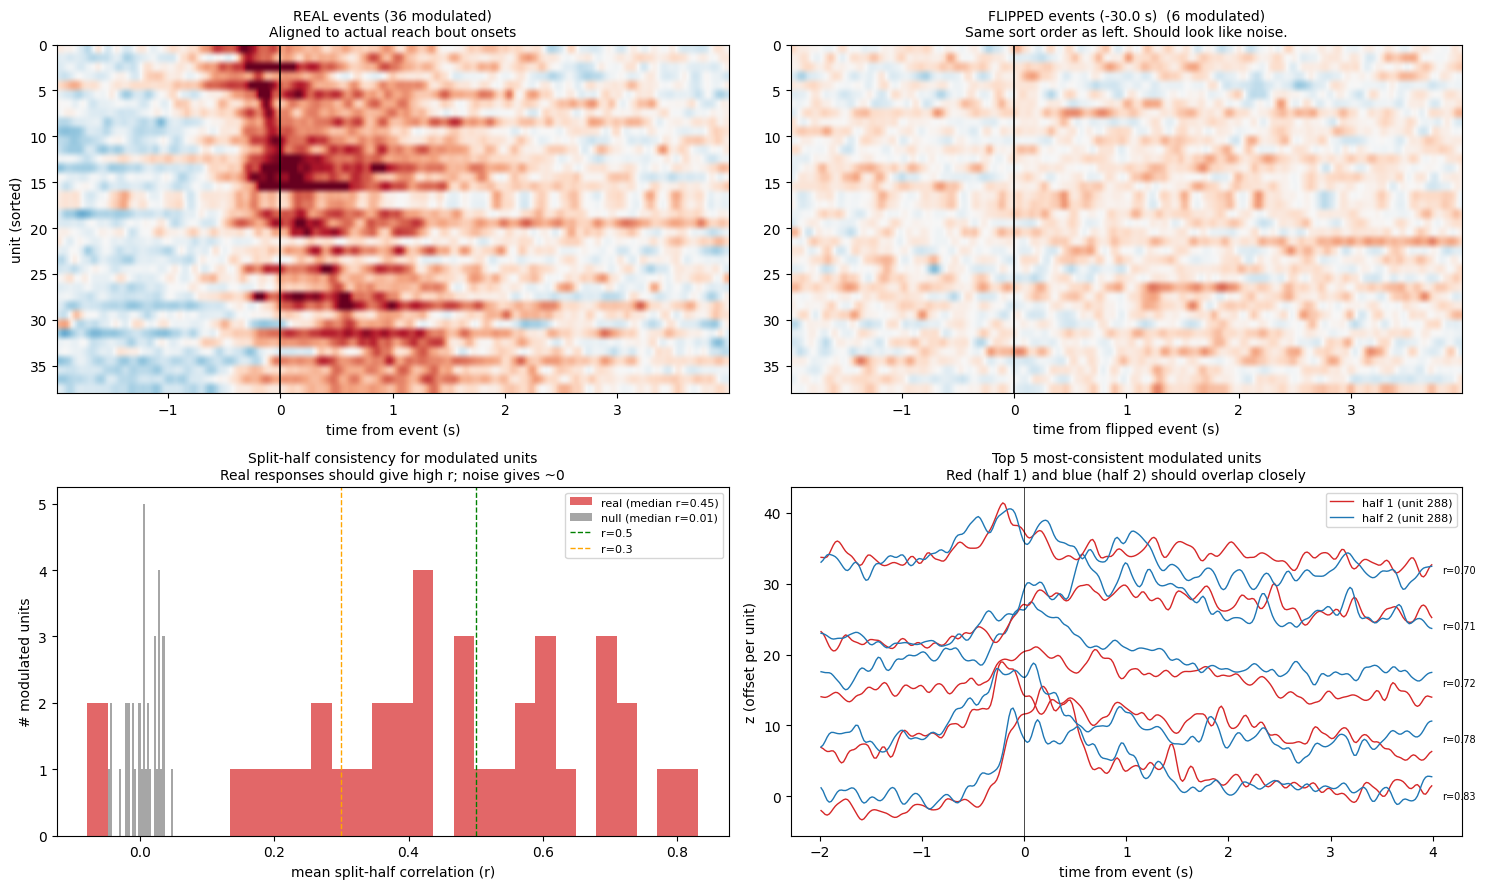


Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\falsification_extra_in_trial.png

===== INTERPRETATION GUIDE =====
Test 4 (temporal flip):
  Real:    36 modulated
  Flipped: 6 modulated
  Chance:  ~1 expected at 5% FPR
  → If flipped ≈ chance, the signal is locked to reach events specifically.
  → If flipped is also high, something else periodic is going on.

Test 5 (split-half consistency):
  Real median r: 0.45
  Null median r: 0.01
  → If real r > 0.5 and null r ~ 0, modulation is reliable and reproducible.
  → If real r ~ null r, modulation may be driven by trial outliers.

===== CELL N COMPLETE =====



In [18]:
# ============================================================
# CELL N — FALSIFICATION: SPLIT-HALF + TEMPORAL FLIP
# ============================================================
# Two additional controls beyond Cell I and Cell M:
#
# Test 4 (temporal flip): Align to a time point 30 s BEFORE each
#   real reach onset. Run the same modulation analysis. Should
#   produce near-chance modulation. This tests whether anything
#   time-locked spuriously appears far from the events.
#
# Test 5 (split-half consistency): Split events into random halves,
#   compute PSTH for each half, correlate the half-PSTHs within
#   each modulated unit. Real reach-locked modulation gives high
#   half-correlations; noise-driven modulation gives ~0.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

print("\n===== CELL N — SPLIT-HALF + TEMPORAL FLIP CONTROLS =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SUBSET_NAME        = "in_trial"      # which subset to test
WIN_PRE            = 2.0
WIN_POST           = 4.0
RESPONSE_WIN       = (-0.5, 2.0)
BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
MIN_BASELINE_HZ    = 1.0
TEMPORAL_FLIP_S    = 30.0            # how far back to shift events
N_SHUFFLES_CALIB   = 200
RANDOM_SEED        = 42
N_HALF_SPLITS      = 100             # split-half repeats
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD: events + spikes + the prior modulated-unit set from Cell M/L
# ------------------------------------------------------------
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
bout_onset_t   = bouts["onset_t"]
bout_trial_id  = bouts["trial_id"]
bout_broke_beam = bouts["broke_beam"]

def build_subset_mask(name):
    if name == "all":
        return np.ones(len(bout_onset_t), dtype=bool)
    if name == "in_trial":
        return bout_trial_id >= 0
    if name == "out_of_trial":
        return bout_trial_id == -1
    if name == "beam_breaking":
        return bout_broke_beam
    if name == "in_trial_first":
        m = np.zeros(len(bout_onset_t), dtype=bool)
        for t_i in np.unique(bout_trial_id):
            if t_i == -1:
                continue
            ii = np.where(bout_trial_id == t_i)[0]
            first = ii[np.argmin(bout_onset_t[ii])]
            m[first] = True
        return m
    raise ValueError(f"Unknown subset: {name}")

mask = build_subset_mask(SUBSET_NAME)
event_times = np.sort(bout_onset_t[mask])
n_events = len(event_times)
print(f"Subset: {SUBSET_NAME}, n_events = {n_events}")

good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"
all_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}
unit_rates = np.array([len(all_spikes[int(u)]) / recording_duration
                       for u in good_units])
eligible_good = good_units[unit_rates >= MIN_BASELINE_HZ]
print(f"Eligible good units: {len(eligible_good)}")

# Load prior modulated-unit results from Cell M for this subset
prior_arrays_path = analysis_folder / "qc" / f"reach_good_{SUBSET_NAME}_arrays.npz"
if not prior_arrays_path.exists():
    print(f"WARNING: prior results not found at {prior_arrays_path}")
    print(f"Cell N can still run, but won't use the prior modulated set for "
          f"split-half. Will use all eligible units instead.")
    prior_modulated_units = eligible_good
else:
    prior_data = np.load(prior_arrays_path)
    prior_modulated_units = prior_data["units"][prior_data["modulated"]]
    print(f"Loaded {len(prior_modulated_units)} previously-modulated units "
          f"from {prior_arrays_path.name}")

# ------------------------------------------------------------
# COMPUTATION HELPERS
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])

rng = np.random.default_rng(RANDOM_SEED)

def compute_psth_mean(units, spike_dict, events):
    psth = np.zeros((len(units), n_bins))
    for u_i, u in enumerate(units):
        spk = spike_dict[int(u)]
        per_trial = np.zeros((len(events), n_bins))
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            per_trial[e_i] = h / BIN_SIZE
        smooth = gaussian_filter1d(per_trial, sigma=SMOOTH_SIGMA_BINS, axis=1)
        psth[u_i] = smooth.mean(axis=0)
    return psth

# ============================================================
# TEST 4: TEMPORAL FLIP CONTROL
# ============================================================
print(f"\n--- Test 4: temporal flip ({TEMPORAL_FLIP_S} s before each event) ---")

flipped_events = event_times - TEMPORAL_FLIP_S
flipped_events = flipped_events[flipped_events >= WIN_PRE + 1.0]
flipped_events = flipped_events[flipped_events <= recording_duration - WIN_POST - 1.0]
print(f"  Valid flipped events: {len(flipped_events)} / {n_events}")

# Build null using same structure as the real analysis (matched n_events shuffles)
t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0

print(f"  Building null ({N_SHUFFLES_CALIB} shuffles)...")
shuffled_psths_real = np.zeros((N_SHUFFLES_CALIB, len(eligible_good), n_bins))
for s in range(N_SHUFFLES_CALIB):
    fake = rng.uniform(t_min, t_max, size=n_events)
    fake.sort()
    shuffled_psths_real[s] = compute_psth_mean(eligible_good, all_spikes, fake)
    if (s+1) % 50 == 0:
        print(f"    {s+1}/{N_SHUFFLES_CALIB}")

null_mean = shuffled_psths_real.mean(axis=0)
null_std  = shuffled_psths_real.std(axis=0)
null_std  = np.maximum(null_std, null_mean * 0.01 + 0.1)

# Compute z-scored PSTHs for real and flipped
real_mean = compute_psth_mean(eligible_good, all_spikes, event_times)
flipped_mean = compute_psth_mean(eligible_good, all_spikes, flipped_events)

real_z = (real_mean - null_mean) / null_std
flipped_z = (flipped_mean - null_mean) / null_std

# Modulation criterion (use Z threshold from previous run if available)
if prior_arrays_path.exists():
    z_thresh = float(prior_data["z_threshold"])
    print(f"  Using prior Z threshold = {z_thresh:.2f}")
else:
    z_thresh = 2.75
    print(f"  Using default Z threshold = {z_thresh:.2f}")

def count_modulated(z_mat, z_thr):
    z_resp = z_mat[:, response_mask]
    min_consec_bins = int(np.ceil(0.100 / BIN_SIZE))
    out = np.zeros(z_resp.shape[0], dtype=bool)
    for i in range(z_resp.shape[0]):
        for arr in (z_resp[i] > z_thr, z_resp[i] < -z_thr):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            d = np.diff(padded.astype(int))
            s = np.where(d == 1)[0]
            e = np.where(d == -1)[0]
            if (e - s).max() >= min_consec_bins:
                out[i] = True
                break
    return out

n_mod_real = int(count_modulated(real_z, z_thresh).sum())
n_mod_flipped = int(count_modulated(flipped_z, z_thresh).sum())
n_mod_expected_by_chance = int(0.05 * len(eligible_good))

print(f"\n  Real events:           {n_mod_real} / {len(eligible_good)} modulated "
      f"({100*n_mod_real/len(eligible_good):.1f}%)")
print(f"  Flipped events (-30s): {n_mod_flipped} / {len(eligible_good)} modulated "
      f"({100*n_mod_flipped/len(eligible_good):.1f}%)")
print(f"  Expected by chance:    ~{n_mod_expected_by_chance} (5% FPR)")

if n_mod_flipped <= n_mod_expected_by_chance * 2:
    print("  ✓ PASSED: flipped events produce near-chance modulation.")
elif n_mod_flipped <= n_mod_real * 0.3:
    print("  ~ MARGINAL: flipped events show some modulation, but less than real.")
else:
    print("  ✗ FAILED: flipped events also show substantial modulation.")
    print("     Something time-locked is happening even 30s before each reach.")

# ============================================================
# TEST 5: SPLIT-HALF CONSISTENCY
# ============================================================
print(f"\n--- Test 5: split-half consistency ({N_HALF_SPLITS} splits) ---")
print(f"  Testing on the {len(prior_modulated_units)} previously-modulated units")

# For each split: randomly halve events, compute mean PSTH for each half,
# correlate them within each modulated unit's response window
mod_unit_idx_in_eligible = np.array([
    np.where(eligible_good == u)[0][0]
    for u in prior_modulated_units
    if u in eligible_good
])
prior_mod_units = eligible_good[mod_unit_idx_in_eligible]

# Get spike trains for modulated units only (faster)
mod_spikes = {int(u): all_spikes[int(u)] for u in prior_mod_units}

half_correlations = np.zeros((N_HALF_SPLITS, len(prior_mod_units)))

for s in range(N_HALF_SPLITS):
    perm = rng.permutation(len(event_times))
    half_size = len(event_times) // 2
    h1 = event_times[perm[:half_size]]
    h2 = event_times[perm[half_size:half_size*2]]
    h1.sort(); h2.sort()

    psth1 = compute_psth_mean(prior_mod_units, mod_spikes, h1)
    psth2 = compute_psth_mean(prior_mod_units, mod_spikes, h2)

    # Correlate within response window for each unit
    for u_i in range(len(prior_mod_units)):
        try:
            r, _ = pearsonr(psth1[u_i, response_mask],
                            psth2[u_i, response_mask])
            half_correlations[s, u_i] = r
        except:
            half_correlations[s, u_i] = np.nan

    if (s+1) % 20 == 0:
        print(f"    {s+1}/{N_HALF_SPLITS} splits done")

mean_half_corr = np.nanmean(half_correlations, axis=0)

print(f"\n  Mean split-half correlation per modulated unit:")
print(f"    median: r = {np.median(mean_half_corr):.3f}")
print(f"    25th-75th percentile: [{np.percentile(mean_half_corr, 25):.3f}, "
      f"{np.percentile(mean_half_corr, 75):.3f}]")
print(f"    units with r > 0.5: {int((mean_half_corr > 0.5).sum())} / {len(prior_mod_units)}")
print(f"    units with r > 0.3: {int((mean_half_corr > 0.3).sum())} / {len(prior_mod_units)}")

# Compare to a null where we randomize timing
print(f"\n  Building null half-correlation distribution (random events, "
      f"{N_HALF_SPLITS} splits)...")
null_half_correlations = np.zeros((N_HALF_SPLITS, len(prior_mod_units)))
for s in range(N_HALF_SPLITS):
    fake = rng.uniform(t_min, t_max, size=len(event_times))
    fake.sort()
    perm = rng.permutation(len(fake))
    half_size = len(fake) // 2
    h1 = fake[perm[:half_size]]
    h2 = fake[perm[half_size:half_size*2]]
    h1.sort(); h2.sort()
    psth1 = compute_psth_mean(prior_mod_units, mod_spikes, h1)
    psth2 = compute_psth_mean(prior_mod_units, mod_spikes, h2)
    for u_i in range(len(prior_mod_units)):
        try:
            r, _ = pearsonr(psth1[u_i, response_mask],
                            psth2[u_i, response_mask])
            null_half_correlations[s, u_i] = r
        except:
            null_half_correlations[s, u_i] = np.nan

null_mean_half_corr = np.nanmean(null_half_correlations, axis=0)
print(f"  Null half-correlations (random events):")
print(f"    median: r = {np.median(null_mean_half_corr):.3f}")

if np.median(mean_half_corr) > 0.5 and np.median(null_mean_half_corr) < 0.15:
    print("\n  ✓ PASSED: modulated units have high split-half consistency, "
          "null does not.")
elif np.median(mean_half_corr) > 0.3:
    print("\n  ~ MARGINAL: modulated units show some consistency, but moderate. "
          "Real signal is present but noisier than ideal.")
else:
    print("\n  ✗ FAILED: modulated units don't show consistent responses "
          "across trial halves. Modulation may be driven by outlier trials.")

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Test 4: heatmap real vs flipped
vmax = max(3.0, np.percentile(np.abs(real_z), 99))
sort_idx = np.argsort(np.argmax(np.abs(real_z[:, response_mask]), axis=1))

ax = axes[0, 0]
ax.imshow(real_z[sort_idx], aspect="auto",
          extent=[centers[0], centers[-1], len(eligible_good), 0],
          cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.axvline(0, color="black", lw=1.2)
ax.set_title(f"REAL events ({n_mod_real} modulated)\n"
             f"Aligned to actual reach bout onsets",
             fontsize=10)
ax.set_xlabel("time from event (s)")
ax.set_ylabel("unit (sorted)")

ax = axes[0, 1]
ax.imshow(flipped_z[sort_idx], aspect="auto",
          extent=[centers[0], centers[-1], len(eligible_good), 0],
          cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.axvline(0, color="black", lw=1.2)
ax.set_title(f"FLIPPED events (-{TEMPORAL_FLIP_S} s)  ({n_mod_flipped} modulated)\n"
             f"Same sort order as left. Should look like noise.",
             fontsize=10)
ax.set_xlabel("time from flipped event (s)")

# Test 5: half-correlation histogram
ax = axes[1, 0]
ax.hist(mean_half_corr, bins=30, color="C3", alpha=0.7,
        label=f"real (median r={np.median(mean_half_corr):.2f})")
ax.hist(null_mean_half_corr, bins=30, color="gray", alpha=0.7,
        label=f"null (median r={np.median(null_mean_half_corr):.2f})")
ax.axvline(0.5, color="green", linestyle="--", lw=1, label="r=0.5")
ax.axvline(0.3, color="orange", linestyle="--", lw=1, label="r=0.3")
ax.set_xlabel("mean split-half correlation (r)")
ax.set_ylabel("# modulated units")
ax.set_title("Split-half consistency for modulated units\n"
             "Real responses should give high r; noise gives ~0", fontsize=10)
ax.legend(fontsize=8)

# Example unit traces: half1 vs half2 for the most consistent units
ax = axes[1, 1]
top_consistent = np.argsort(mean_half_corr)[::-1][:5]
# Recompute a fresh split for visualization
perm = rng.permutation(len(event_times))
half_size = len(event_times) // 2
h1 = event_times[perm[:half_size]]
h2 = event_times[perm[half_size:half_size*2]]
h1.sort(); h2.sort()
psth1_disp = compute_psth_mean(prior_mod_units, mod_spikes, h1)
psth2_disp = compute_psth_mean(prior_mod_units, mod_spikes, h2)

# Z-score same way
psth1_z = (psth1_disp - null_mean[mod_unit_idx_in_eligible]) / null_std[mod_unit_idx_in_eligible]
psth2_z = (psth2_disp - null_mean[mod_unit_idx_in_eligible]) / null_std[mod_unit_idx_in_eligible]

for k, u_i in enumerate(top_consistent):
    offset = k * 8
    ax.plot(centers, psth1_z[u_i] + offset, color="C3", lw=1.0,
            label=f"half 1 (unit {int(prior_mod_units[u_i])})" if k == 0 else None)
    ax.plot(centers, psth2_z[u_i] + offset, color="C0", lw=1.0,
            label=f"half 2 (unit {int(prior_mod_units[u_i])})" if k == 0 else None)
    ax.text(centers[-1] + 0.1, offset, f"r={mean_half_corr[u_i]:.2f}",
            fontsize=7, va="center")
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("time from event (s)")
ax.set_ylabel("z (offset per unit)")
ax.set_title("Top 5 most-consistent modulated units\n"
             "Red (half 1) and blue (half 2) should overlap closely", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
out_path = analysis_folder / "qc" / f"falsification_extra_{SUBSET_NAME}.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"falsification_extra_{SUBSET_NAME}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
results = {
    "subset_name": SUBSET_NAME,
    "n_events": int(n_events),
    "test4_temporal_flip": {
        "flip_offset_s": float(TEMPORAL_FLIP_S),
        "n_flipped_events_valid": int(len(flipped_events)),
        "n_modulated_real": int(n_mod_real),
        "n_modulated_flipped": int(n_mod_flipped),
        "n_expected_by_chance": int(n_mod_expected_by_chance),
    },
    "test5_split_half": {
        "n_splits": int(N_HALF_SPLITS),
        "n_modulated_tested": int(len(prior_mod_units)),
        "real_median_r": float(np.median(mean_half_corr)),
        "real_p25_r": float(np.percentile(mean_half_corr, 25)),
        "real_p75_r": float(np.percentile(mean_half_corr, 75)),
        "null_median_r": float(np.median(null_mean_half_corr)),
        "units_above_05": int((mean_half_corr > 0.5).sum()),
        "units_above_03": int((mean_half_corr > 0.3).sum()),
    },
}
with open(analysis_folder / "qc" / f"falsification_extra_{SUBSET_NAME}.json", "w") as f:
    json.dump(results, f, indent=2)

np.savez(analysis_folder / "qc" / f"falsification_extra_{SUBSET_NAME}_arrays.npz",
         eligible_good=eligible_good,
         prior_mod_units=prior_mod_units,
         mean_half_corr=mean_half_corr,
         null_mean_half_corr=null_mean_half_corr,
         real_z=real_z,
         flipped_z=flipped_z)

print("\n===== INTERPRETATION GUIDE =====")
print("Test 4 (temporal flip):")
print(f"  Real:    {n_mod_real} modulated")
print(f"  Flipped: {n_mod_flipped} modulated")
print(f"  Chance:  ~{n_mod_expected_by_chance} expected at 5% FPR")
print(f"  → If flipped ≈ chance, the signal is locked to reach events specifically.")
print(f"  → If flipped is also high, something else periodic is going on.")
print(f"")
print("Test 5 (split-half consistency):")
print(f"  Real median r: {np.median(mean_half_corr):.2f}")
print(f"  Null median r: {np.median(null_mean_half_corr):.2f}")
print(f"  → If real r > 0.5 and null r ~ 0, modulation is reliable and reproducible.")
print(f"  → If real r ~ null r, modulation may be driven by trial outliers.")

print("\n===== CELL N COMPLETE =====\n")


===== CELL O — SPLIT-HALF: GOOD vs NOISE =====
Subset: in_trial, n_events = 30
Modulated good units (from Cell M):  22
Modulated noise units (from Cell M): 10

Computing split-half correlations for GOOD modulated units...
    25/100
    50/100
    75/100
    100/100

Computing split-half correlations for NOISE modulated units...


C:\Users\kkost\AppData\Local\Temp\ipykernel_12916\390428104.py:99: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(p1[u_i, response_mask], p2[u_i, response_mask])


    25/100
    50/100
    75/100
    100/100


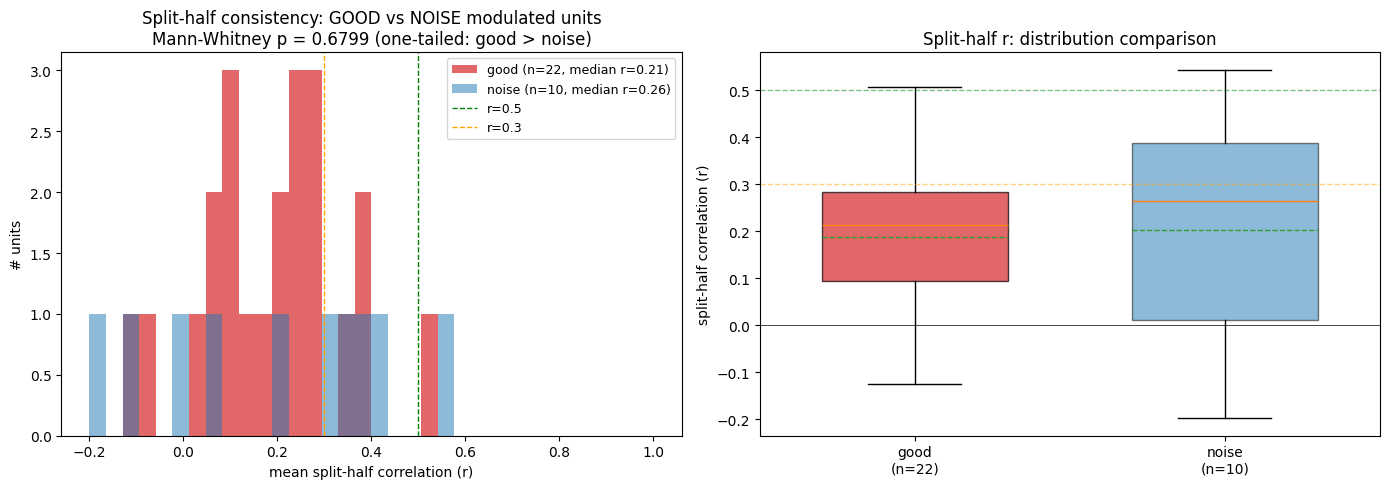

Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment2_recording1_analysis\qc\splithalf_good_vs_noise_in_trial.png

===== INTERPRETATION =====
  Good median r:  0.213
  Noise median r: 0.263
  Mann-Whitney p: 0.6799

  Good units > r=0.5:  1 / 22 (5%)
  Noise units > r=0.5: 1 / 10 (10%)

Reading the result:
  • If noise median r is high (> 0.4), noise modulations are reliable spiking →
    they're leaked real neurons that didn't pass your good-unit criterion.
    Your good-unit signal is still real biology, just not unique to good units.
  • If noise median r is near 0 (< 0.15), noise modulations are inconsistent →
    contamination/artifact, and you'd have a real problem.
  • Intermediate values (0.15-0.4) suggest a mix.

===== CELL O COMPLETE =====



In [29]:
# ============================================================
# CELL O — SPLIT-HALF CONSISTENCY: GOOD vs NOISE COMPARISON
# ============================================================
# Critical test: are noise-unit modulations driven by real spiking
# (high split-half r) or by trial-outlier noise / artifacts (low r)?
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr, mannwhitneyu

print("\n===== CELL O — SPLIT-HALF: GOOD vs NOISE =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SUBSET_NAME       = "in_trial"
WIN_PRE           = 2.0
WIN_POST          = 4.0
RESPONSE_WIN      = (-0.5, 2.0)
BIN_SIZE          = 0.020
SMOOTH_SIGMA_BINS = 2
N_HALF_SPLITS     = 100
RANDOM_SEED       = 42
# ------------------------------------------------------------

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# Load events
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
bout_onset_t  = bouts["onset_t"]
bout_trial_id = bouts["trial_id"]

if SUBSET_NAME == "in_trial":
    mask = bout_trial_id >= 0
elif SUBSET_NAME == "in_trial_first":
    mask = np.zeros(len(bout_onset_t), dtype=bool)
    for t_i in np.unique(bout_trial_id):
        if t_i == -1: continue
        ii = np.where(bout_trial_id == t_i)[0]
        mask[ii[np.argmin(bout_onset_t[ii])]] = True
else:
    raise ValueError(f"Implement {SUBSET_NAME}")

event_times = np.sort(bout_onset_t[mask])
n_events = len(event_times)
print(f"Subset: {SUBSET_NAME}, n_events = {n_events}")

# Load prior modulated unit sets from Cell M
prior_good_path  = analysis_folder / "qc" / f"reach_good_{SUBSET_NAME}_arrays.npz"
prior_noise_path = analysis_folder / "qc" / f"reach_noise_{SUBSET_NAME}_arrays.npz"

prior_good = np.load(prior_good_path)
prior_noise = np.load(prior_noise_path)

mod_good_units  = prior_good["units"][prior_good["modulated"]]
mod_noise_units = prior_noise["units"][prior_noise["modulated"]]
print(f"Modulated good units (from Cell M):  {len(mod_good_units)}")
print(f"Modulated noise units (from Cell M): {len(mod_noise_units)}")

# Load spike trains
spikes_dir = analysis_folder / "spikes"
good_spikes  = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in mod_good_units}
noise_spikes = {int(u): np.load(spikes_dir / f"noise_unit_{u}.npy") for u in mod_noise_units}

# Helpers
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])

def compute_psth_mean(units, spike_dict, events):
    psth = np.zeros((len(units), len(centers)))
    for u_i, u in enumerate(units):
        spk = spike_dict[int(u)]
        per_trial = np.zeros((len(events), len(centers)))
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            per_trial[e_i] = h / BIN_SIZE
        smooth = gaussian_filter1d(per_trial, sigma=SMOOTH_SIGMA_BINS, axis=1)
        psth[u_i] = smooth.mean(axis=0)
    return psth

def split_half_corr(units, spike_dict, rng):
    corrs = np.zeros((N_HALF_SPLITS, len(units)))
    for s in range(N_HALF_SPLITS):
        perm = rng.permutation(len(event_times))
        half = len(event_times) // 2
        h1 = np.sort(event_times[perm[:half]])
        h2 = np.sort(event_times[perm[half:half*2]])
        p1 = compute_psth_mean(units, spike_dict, h1)
        p2 = compute_psth_mean(units, spike_dict, h2)
        for u_i in range(len(units)):
            try:
                r, _ = pearsonr(p1[u_i, response_mask], p2[u_i, response_mask])
                corrs[s, u_i] = r
            except:
                corrs[s, u_i] = np.nan
        if (s+1) % 25 == 0:
            print(f"    {s+1}/{N_HALF_SPLITS}")
    return np.nanmean(corrs, axis=0)

print("\nComputing split-half correlations for GOOD modulated units...")
rng = np.random.default_rng(RANDOM_SEED)
good_corrs = split_half_corr(mod_good_units, good_spikes, rng)

print("\nComputing split-half correlations for NOISE modulated units...")
noise_corrs = split_half_corr(mod_noise_units, noise_spikes, rng)

# Mann-Whitney U test
try:
    u_stat, p_val = mannwhitneyu(good_corrs, noise_corrs, alternative="greater")
except:
    u_stat, p_val = np.nan, np.nan

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.linspace(-0.2, 1.0, 35)
ax.hist(good_corrs, bins=bins, color="C3", alpha=0.7,
        label=f"good (n={len(good_corrs)}, median r={np.median(good_corrs):.2f})")
ax.hist(noise_corrs, bins=bins, color="C0", alpha=0.5,
        label=f"noise (n={len(noise_corrs)}, median r={np.median(noise_corrs):.2f})")
ax.axvline(0.5, color="green", lw=1, linestyle="--", label="r=0.5")
ax.axvline(0.3, color="orange", lw=1, linestyle="--", label="r=0.3")
ax.set_xlabel("mean split-half correlation (r)")
ax.set_ylabel("# units")
ax.set_title(f"Split-half consistency: GOOD vs NOISE modulated units\n"
             f"Mann-Whitney p = {p_val:.4g} (one-tailed: good > noise)")
ax.legend(fontsize=9)

ax = axes[1]
data = [good_corrs, noise_corrs]
positions = [1, 2]
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=True)
bp["boxes"][0].set_facecolor("C3")
bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor("C0")
bp["boxes"][1].set_alpha(0.5)
ax.set_xticks([1, 2])
ax.set_xticklabels([f"good\n(n={len(good_corrs)})",
                    f"noise\n(n={len(noise_corrs)})"])
ax.set_ylabel("split-half correlation (r)")
ax.axhline(0.5, color="green", lw=1, linestyle="--", alpha=0.5)
ax.axhline(0.3, color="orange", lw=1, linestyle="--", alpha=0.5)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Split-half r: distribution comparison")

plt.tight_layout()
out_path = analysis_folder / "qc" / f"splithalf_good_vs_noise_{SUBSET_NAME}.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"splithalf_good_vs_noise_{SUBSET_NAME}_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
print("\n===== INTERPRETATION =====")
print(f"  Good median r:  {np.median(good_corrs):.3f}")
print(f"  Noise median r: {np.median(noise_corrs):.3f}")
print(f"  Mann-Whitney p: {p_val:.4g}")
print()
print(f"  Good units > r=0.5:  {int((good_corrs > 0.5).sum())} / {len(good_corrs)} "
      f"({100*(good_corrs>0.5).sum()/len(good_corrs):.0f}%)")
print(f"  Noise units > r=0.5: {int((noise_corrs > 0.5).sum())} / {len(noise_corrs)} "
      f"({100*(noise_corrs>0.5).sum()/len(noise_corrs):.0f}%)")
print()
print("Reading the result:")
print("  • If noise median r is high (> 0.4), noise modulations are reliable spiking →")
print("    they're leaked real neurons that didn't pass your good-unit criterion.")
print("    Your good-unit signal is still real biology, just not unique to good units.")
print("  • If noise median r is near 0 (< 0.15), noise modulations are inconsistent →")
print("    contamination/artifact, and you'd have a real problem.")
print("  • Intermediate values (0.15-0.4) suggest a mix.")
print()
print("===== CELL O COMPLETE =====\n")


===== CELL P — MULTI-EVENT CONTAMINATION DIAGNOSTIC =====
  reach_in_trial    : 106 events
  motor_expose      : 55 events
  motor_retract     : 55 events
  tone              : 55 events
  button            : 55 events

Eligible good units:  38
Eligible noise units: 38

Running all event × unit-type combinations...

  Event: reach_in_trial (n=106)
    Good units...
    36 / 38 modulated (Z>2.75)
    Noise units...
    20 / 38 modulated (Z>2.75)

  Event: motor_expose (n=55)
    Good units...
    12 / 38 modulated (Z>2.75)
    Noise units...
    12 / 38 modulated (Z>2.75)

  Event: motor_retract (n=55)
    Good units...
    21 / 38 modulated (Z>2.75)
    Noise units...
    12 / 38 modulated (Z>2.75)

  Event: tone (n=55)
    Good units...
    13 / 38 modulated (Z>2.75)
    Noise units...
    11 / 38 modulated (Z>2.75)

  Event: button (n=55)
    Good units...
    12 / 38 modulated (Z>2.75)
    Noise units...
    10 / 38 modulated (Z>2.75)


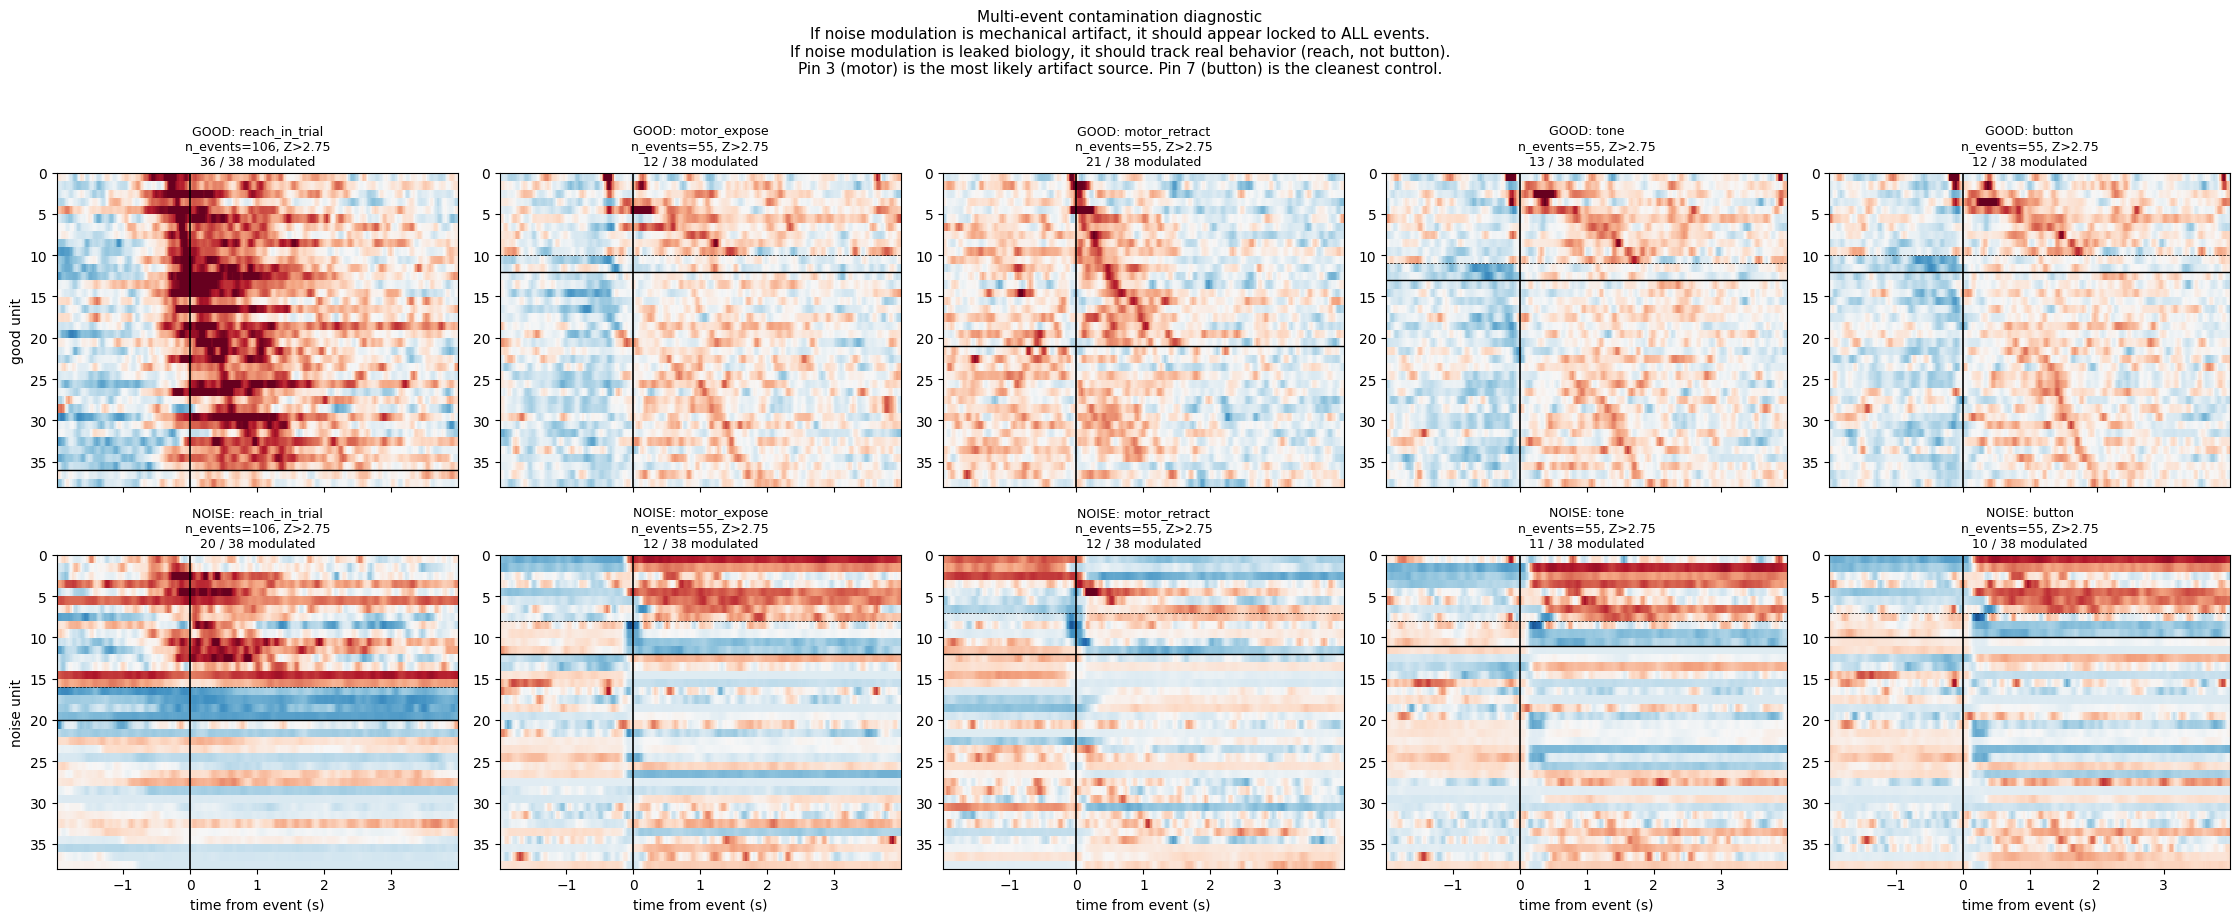


Saved → G:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis\qc\multi_event_contamination.png

===== SUMMARY TABLE =====
Event                Good_mod   Good_pct   Noise_mod   Noise_pct
----------------------------------------------------------------------
reach_in_trial             36      94.7%          20       52.6%
motor_expose               12      31.6%          12       31.6%
motor_retract              21      55.3%          12       31.6%
tone                       13      34.2%          11       28.9%
button                     12      31.6%          10       26.3%

===== SPIKE-LOSS ARTIFACT DETECTOR =====
Event               Good_silenced   Good_pct  Noise_silenced  Noise_pct
---------------------------------------------------------------------------
reach_in_trial                  0       0.0%               0       0.0%
motor_expose                    0       0.0%               4      10.5%
motor_retract                   0      

In [19]:
# ============================================================
# CELL P — MULTI-EVENT CONTAMINATION DIAGNOSTIC
# ============================================================
# Tests whether noise-unit modulation is reach-specific (suggesting
# leaked biology) or event-agnostic (suggesting mechanical/electrical
# contamination from any TTL event).
#
# Compares good vs noise modulation across:
#   - reach bouts (in_trial)
#   - pin 3 (motor turn — biggest potential artifact source)
#   - pin 4 (tone — purely auditory, minimal mechanical)
#   - pin 7 (button press — clean event, no mechanical rig motion)
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL P — MULTI-EVENT CONTAMINATION DIAGNOSTIC =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
WIN_PRE            = 2.0
WIN_POST           = 4.0
RESPONSE_WIN       = (-0.5, 2.0)
BIN_SIZE           = 0.020
SMOOTH_SIGMA_BINS  = 2
MIN_CONSECUTIVE_MS = 100
MIN_BASELINE_HZ    = 1.0
N_SHUFFLES_CALIB   = 200
TARGET_FPR         = 0.05
RANDOM_SEED        = 42
# ------------------------------------------------------------

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# DEFINE EVENT TYPES
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
bout_onset_t = bouts["onset_t"]
bout_trial_id = bouts["trial_id"]

# Pin 3 events (motor) — split into expose-only (odd-indexed) since both
# turns produce same mechanical signature
pin3 = np.load(ttls_dir / "TTL_Pin_3.npy")
if len(pin3) % 2 != 0:
    pin3 = pin3[:-1]
motor_expose = pin3[0::2]   # 48 events, mechanical onset
motor_retract = pin3[1::2]  # 48 events, also mechanical
pin4 = np.load(ttls_dir / "TTL_Pin_4.npy")  # tone
pin7 = np.load(ttls_dir / "TTL_Pin_7.npy")  # button

event_sets = {
    "reach_in_trial":  bout_onset_t[bout_trial_id >= 0],
    "motor_expose":    motor_expose,
    "motor_retract":   motor_retract,
    "tone":            pin4,
    "button":          pin7,
}
for name, evts in event_sets.items():
    event_sets[name] = np.sort(evts)
    print(f"  {name:<18}: {len(evts)} events")

# ------------------------------------------------------------
# LOAD UNITS
# ------------------------------------------------------------
good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"
good_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}
unit_rates = np.array([len(good_spikes[int(u)]) / recording_duration
                       for u in good_units])
eligible_good = good_units[unit_rates >= MIN_BASELINE_HZ]

noise_units_all = np.load(analysis_folder / "qc" / "noise_units.npy")
noise_spikes = {int(u): np.load(spikes_dir / f"noise_unit_{u}.npy") for u in noise_units_all}
n_noise_rates = np.array([len(noise_spikes[int(u)]) / recording_duration
                          for u in noise_units_all])
eligible_noise = noise_units_all[n_noise_rates >= MIN_BASELINE_HZ]
print(f"\nEligible good units:  {len(eligible_good)}")
print(f"Eligible noise units: {len(eligible_noise)}")

# ------------------------------------------------------------
# SHARED COMPUTATION
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2
n_bins = len(centers)
response_mask = (centers >= RESPONSE_WIN[0]) & (centers < RESPONSE_WIN[1])
min_consec_bins = int(np.ceil(MIN_CONSECUTIVE_MS / 1000.0 / BIN_SIZE))

t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0

def compute_psth_mean(units, spike_dict, events):
    psth = np.zeros((len(units), n_bins))
    for u_i, u in enumerate(units):
        spk = spike_dict[int(u)]
        per_trial = np.zeros((len(events), n_bins))
        for e_i, t_evt in enumerate(events):
            rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
            h, _ = np.histogram(rel, bins=edges)
            per_trial[e_i] = h / BIN_SIZE
        smooth = gaussian_filter1d(per_trial, sigma=SMOOTH_SIGMA_BINS, axis=1)
        psth[u_i] = smooth.mean(axis=0)
    return psth

def count_modulated(z_mat, z_thresh):
    z_resp = z_mat[:, response_mask]
    out = np.zeros(z_resp.shape[0], dtype=bool)
    for i in range(z_resp.shape[0]):
        for arr in (z_resp[i] > z_thresh, z_resp[i] < -z_thresh):
            if not arr.any():
                continue
            padded = np.concatenate([[False], arr, [False]])
            d = np.diff(padded.astype(int))
            s = np.where(d == 1)[0]
            e = np.where(d == -1)[0]
            if (e - s).max() >= min_consec_bins:
                out[i] = True
                break
    return out

def run_event_unit_combo(units, spike_dict, events, rng):
    n_events = len(events)
    shuffled_psths = np.zeros((N_SHUFFLES_CALIB, len(units), n_bins))
    for s in range(N_SHUFFLES_CALIB):
        fake = rng.uniform(t_min, t_max, size=n_events)
        fake.sort()
        shuffled_psths[s] = compute_psth_mean(units, spike_dict, fake)
    null_mean = shuffled_psths.mean(axis=0)
    null_std = shuffled_psths.std(axis=0)
    null_std = np.maximum(null_std, null_mean * 0.01 + 0.1)

    z_grid = np.arange(2.0, 6.01, 0.25)
    fpr = np.zeros((N_SHUFFLES_CALIB, len(z_grid)))
    for s in range(N_SHUFFLES_CALIB):
        z_s = (shuffled_psths[s] - null_mean) / null_std
        for j, thr in enumerate(z_grid):
            fpr[s, j] = count_modulated(z_s, thr).sum() / len(units)
    mean_fpr = fpr.mean(axis=0)
    viable = np.where(mean_fpr <= TARGET_FPR)[0]
    z_chosen = float(z_grid[viable[0]]) if len(viable) else float(z_grid[-1])

    real_mean = compute_psth_mean(units, spike_dict, events)
    real_z = (real_mean - null_mean) / null_std
    mod = count_modulated(real_z, z_chosen)

    z_resp = real_z[:, response_mask]
    response_centers = centers[response_mask]
    peak_idx = np.argmax(np.abs(z_resp), axis=1)
    peak_lat = response_centers[peak_idx]
    peak_z = z_resp[np.arange(len(units)), peak_idx]

    return {
        "n_events": int(n_events),
        "real_z": real_z,
        "modulated": mod,
        "n_modulated": int(mod.sum()),
        "z_threshold": z_chosen,
        "peak_latency": peak_lat,
        "peak_z": peak_z,
    }

# ------------------------------------------------------------
# RUN ALL EVENT × UNIT-TYPE COMBINATIONS
# ------------------------------------------------------------
print("\nRunning all event × unit-type combinations...")
results = {}
rng = np.random.default_rng(RANDOM_SEED)
for ev_name, events in event_sets.items():
    print(f"\n  Event: {ev_name} (n={len(events)})")
    print(f"    Good units...")
    rng_g = np.random.default_rng(RANDOM_SEED)
    results[(ev_name, "good")] = run_event_unit_combo(
        eligible_good, good_spikes, events, rng_g)
    print(f"    {results[(ev_name, 'good')]['n_modulated']} / {len(eligible_good)} "
          f"modulated (Z>{results[(ev_name, 'good')]['z_threshold']:.2f})")
    print(f"    Noise units...")
    rng_n = np.random.default_rng(RANDOM_SEED)
    results[(ev_name, "noise")] = run_event_unit_combo(
        eligible_noise, noise_spikes, events, rng_n)
    print(f"    {results[(ev_name, 'noise')]['n_modulated']} / {len(eligible_noise)} "
          f"modulated (Z>{results[(ev_name, 'noise')]['z_threshold']:.2f})")

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, axes = plt.subplots(2, len(event_sets),
                          figsize=(4.5 * len(event_sets), 9),
                          sharex=True)

def sort_by_modulation(res):
    mod, pz, pl = res["modulated"], res["peak_z"], res["peak_latency"]
    final_idx = np.where(mod)[0]
    exc = final_idx[pz[final_idx] > 0][np.argsort(pl[final_idx[pz[final_idx] > 0]])]
    sup = final_idx[pz[final_idx] < 0][np.argsort(pl[final_idx[pz[final_idx] < 0]])]
    nonmod = np.where(~mod)[0]
    nonmod = nonmod[np.argsort(pl[nonmod])]
    return np.concatenate([exc, sup, nonmod]), len(exc), len(exc) + len(sup)

all_z = np.concatenate([results[(e, "good")]["real_z"].ravel()
                        for e in event_sets])
vmax = max(3.0, np.percentile(np.abs(all_z), 99))

for col, ev_name in enumerate(event_sets):
    for row, unit_type in enumerate(["good", "noise"]):
        res = results[(ev_name, unit_type)]
        order, n_exc, n_mod = sort_by_modulation(res)
        ax = axes[row, col]
        n_units_here = res["real_z"].shape[0]
        ax.imshow(res["real_z"][order], aspect="auto",
                  extent=[centers[0], centers[-1], n_units_here, 0],
                  cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                  interpolation="nearest")
        ax.axvline(0, color="black", lw=1.2)
        if n_exc:
            ax.axhline(n_exc, color="black", lw=0.5, linestyle="--")
        ax.axhline(n_mod, color="black", lw=1.0)
        title = f"{unit_type.upper()}: {ev_name}\n"
        title += f"n_events={res['n_events']}, Z>{res['z_threshold']:.2f}\n"
        title += f"{res['n_modulated']} / {n_units_here} modulated"
        ax.set_title(title, fontsize=9)
        if col == 0:
            ax.set_ylabel(f"{unit_type} unit")
        if row == 1:
            ax.set_xlabel("time from event (s)")

plt.suptitle(
    "Multi-event contamination diagnostic\n"
    "If noise modulation is mechanical artifact, it should appear locked to ALL events.\n"
    "If noise modulation is leaked biology, it should track real behavior (reach, not button).\n"
    "Pin 3 (motor) is the most likely artifact source. Pin 7 (button) is the cleanest control.",
    fontsize=11, y=1.02
)
plt.tight_layout()

out_path = analysis_folder / "qc" / "multi_event_contamination.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"multi_event_contamination_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out_path}")

# ------------------------------------------------------------
# SUMMARY TABLE + INTERPRETATION
# ------------------------------------------------------------
print("\n===== SUMMARY TABLE =====")
print(f"{'Event':<18} {'Good_mod':>10} {'Good_pct':>10} {'Noise_mod':>11} {'Noise_pct':>11}")
print("-" * 70)
for ev_name in event_sets:
    rg = results[(ev_name, "good")]
    rn = results[(ev_name, "noise")]
    gpct = 100 * rg["n_modulated"] / rg["real_z"].shape[0]
    npct = 100 * rn["n_modulated"] / rn["real_z"].shape[0]
    print(f"{ev_name:<18} {rg['n_modulated']:>10d} {gpct:>9.1f}% "
          f"{rn['n_modulated']:>11d} {npct:>10.1f}%")

# ------------------------------------------------------------
# SPIKE-LOSS DETECTOR: which units show sharp t=0 silencing?
# ------------------------------------------------------------
# A spike-loss artifact looks like: brief, deep z dip centered at t=0,
# regardless of any other temporal structure. This is distinct from
# biological suppression (which has gradual onset, deeper troughs,
# and sustained time courses).
# ------------------------------------------------------------
print("\n===== SPIKE-LOSS ARTIFACT DETECTOR =====")

# Bins within ±100 ms of t=0
silence_win = (centers >= -0.10) & (centers <= 0.10)
# Bins for "elsewhere" — used to compare relative deflection
elsewhere_win = (centers >= 0.5) & (centers <= 2.0)

print(f"{'Event':<18} {'Good_silenced':>14} {'Good_pct':>10} "
      f"{'Noise_silenced':>15} {'Noise_pct':>10}")
print("-" * 75)

for ev_name in event_sets:
    for unit_type, n_units_here in [("good", len(eligible_good)),
                                    ("noise", len(eligible_noise))]:
        res = results[(ev_name, unit_type)]
        z = res["real_z"]
        # Mean z within ±100ms of t=0
        z_silence = z[:, silence_win].mean(axis=1)
        z_elsewhere = z[:, elsewhere_win].mean(axis=1)
        # "Silenced" = z<-2 in silence window AND |z|<2 elsewhere
        # This catches units with sharp drops only at t=0
        silenced = (z_silence < -2.0) & (np.abs(z_elsewhere) < 2.0)
        if unit_type == "good":
            good_silenced_n = int(silenced.sum())
            good_silenced_pct = 100 * silenced.sum() / n_units_here
        else:
            noise_silenced_n = int(silenced.sum())
            noise_silenced_pct = 100 * silenced.sum() / n_units_here
    print(f"{ev_name:<18} {good_silenced_n:>14d} {good_silenced_pct:>9.1f}% "
          f"{noise_silenced_n:>15d} {noise_silenced_pct:>9.1f}%")

print("\nInterpretation of silencing pattern:")
print("  • If many noise units are 'silenced' at pin 3 (motor) but few are silenced")
print("    at pin 7 (button), the motor mechanically blanks spike detection.")
print("  • If silencing is uniform across all events, it's a generic TTL artifact.")
print("  • If silencing happens only on noise units (not good), good-unit signal is")
print("    relatively protected — these are noise clusters that crash during artifacts.")
print("  • If silencing happens on BOTH good and noise units, real units are also")
print("    losing spikes during the artifact window — you can't fully trust their")
print("    suppressed responses in those windows.")


print("\n===== INTERPRETATION =====")
print("If noise modulation is CONTAMINATION:")
print("  - Noise pct should be similar across pin 3 (motor) and reach (overlap in time)")
print("  - Noise pct should be highest at pin 3 (raw mechanical event)")
print("  - Noise pct should be LOW at pin 7 (button) — no mechanical event")
print("  - Noise pct should be LOW at tone — pure audio")
print("")
print("If noise modulation is LEAKED BIOLOGY:")
print("  - Noise should track reach modulation specifically")
print("  - Noise should also be high at pin 3 (motor = pellet appears = reaches start)")
print("  - But noise should be LOWER for tone-only and button-only events")
print("")
print("Key diagnostic: compare noise modulation at pin 3 (motor) vs pin 7 (button)")
print("Same animal, same recording, but different physical events.")

print("\n===== CELL P COMPLETE =====\n")


===== CELL S — CONTAMINATION FILTER =====
Starting modulated units: 36 / 38

Contaminated excited units removed: 1

Removal criteria:
  - peak_z > 0 (i.e., 'excited' classification)
  - z_min in ±100ms of t=0 < -2.0
  - recovery to half-baseline < 200ms

Contaminated units (sample, top 10 by silence depth):
  unit  337: peak_z=  6.19 at   610ms, silence_z= -2.86, recovery=  140ms

===== FINAL MODULATED SET =====
  Originally modulated:        36
  Removed as contaminated:     1
  Final clean modulated:       35
    - Excited:                 35
    - Suppressed:              0

Saved → final_reach_modulated_units_in_trial.npz


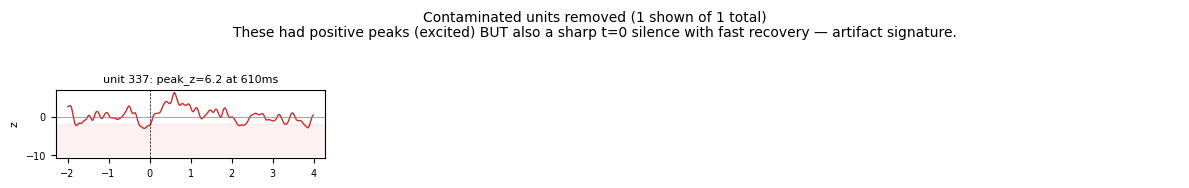

Saved diagnostic → contaminated_excited_units_in_trial.png

===== CELL S COMPLETE =====



In [20]:
# ============================================================
# CELL S — CONTAMINATION FILTER FOR REACH-MODULATED UNITS
# ============================================================
# Removes reach-modulated good units showing the spike-loss artifact
# signature (sharp brief silencing right at t=0 with fast recovery,
# matching the noise-unit contamination pattern).
#
# Produces final_reach_modulated_units.npy for downstream analyses.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL S — CONTAMINATION FILTER =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SUBSET_NAME = "in_trial"
# Contamination criterion (matched to noise-unit signature):
SILENCE_WIN_MS = (-100, 100)   # window for detecting sharp silencing
SILENCE_Z_THRESH = -2.0         # how deep must the silencing be
RECOVERY_FAST_THRESH_S = 0.20   # fast recovery indicates artifact
# Cells silenced this fast with this strong a dip are flagged.
# Combined with peak excitation elsewhere = "contaminated excited unit"
# ------------------------------------------------------------

# Load Cell M results
results_path = analysis_folder / "qc" / f"reach_good_{SUBSET_NAME}_arrays.npz"
data = np.load(results_path)

units = data["units"]
z_mat = data["z_mean"]
modulated = data["modulated"]
peak_z = data["peak_z"]
peak_latency = data["peak_latency"]
centers = data["centers"]

print(f"Starting modulated units: {modulated.sum()} / {len(units)}")

# ------------------------------------------------------------
# COMPUTE CONTAMINATION SIGNATURE FOR EACH MODULATED UNIT
# ------------------------------------------------------------
silence_win_s = (SILENCE_WIN_MS[0] / 1000, SILENCE_WIN_MS[1] / 1000)
silence_mask = (centers >= silence_win_s[0]) & (centers <= silence_win_s[1])

modulated_idx = np.where(modulated)[0]

contamination_metrics = []
for i in modulated_idx:
    z_trace = z_mat[i]
    # Minimum z in silence window
    z_min_silence = z_trace[silence_mask].min()
    trough_idx_local = np.argmin(z_trace[silence_mask])
    trough_idx_global = np.where(silence_mask)[0][trough_idx_local]

    # Recovery: time from trough to half-recovery toward baseline
    post_trace = z_trace[trough_idx_global:]
    post_centers = centers[trough_idx_global:]
    half_recovery = z_min_silence / 2  # halfway back to 0
    above_half = np.where(post_trace >= half_recovery)[0]
    if len(above_half) > 0:
        recovery_s = post_centers[above_half[0]] - post_centers[0]
    else:
        recovery_s = post_centers[-1] - post_centers[0]

    contamination_metrics.append({
        "z_min_silence": z_min_silence,
        "recovery_s": recovery_s,
    })

# ------------------------------------------------------------
# APPLY FILTER
# ------------------------------------------------------------
# An excited unit is "contaminated" if it has BOTH:
#   - Strong positive peak (peak_z > 0, which is what makes it "excited")
#   - Artifact-shaped silencing (sharp dip and fast recovery)
# A suppressed unit (peak_z < 0) is treated separately — we don't filter
# these because the suppressed good units passed kinetic analysis (Cell R)
# already showing they're biological.
# ------------------------------------------------------------

contaminated_flag = np.zeros(len(units), dtype=bool)
contamination_reason = []

for i_local, i_global in enumerate(modulated_idx):
    cm = contamination_metrics[i_local]
    is_excited = peak_z[i_global] > 0
    has_artifact_silence = (
        cm["z_min_silence"] < SILENCE_Z_THRESH
        and cm["recovery_s"] < RECOVERY_FAST_THRESH_S
    )
    if is_excited and has_artifact_silence:
        contaminated_flag[i_global] = True
        contamination_reason.append({
            "unit": int(units[i_global]),
            "peak_z": float(peak_z[i_global]),
            "peak_latency": float(peak_latency[i_global]),
            "silence_z": float(cm["z_min_silence"]),
            "recovery_s": float(cm["recovery_s"]),
        })

n_contam = int(contaminated_flag.sum())
print(f"\nContaminated excited units removed: {n_contam}")
print(f"\nRemoval criteria:")
print(f"  - peak_z > 0 (i.e., 'excited' classification)")
print(f"  - z_min in ±{abs(SILENCE_WIN_MS[0])}ms of t=0 < {SILENCE_Z_THRESH}")
print(f"  - recovery to half-baseline < {RECOVERY_FAST_THRESH_S * 1000:.0f}ms")

print(f"\nContaminated units (sample, top 10 by silence depth):")
contamination_reason_sorted = sorted(contamination_reason,
                                     key=lambda x: x["silence_z"])
for r in contamination_reason_sorted[:10]:
    print(f"  unit {r['unit']:>4}: peak_z={r['peak_z']:>6.2f} at "
          f"{r['peak_latency']*1000:>5.0f}ms, silence_z={r['silence_z']:>6.2f}, "
          f"recovery={r['recovery_s']*1000:>5.0f}ms")

# ------------------------------------------------------------
# BUILD FINAL CLEAN MODULATED SET
# ------------------------------------------------------------
final_modulated = modulated & ~contaminated_flag
final_units = units[final_modulated]

n_final = int(final_modulated.sum())
n_excited_final = int(final_modulated.sum() & (peak_z[final_modulated] > 0).sum())
# Recount cleanly
final_excited_mask = final_modulated & (peak_z > 0)
final_suppressed_mask = final_modulated & (peak_z < 0)
n_final_excited = int(final_excited_mask.sum())
n_final_suppressed = int(final_suppressed_mask.sum())

print(f"\n===== FINAL MODULATED SET =====")
print(f"  Originally modulated:        {modulated.sum()}")
print(f"  Removed as contaminated:     {n_contam}")
print(f"  Final clean modulated:       {n_final}")
print(f"    - Excited:                 {n_final_excited}")
print(f"    - Suppressed:              {n_final_suppressed}")

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
out_path = analysis_folder / "qc" / f"final_reach_modulated_units_{SUBSET_NAME}.npz"
np.savez(out_path,
         units=units,                    # all eligible
         modulated=final_modulated,      # boolean mask (final clean)
         peak_z=peak_z,
         peak_latency=peak_latency,
         z_mean=z_mat,
         centers=centers,
         contaminated_flag=contaminated_flag,
         excited_mask=final_excited_mask,
         suppressed_mask=final_suppressed_mask)
with open(analysis_folder / "qc" / f"final_modulated_summary_{SUBSET_NAME}.json", "w") as f:
    json.dump({
        "n_eligible": int(len(units)),
        "n_initial_modulated": int(modulated.sum()),
        "n_contaminated_removed": int(n_contam),
        "n_final_modulated": int(n_final),
        "n_final_excited": int(n_final_excited),
        "n_final_suppressed": int(n_final_suppressed),
        "contaminated_units": [r["unit"] for r in contamination_reason_sorted],
    }, f, indent=2)
print(f"\nSaved → {out_path.name}")

# ------------------------------------------------------------
# DIAGNOSTIC: show some contaminated unit PSTHs
# ------------------------------------------------------------
if n_contam > 0:
    n_show = min(12, n_contam)
    contaminated_idx_global = np.where(contaminated_flag)[0][:n_show]
    ncols = 4
    nrows = int(np.ceil(n_show / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 1.8 * nrows),
                             sharex=True)
    axes = axes.ravel() if nrows > 1 else axes
    for i, gi in enumerate(contaminated_idx_global):
        ax = axes[i]
        ax.plot(centers, z_mat[gi], color="C3", lw=1.0)
        ax.axvline(0, color="black", lw=0.5, linestyle="--")
        ax.axhline(0, color="gray", lw=0.5)
        ax.axhspan(SILENCE_Z_THRESH, -10, color="red", alpha=0.05)
        ax.set_title(f"unit {int(units[gi])}: peak_z={peak_z[gi]:.1f} at "
                     f"{peak_latency[gi]*1000:.0f}ms",
                     fontsize=8)
        ax.tick_params(labelsize=7)
        if i % ncols == 0:
            ax.set_ylabel("z", fontsize=8)
    for j in range(n_show, len(axes)):
        axes[j].axis("off")
    fig.suptitle(
        f"Contaminated units removed ({n_show} shown of {n_contam} total)\n"
        f"These had positive peaks (excited) BUT also a sharp t=0 silence "
        f"with fast recovery — artifact signature.",
        fontsize=10, y=1.02
    )
    plt.tight_layout()
    out_fig = analysis_folder / "qc" / f"contaminated_excited_units_{SUBSET_NAME}.png"
    j = 1
    while out_fig.exists():
        out_fig = analysis_folder / "qc" / f"contaminated_excited_units_{SUBSET_NAME}_{j}.png"
        j += 1
    fig.savefig(out_fig, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved diagnostic → {out_fig.name}")

print("\n===== CELL S COMPLETE =====\n")


===== CELL T — MODULATION OVERVIEW PLOTS =====
Final modulated: 35 (excited: 35, suppressed: 0)


C:\Users\kkost\AppData\Local\Temp\ipykernel_1804\1110186232.py:83: RuntimeWarning: Mean of empty slice.
  mean_sup = sup_z.mean(axis=0)
C:\ProgramData\anaconda3\envs\spikeinterface_env_vid\lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\ProgramData\anaconda3\envs\spikeinterface_env_vid\lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\ProgramData\anaconda3\envs\spikeinterface_env_vid\lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\ProgramData\anaconda3\envs\spikeinterface_env_vid\lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\kkost\AppData\Local\Temp\ipykernel_1804\1110186232.py:122: UserWarning: This figure inc

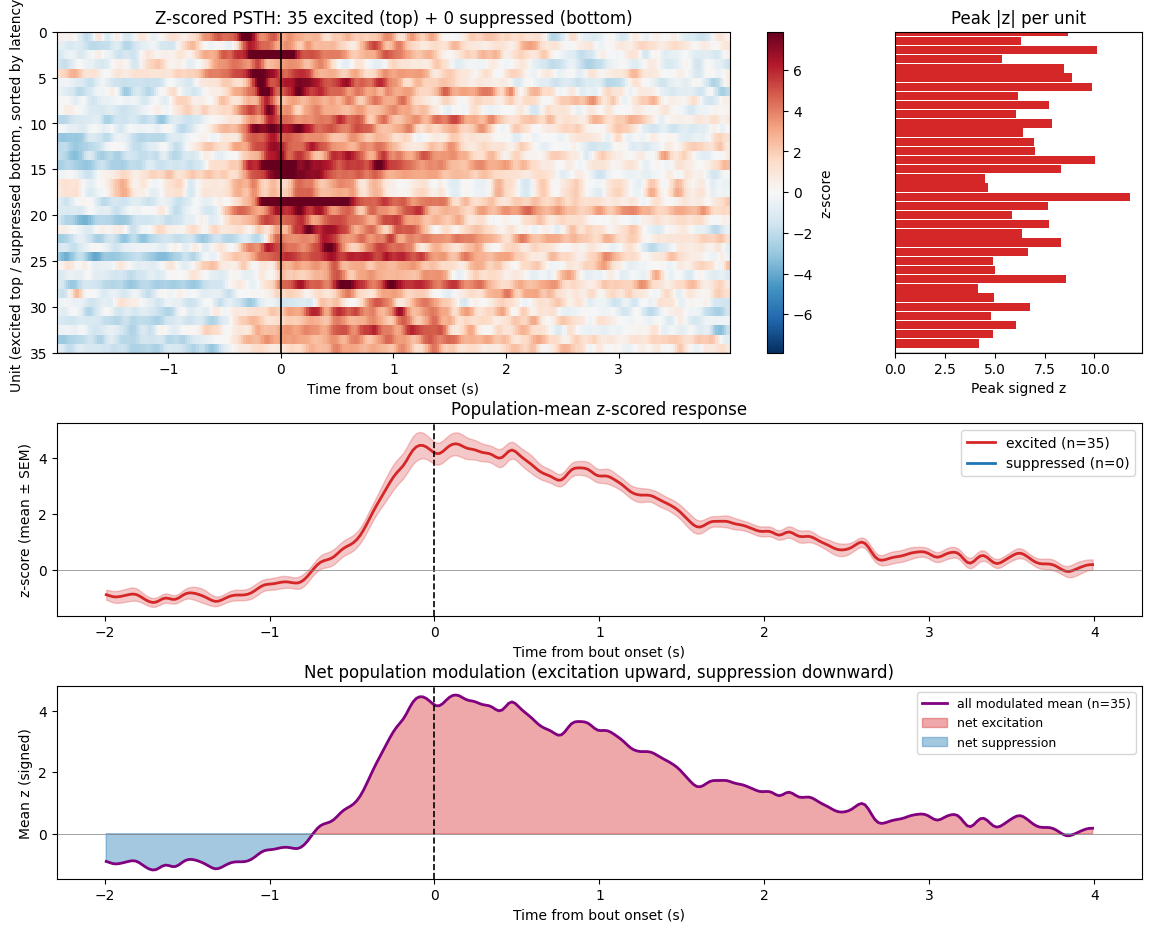

Saved → modulation_overview_in_trial.png


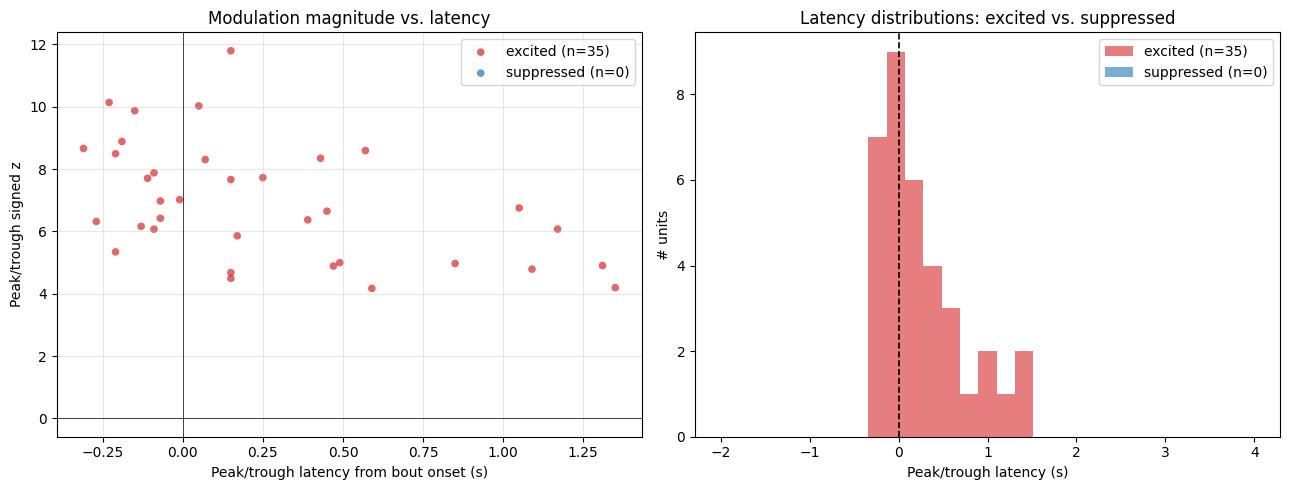

Saved → modulation_scatter_in_trial.png

===== POPULATION SUMMARY =====
  Excited units:    35
    median peak latency: 150 ms
    median peak z:       6.65
  Suppressed units: 0
    median trough latency: nan ms
    median trough z:        nan

===== CELL T COMPLETE =====



C:\ProgramData\anaconda3\envs\spikeinterface_env_vid\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\envs\spikeinterface_env_vid\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [21]:
# ============================================================
# CELL T — MODULATION OVERVIEW PLOTS (CLEAN POPULATION)
# ============================================================
# Visualizations of the final reach-modulated population:
#   1. Signed heatmap: excited (top, sorted by peak latency) +
#      suppressed (bottom, sorted by trough latency)
#   2. Population-average traces: excited mean ± SEM, suppressed
#      mean ± SEM, signed combined.
#   3. Scatter: peak/trough z vs. peak/trough latency, colored by sign.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\n===== CELL T — MODULATION OVERVIEW PLOTS =====")

SUBSET_NAME = "in_trial"

# Load final modulated set
final_path = analysis_folder / "qc" / f"final_reach_modulated_units_{SUBSET_NAME}.npz"
d = np.load(final_path)

units            = d["units"]
modulated        = d["modulated"]
peak_z           = d["peak_z"]
peak_latency     = d["peak_latency"]
z_mat            = d["z_mean"]
centers          = d["centers"]
excited_mask     = d["excited_mask"]
suppressed_mask  = d["suppressed_mask"]

print(f"Final modulated: {modulated.sum()} "
      f"(excited: {excited_mask.sum()}, suppressed: {suppressed_mask.sum()})")

# Sort excited by ascending peak latency, suppressed by ascending trough latency
exc_idx = np.where(excited_mask)[0]
sup_idx = np.where(suppressed_mask)[0]
exc_order = exc_idx[np.argsort(peak_latency[exc_idx])]
sup_order = sup_idx[np.argsort(peak_latency[sup_idx])]

# ------------------------------------------------------------
# FIGURE 1: SIGNED HEATMAP + POPULATION MEANS
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 11))
gs = fig.add_gridspec(3, 2, width_ratios=[3, 1], height_ratios=[2.5, 1.5, 1.5],
                      hspace=0.3, wspace=0.2)

# (1) Heatmap — excited stacked above suppressed
ax_hm = fig.add_subplot(gs[0, 0])
sort_full = np.concatenate([exc_order, sup_order])
vmax = max(3.0, np.percentile(np.abs(z_mat[sort_full]), 99))
im = ax_hm.imshow(z_mat[sort_full], aspect="auto",
                  extent=[centers[0], centers[-1], len(sort_full), 0],
                  cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
ax_hm.axvline(0, color="black", lw=1.2)
ax_hm.axhline(len(exc_order), color="black", lw=1.0)
ax_hm.set_ylabel("Unit (excited top / suppressed bottom, sorted by latency)")
ax_hm.set_xlabel("Time from bout onset (s)")
ax_hm.set_title(f"Z-scored PSTH: {len(exc_order)} excited (top) + "
                f"{len(sup_order)} suppressed (bottom)")
plt.colorbar(im, ax=ax_hm, label="z-score", fraction=0.04)

# (2) Sidebar: peak |z|
ax_sz = fig.add_subplot(gs[0, 1])
y = np.arange(len(sort_full))
pz_sorted = peak_z[sort_full]
colors = ["C3" if z > 0 else "C0" for z in pz_sorted]
ax_sz.barh(y, pz_sorted, color=colors, height=0.9)
ax_sz.axhline(len(exc_order), color="black", lw=1.0)
ax_sz.axvline(0, color="gray", lw=0.5)
ax_sz.set_ylim(len(sort_full), 0)
ax_sz.set_xlabel("Peak signed z")
ax_sz.set_yticks([])
ax_sz.set_title("Peak |z| per unit")

# (3) Population-mean excited trace (red)
ax_pop = fig.add_subplot(gs[1, :])
exc_z = z_mat[exc_idx]
sup_z = z_mat[sup_idx]
mean_exc = exc_z.mean(axis=0)
sem_exc = exc_z.std(axis=0) / np.sqrt(len(exc_z))
mean_sup = sup_z.mean(axis=0)
sem_sup = sup_z.std(axis=0) / np.sqrt(len(sup_z))

ax_pop.plot(centers, mean_exc, color="C3", lw=2,
            label=f"excited (n={len(exc_idx)})")
ax_pop.fill_between(centers, mean_exc - sem_exc, mean_exc + sem_exc,
                    color="C3", alpha=0.25)
ax_pop.plot(centers, mean_sup, color="C0", lw=2,
            label=f"suppressed (n={len(sup_idx)})")
ax_pop.fill_between(centers, mean_sup - sem_sup, mean_sup + sem_sup,
                    color="C0", alpha=0.25)
ax_pop.axvline(0, color="black", lw=1.2, linestyle="--")
ax_pop.axhline(0, color="gray", lw=0.5)
ax_pop.set_xlabel("Time from bout onset (s)")
ax_pop.set_ylabel("z-score (mean ± SEM)")
ax_pop.set_title("Population-mean z-scored response")
ax_pop.legend(loc="upper right", fontsize=10)

# (4) Combined directional plot — excited up, suppressed down (signed)
ax_combo = fig.add_subplot(gs[2, :], sharex=ax_pop)
# Signed mean: excited contributes positive, suppressed contributes negative
all_z = z_mat[modulated]
signed_mean = all_z.mean(axis=0)
ax_combo.plot(centers, signed_mean, color="purple", lw=2,
              label=f"all modulated mean (n={modulated.sum()})")
ax_combo.fill_between(centers, signed_mean, 0,
                      where=signed_mean > 0, color="C3", alpha=0.4,
                      interpolate=True, label="net excitation")
ax_combo.fill_between(centers, signed_mean, 0,
                      where=signed_mean < 0, color="C0", alpha=0.4,
                      interpolate=True, label="net suppression")
ax_combo.axvline(0, color="black", lw=1.2, linestyle="--")
ax_combo.axhline(0, color="gray", lw=0.5)
ax_combo.set_xlabel("Time from bout onset (s)")
ax_combo.set_ylabel("Mean z (signed)")
ax_combo.set_title("Net population modulation (excitation upward, "
                   "suppression downward)")
ax_combo.legend(loc="upper right", fontsize=9)

plt.tight_layout()
out_path = analysis_folder / "qc" / f"modulation_overview_{SUBSET_NAME}.png"
j = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"modulation_overview_{SUBSET_NAME}_{j}.png"
    j += 1
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path.name}")

# ------------------------------------------------------------
# FIGURE 2: SCATTER PLOT — latency × magnitude × sign
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Latency vs. peak signed z
ax = axes[0]
ax.scatter(peak_latency[exc_idx], peak_z[exc_idx],
           color="C3", s=30, alpha=0.7, label=f"excited (n={len(exc_idx)})",
           edgecolor="none")
ax.scatter(peak_latency[sup_idx], peak_z[sup_idx],
           color="C0", s=30, alpha=0.7, label=f"suppressed (n={len(sup_idx)})",
           edgecolor="none")
ax.axhline(0, color="black", lw=0.5)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Peak/trough latency from bout onset (s)")
ax.set_ylabel("Peak/trough signed z")
ax.set_title("Modulation magnitude vs. latency")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Histogram of peak latency for excited and suppressed
ax = axes[1]
bins = np.linspace(centers[0], centers[-1], 30)
ax.hist(peak_latency[exc_idx], bins=bins, color="C3", alpha=0.6,
        label=f"excited (n={len(exc_idx)})")
ax.hist(peak_latency[sup_idx], bins=bins, color="C0", alpha=0.6,
        label=f"suppressed (n={len(sup_idx)})")
ax.axvline(0, color="black", lw=1.2, linestyle="--")
ax.set_xlabel("Peak/trough latency (s)")
ax.set_ylabel("# units")
ax.set_title("Latency distributions: excited vs. suppressed")
ax.legend(fontsize=10)

plt.tight_layout()
out_path = analysis_folder / "qc" / f"modulation_scatter_{SUBSET_NAME}.png"
j = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"modulation_scatter_{SUBSET_NAME}_{j}.png"
    j += 1
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path.name}")

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
print("\n===== POPULATION SUMMARY =====")
print(f"  Excited units:    {len(exc_idx)}")
print(f"    median peak latency: {np.median(peak_latency[exc_idx])*1000:.0f} ms")
print(f"    median peak z:       {np.median(peak_z[exc_idx]):.2f}")
print(f"  Suppressed units: {len(sup_idx)}")
print(f"    median trough latency: {np.median(peak_latency[sup_idx])*1000:.0f} ms")
print(f"    median trough z:        {np.median(peak_z[sup_idx]):.2f}")

print("\n===== CELL T COMPLETE =====\n")


===== CELL U — EXEMPLAR UNIT PSTH + RASTER PLOTS (v2) =====
Top excited units:    [288, 430, 197, 276, 32, 416, 181, 425, 312, 259, 213, 30]
Top suppressed units: []
Aligning to 106 events, sorted by reach amplitude
Amplitude range: 15.6 → 412.2 px


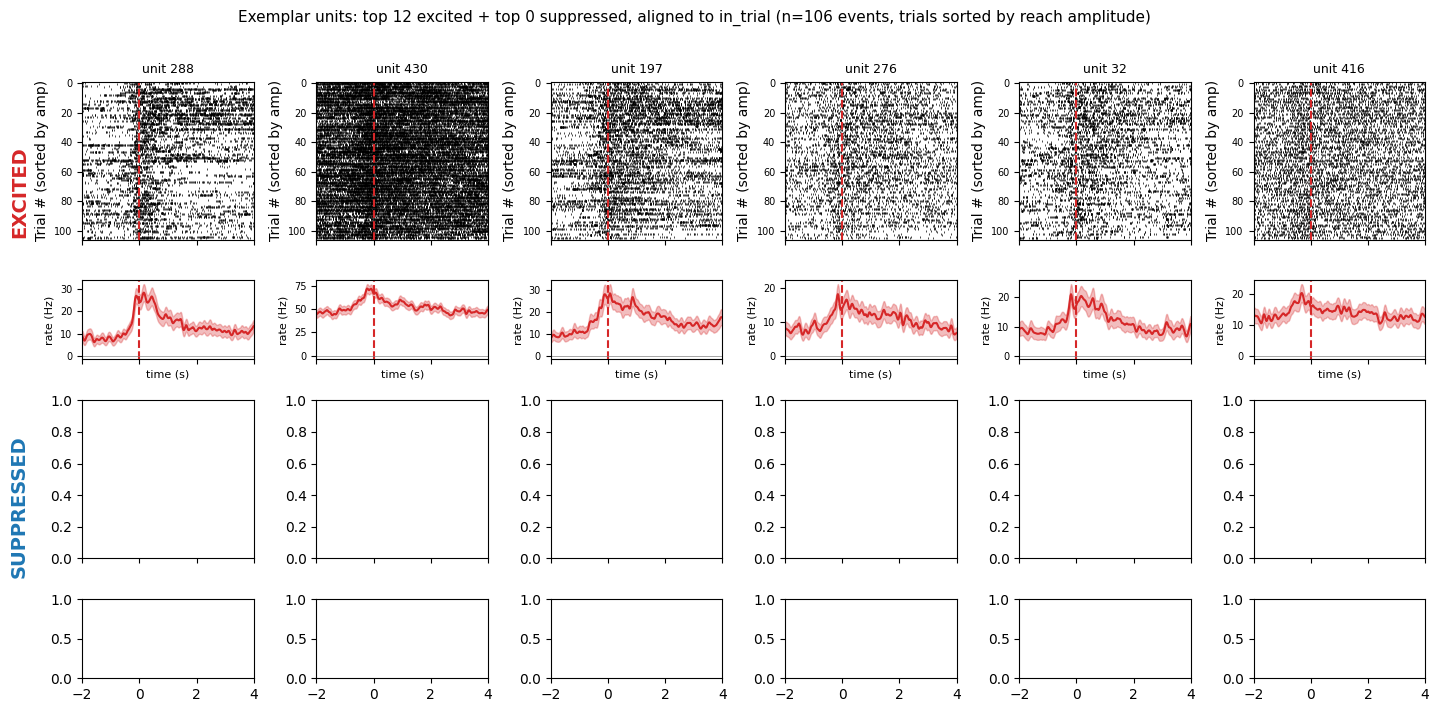


Saved → exemplar_units_in_trial_v2.png

===== CELL U v2 COMPLETE =====



In [22]:
# ============================================================
# CELL U — EXEMPLAR UNIT PSTH + RASTER PLOTS (v2)
# ============================================================
# Improvements over v1:
#   - Tick markers ("|") instead of dots for cleaner rasters
#   - Trials sorted by reach amplitude (largest amp at top)
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL U — EXEMPLAR UNIT PSTH + RASTER PLOTS (v2) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SUBSET_NAME       = "in_trial"
N_TOP_EXCITED     = 12
N_TOP_SUPPRESSED  = 0
WIN_PRE           = 2.0
WIN_POST          = 4.0
BIN_SIZE          = 0.020
SMOOTH_SIGMA_BINS = 2
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

# Load final set
final_path = analysis_folder / "qc" / f"final_reach_modulated_units_{SUBSET_NAME}.npz"
d = np.load(final_path)
units = d["units"]
peak_z = d["peak_z"]
peak_latency = d["peak_latency"]
excited_mask = d["excited_mask"]
suppressed_mask = d["suppressed_mask"]
centers = d["centers"]

# Pick top units
exc_idx_global = np.where(excited_mask)[0]
sup_idx_global = np.where(suppressed_mask)[0]

top_excited = exc_idx_global[np.argsort(peak_z[exc_idx_global])[::-1][:N_TOP_EXCITED]]
top_suppressed = sup_idx_global[np.argsort(peak_z[sup_idx_global])[:N_TOP_SUPPRESSED]]

print(f"Top excited units:    {[int(units[i]) for i in top_excited]}")
print(f"Top suppressed units: {[int(units[i]) for i in top_suppressed]}")

# ------------------------------------------------------------
# LOAD EVENTS + AMPLITUDES + SPIKES
# ------------------------------------------------------------
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
bout_onset_t = bouts["onset_t"]
bout_trial_id = bouts["trial_id"]
bout_max_amp = bouts["max_amplitude"]

if SUBSET_NAME == "in_trial":
    mask = bout_trial_id >= 0
elif SUBSET_NAME == "in_trial_first":
    mask = np.zeros(len(bout_onset_t), dtype=bool)
    for t_i in np.unique(bout_trial_id):
        if t_i == -1: continue
        ii = np.where(bout_trial_id == t_i)[0]
        mask[ii[np.argmin(bout_onset_t[ii])]] = True
else:
    raise ValueError(SUBSET_NAME)

event_times_raw = bout_onset_t[mask]
event_amps_raw  = bout_max_amp[mask]

# Sort events by amplitude (descending — largest reaches at top of raster)
amp_order = np.argsort(event_amps_raw)[::-1]
event_times = event_times_raw[amp_order]
event_amps  = event_amps_raw[amp_order]

print(f"Aligning to {len(event_times)} events, sorted by reach amplitude")
print(f"Amplitude range: {event_amps.min():.1f} → {event_amps.max():.1f} px")

spikes_dir = analysis_folder / "spikes"

# ------------------------------------------------------------
# PLOT FUNCTION
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
bin_centers = edges[:-1] + BIN_SIZE / 2

def plot_unit_with_raster(unit_id, ax_raster, ax_psth, color):
    spk = np.load(spikes_dir / f"unit_{unit_id}.npy")

    per_trial_spikes = []
    psth_per_trial = np.zeros((len(event_times), len(bin_centers)))
    for e_i, t_evt in enumerate(event_times):
        rel = spk[(spk >= t_evt - WIN_PRE) & (spk < t_evt + WIN_POST)] - t_evt
        per_trial_spikes.append(rel)
        h, _ = np.histogram(rel, bins=edges)
        psth_per_trial[e_i] = h / BIN_SIZE

    # Raster — tick marks
    for trial_i, spikes_in_trial in enumerate(per_trial_spikes):
        ax_raster.scatter(spikes_in_trial,
                          np.full_like(spikes_in_trial, trial_i),
                          s=4, color="black", marker="|", linewidths=0.5)
    ax_raster.axvline(0, color=color, lw=1.5, linestyle="--")
    ax_raster.set_xlim(-WIN_PRE, WIN_POST)
    ax_raster.set_ylim(len(event_times), -1)
    ax_raster.set_ylabel("Trial # (sorted by amp)")
    ax_raster.set_title(f"unit {unit_id}", fontsize=9)
    ax_raster.tick_params(labelsize=7)

    # PSTH
    psth_smooth = gaussian_filter1d(psth_per_trial.mean(axis=0),
                                    sigma=SMOOTH_SIGMA_BINS)
    sem = (gaussian_filter1d(psth_per_trial.std(axis=0),
                             sigma=SMOOTH_SIGMA_BINS) /
           np.sqrt(len(event_times)))
    ax_psth.plot(bin_centers, psth_smooth, color=color, lw=1.5)
    ax_psth.fill_between(bin_centers, psth_smooth - sem, psth_smooth + sem,
                          color=color, alpha=0.3)
    ax_psth.axvline(0, color=color, lw=1.5, linestyle="--")
    ax_psth.axhline(0, color="gray", lw=0.5)
    ax_psth.set_xlim(-WIN_PRE, WIN_POST)
    ax_psth.set_xlabel("time (s)", fontsize=8)
    ax_psth.set_ylabel("rate (Hz)", fontsize=8)
    ax_psth.tick_params(labelsize=7)

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
ncols = 6
nrows = 4

fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 7),
                         sharex=True,
                         gridspec_kw={"height_ratios": [2, 1, 2, 1]})

for i, gi in enumerate(top_excited[:ncols]):
    plot_unit_with_raster(int(units[gi]),
                          axes[0, i], axes[1, i],
                          color="C3")

for i, gi in enumerate(top_suppressed[:ncols]):
    plot_unit_with_raster(int(units[gi]),
                          axes[2, i], axes[3, i],
                          color="C0")

fig.text(0.05, 0.75, "EXCITED", rotation=90, fontsize=14, color="C3",
         ha="center", va="center", weight="bold")
fig.text(0.05, 0.30, "SUPPRESSED", rotation=90, fontsize=14, color="C0",
         ha="center", va="center", weight="bold")

plt.suptitle(f"Exemplar units: top {N_TOP_EXCITED} excited + top "
             f"{N_TOP_SUPPRESSED} suppressed, aligned to {SUBSET_NAME} "
             f"(n={len(event_times)} events, trials sorted by reach amplitude)",
             fontsize=11, y=1.01)
plt.tight_layout(rect=[0.05, 0, 1, 1])

out_path = analysis_folder / "qc" / f"exemplar_units_{SUBSET_NAME}_v2.png"
j = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"exemplar_units_{SUBSET_NAME}_v2_{j}.png"
    j += 1
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out_path.name}")

print("\n===== CELL U v2 COMPLETE =====\n")


===== CELL V — REBOUND BURST DETECTION + EVENT ANALYSIS =====

Detecting bursts in 40 good units...
Criteria: ≥100ms quiet → first ISI ≤4ms → in-burst ISI ≤5ms → 2-15 spikes, <20ms total

Saved → bursts/burst_summary.npz (per-unit stats, 40 units)
Saved → bursts/all_bursts.npz (flat list, 4514 bursts)
Saved → bursts/burst_criteria.json

Session-wide burst statistics:
  Units with ≥1 burst:        38 / 40
  Units with ≥20 bursts:      33
  Median burst rate:          0.033 Hz
  Median burst fraction:      1.2%
  Median burst size:          2.5 spikes
  reach_in_trial: 106 events
  motor_expose: 55 events
  tone: 55 events
  button: 55 events

Total bursts pooled across units: 4514
  Computing burst PSTH for reach_in_trial...
  Computing burst PSTH for motor_expose...
  Computing burst PSTH for tone...
  Computing burst PSTH for button...


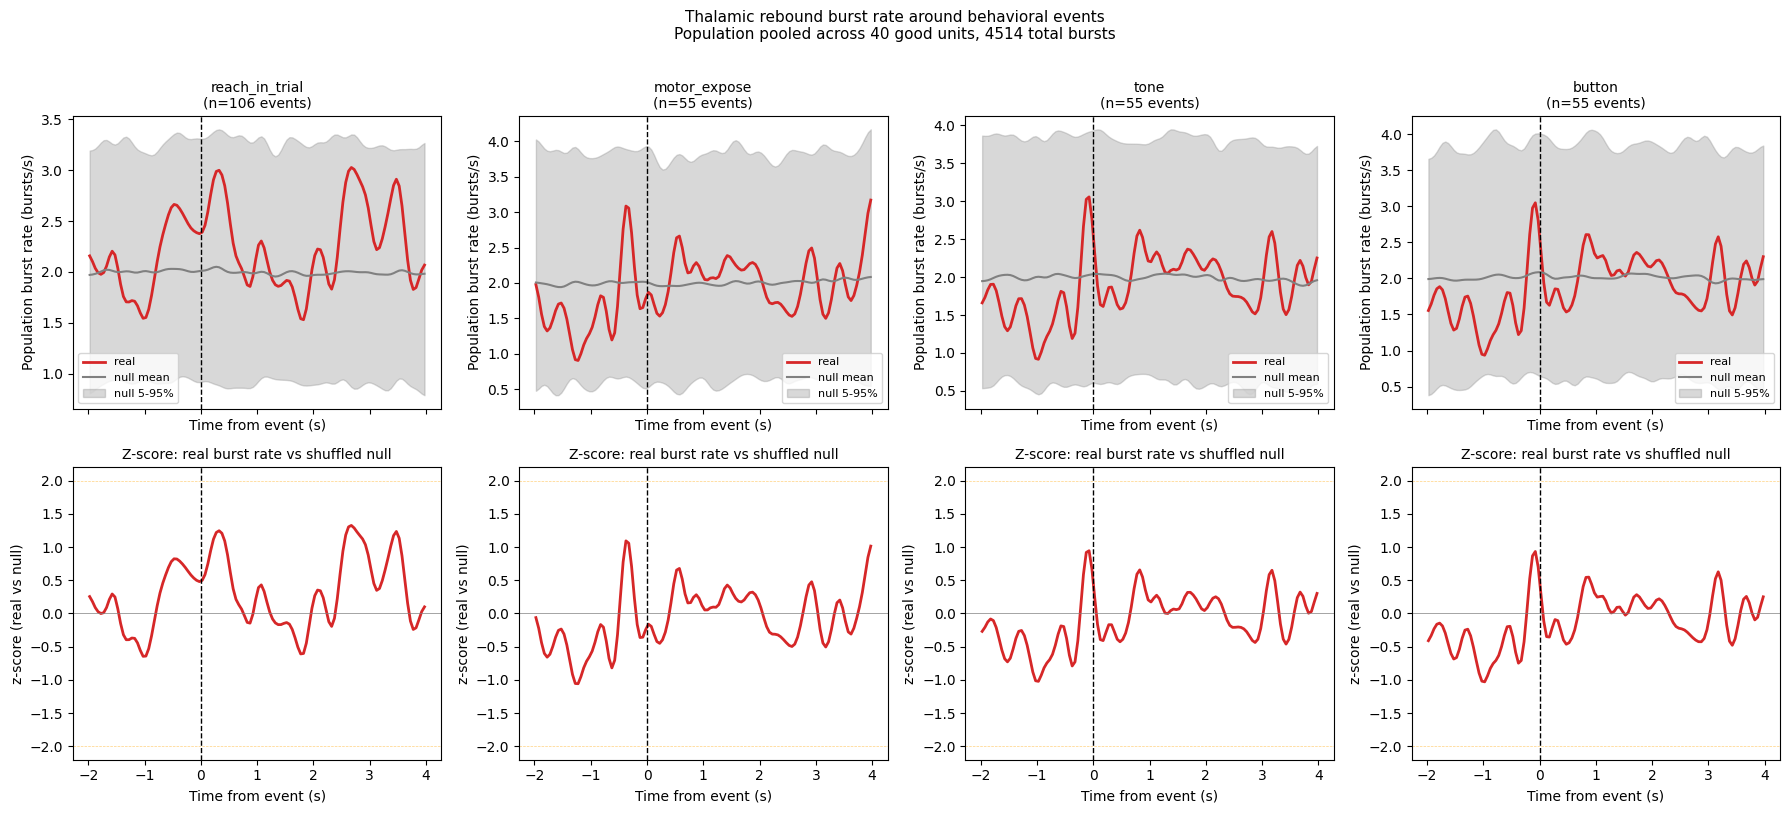


Saved → burst_around_events.png

===== PER-UNIT BURST MODULATION (proper null) =====
Only testing units with ≥20 total bursts
Per-unit shuffle test, threshold |z| > 2.0

Testable units (≥20 bursts): 33 / 40

Event               units z>+2  units z<-2   median z
-------------------------------------------------------
reach_in_trial               7           2     -0.11
motor_expose                 2           0     -0.14
tone                         2           1     -0.06
button                       1           0     -0.12

Saved → bursts/burst_event_modulation.npz (40 units × 4 event types)

===== INTERPRETATION =====
 • z > 2: this unit bursts MORE around the event than at random times
   (sensory/motor-driven LTS bursting)
 • z < -2: this unit bursts LESS around the event than at random times
   (depolarized 'tonic mode' during behavior, blocking T-type channels)
 • |z| < 2: bursting is not modulated by this event type
 • Same unit can be event-locked to some events but not others

In [23]:
# ============================================================
# CELL V — THALAMIC REBOUND BURST DETECTION + EVENT ALIGNMENT
# ============================================================
# Detects T-type calcium-dependent rebound bursts using strict
# criteria (≥100 ms quiet, first ISI ≤4 ms, ≤5 ms ISI within burst,
# ≥2 spikes), and tests whether bursting clusters around behavioral
# events.
#
# v2: Replaced fold-change metric (inflated by burst rarity) with
# proper per-unit shuffled-events null comparison. Now reports
# the number of units with z > 2 burst-rate elevation in the
# response window vs. shuffled events.
#
# Outputs (in analysis_folder/bursts/):
#   - burst_summary.npz       per-unit stats
#   - all_bursts.npz          flat list of every burst (onset, unit, size, dur)
#   - burst_event_modulation.npz   per-unit per-event z-scores
#   - burst_criteria.json     exact detection parameters
#   - burst_around_events.png population burst-rate PSTHs
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL V — REBOUND BURST DETECTION + EVENT ANALYSIS =====")

# ------------------------------------------------------------
# USER EDIT — BURST CRITERIA
# ------------------------------------------------------------
MIN_QUIET_S          = 0.100   # min silence before burst
MAX_ISI_S            = 0.005   # max ISI within burst
MAX_FIRST_ISI_S      = 0.004   # first in-burst ISI ≤4 ms (T-type signature)
MIN_BURST_SPIKES     = 2
MAX_BURST_SPIKES     = 15
MAX_BURST_DURATION_S = 0.020   # bursts span <20 ms total

# ------------------------------------------------------------
# USER EDIT — EVENT ALIGNMENT
# ------------------------------------------------------------
WIN_PRE   = 2.0
WIN_POST  = 4.0
BIN_SIZE  = 0.050   # bigger bins for burst PSTH (bursts are rare)
SMOOTH_SIGMA_BINS = 2
N_SHUFFLES = 200
RANDOM_SEED = 42

# Per-unit modulation test parameters
RESPONSE_WIN = (-0.5, 2.0)   # window where we look for event-locked bursts
MIN_BURSTS_FOR_TEST = 20     # minimum total bursts to test per unit
Z_MOD_THRESH = 2.0           # z threshold for "significantly modulated"

event_definitions = [
    ("reach_in_trial", "bouts"),
    ("motor_expose",   "pin3_odd"),
    ("tone",           "pin4"),
    ("button",         "pin7"),
]
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# BURST DETECTOR
# ------------------------------------------------------------
def detect_thalamic_bursts(spike_times):
    """Strict T-type rebound burst criteria."""
    spike_times = np.asarray(spike_times)
    n = len(spike_times)
    if n < MIN_BURST_SPIKES:
        return []

    bursts = []
    i = 0
    while i < n - 1:
        prev_isi = spike_times[i] - spike_times[i - 1] if i > 0 else np.inf
        if prev_isi < MIN_QUIET_S:
            i += 1
            continue

        first_isi = spike_times[i + 1] - spike_times[i] if i + 1 < n else np.inf
        if first_isi > MAX_FIRST_ISI_S:
            i += 1
            continue

        burst = [spike_times[i], spike_times[i + 1]]
        j = i + 1
        while j < n - 1 and (spike_times[j + 1] - spike_times[j]) <= MAX_ISI_S:
            burst.append(spike_times[j + 1])
            j += 1
            if len(burst) >= MAX_BURST_SPIKES:
                break

        burst_dur = burst[-1] - burst[0]
        if (len(burst) >= MIN_BURST_SPIKES and
            len(burst) <= MAX_BURST_SPIKES and
            burst_dur <= MAX_BURST_DURATION_S):
            bursts.append({
                "onset_t": float(burst[0]),
                "n_spikes": len(burst),
                "duration_s": burst_dur,
                "spikes": np.array(burst),
            })
            i = j + 1
        else:
            i += 1
    return bursts

# ------------------------------------------------------------
# LOAD UNITS + DETECT BURSTS
# ------------------------------------------------------------
good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"
good_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}

print(f"\nDetecting bursts in {len(good_units)} good units...")
print(f"Criteria: ≥{MIN_QUIET_S*1000:.0f}ms quiet → "
      f"first ISI ≤{MAX_FIRST_ISI_S*1000:.0f}ms → "
      f"in-burst ISI ≤{MAX_ISI_S*1000:.0f}ms → "
      f"{MIN_BURST_SPIKES}-{MAX_BURST_SPIKES} spikes, "
      f"<{MAX_BURST_DURATION_S*1000:.0f}ms total")

burst_data = {}
for u in good_units:
    bursts = detect_thalamic_bursts(good_spikes[int(u)])
    burst_data[int(u)] = bursts

# ------------------------------------------------------------
# PER-UNIT SUMMARY STATISTICS
# ------------------------------------------------------------
summary_rows = []
for u in good_units:
    u = int(u)
    spk = good_spikes[u]
    bursts = burst_data[u]
    n_spikes_total = len(spk)
    n_bursts = len(bursts)
    spikes_in_bursts = sum(b["n_spikes"] for b in bursts)
    burst_size_mean = float(np.mean([b["n_spikes"] for b in bursts])) if bursts else 0.0
    summary_rows.append({
        "unit": u,
        "n_spikes": n_spikes_total,
        "firing_rate_hz": n_spikes_total / recording_duration,
        "n_bursts": n_bursts,
        "burst_rate_hz": n_bursts / recording_duration,
        "burst_fraction_spikes": spikes_in_bursts / n_spikes_total if n_spikes_total else 0,
        "burst_size_mean": burst_size_mean,
    })

# Stack summary into arrays for npz
unit_ids = np.array([r["unit"] for r in summary_rows])
n_spikes = np.array([r["n_spikes"] for r in summary_rows])
firing_rate_hz = np.array([r["firing_rate_hz"] for r in summary_rows])
n_bursts_arr = np.array([r["n_bursts"] for r in summary_rows])
burst_rate_hz = np.array([r["burst_rate_hz"] for r in summary_rows])
burst_fraction_spikes = np.array([r["burst_fraction_spikes"] for r in summary_rows])
burst_size_mean = np.array([r["burst_size_mean"] for r in summary_rows])

# Flat list of every burst
burst_onsets_flat = []
burst_unit_ids_flat = []
burst_n_spikes_flat = []
burst_durations_flat = []
for u in good_units:
    u_int = int(u)
    for b in burst_data[u_int]:
        burst_onsets_flat.append(b["onset_t"])
        burst_unit_ids_flat.append(u_int)
        burst_n_spikes_flat.append(b["n_spikes"])
        burst_durations_flat.append(b["duration_s"])

burst_onsets_flat = np.array(burst_onsets_flat)
burst_unit_ids_flat = np.array(burst_unit_ids_flat)
burst_n_spikes_flat = np.array(burst_n_spikes_flat)
burst_durations_flat = np.array(burst_durations_flat)

burst_out_dir = analysis_folder / "bursts"
burst_out_dir.mkdir(exist_ok=True)

np.savez(
    burst_out_dir / "burst_summary.npz",
    unit_ids=unit_ids,
    n_spikes=n_spikes,
    firing_rate_hz=firing_rate_hz,
    n_bursts=n_bursts_arr,
    burst_rate_hz=burst_rate_hz,
    burst_fraction_spikes=burst_fraction_spikes,
    burst_size_mean=burst_size_mean,
)

np.savez(
    burst_out_dir / "all_bursts.npz",
    onset_t=burst_onsets_flat,
    unit_id=burst_unit_ids_flat,
    n_spikes=burst_n_spikes_flat,
    duration_s=burst_durations_flat,
)

with open(burst_out_dir / "burst_criteria.json", "w") as f:
    json.dump({
        "min_quiet_s": MIN_QUIET_S,
        "max_isi_s": MAX_ISI_S,
        "max_first_isi_s": MAX_FIRST_ISI_S,
        "min_burst_spikes": MIN_BURST_SPIKES,
        "max_burst_spikes": MAX_BURST_SPIKES,
        "max_burst_duration_s": MAX_BURST_DURATION_S,
        "definition": "T-type Ca2+ channel rebound bursts (Sherman criteria)",
    }, f, indent=2)

print(f"\nSaved → bursts/burst_summary.npz "
      f"(per-unit stats, {len(unit_ids)} units)")
print(f"Saved → bursts/all_bursts.npz "
      f"(flat list, {len(burst_onsets_flat)} bursts)")
print(f"Saved → bursts/burst_criteria.json")

print(f"\nSession-wide burst statistics:")
print(f"  Units with ≥1 burst:        "
      f"{(n_bursts_arr >= 1).sum()} / {len(unit_ids)}")
print(f"  Units with ≥{MIN_BURSTS_FOR_TEST} bursts:      "
      f"{(n_bursts_arr >= MIN_BURSTS_FOR_TEST).sum()}")
print(f"  Median burst rate:          {np.median(burst_rate_hz):.3f} Hz")
print(f"  Median burst fraction:      "
      f"{np.median(burst_fraction_spikes)*100:.1f}%")
mask_active = n_bursts_arr > 0
if mask_active.any():
    print(f"  Median burst size:          "
          f"{np.median(burst_size_mean[mask_active]):.1f} spikes")

# ------------------------------------------------------------
# LOAD EVENTS
# ------------------------------------------------------------
ttls_dir = analysis_folder / "ttls"
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")

events_by_type = {}
for name, source in event_definitions:
    if source == "bouts":
        m = bouts["trial_id"] >= 0
        events_by_type[name] = np.sort(bouts["onset_t"][m])
    elif source == "pin3_odd":
        p3 = np.load(ttls_dir / "TTL_Pin_3.npy")
        if len(p3) % 2 != 0:
            p3 = p3[:-1]
        events_by_type[name] = np.sort(p3[0::2])
    elif source.startswith("pin"):
        pin = int(source.replace("pin", ""))
        events_by_type[name] = np.sort(np.load(ttls_dir / f"TTL_Pin_{pin}.npy"))

for name, evts in events_by_type.items():
    print(f"  {name}: {len(evts)} events")

# ------------------------------------------------------------
# POPULATION-LEVEL BURST RATE AROUND EVENTS
# ------------------------------------------------------------
edges = np.arange(-WIN_PRE, WIN_POST + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2

def compute_burst_psth(burst_onsets, events):
    """Per-event burst counts, then averaged → bursts/sec."""
    if len(burst_onsets) == 0:
        return np.zeros(len(centers))
    burst_onsets = np.asarray(burst_onsets)
    per_event_counts = np.zeros((len(events), len(centers)))
    for e_i, t_evt in enumerate(events):
        rel = burst_onsets[(burst_onsets >= t_evt - WIN_PRE) &
                           (burst_onsets < t_evt + WIN_POST)] - t_evt
        h, _ = np.histogram(rel, bins=edges)
        per_event_counts[e_i] = h
    return per_event_counts.mean(axis=0) / BIN_SIZE

all_burst_onsets = np.sort(burst_onsets_flat)
print(f"\nTotal bursts pooled across units: {len(all_burst_onsets)}")

rng = np.random.default_rng(RANDOM_SEED)
t_min = WIN_PRE + 1.0
t_max = recording_duration - WIN_POST - 1.0

null_distributions = {}
real_psths = {}
for name, events in events_by_type.items():
    print(f"  Computing burst PSTH for {name}...")
    real_psth = compute_burst_psth(all_burst_onsets, events)
    real_psths[name] = real_psth

    null = np.zeros((N_SHUFFLES, len(centers)))
    for s in range(N_SHUFFLES):
        fake = rng.uniform(t_min, t_max, size=len(events))
        fake.sort()
        null[s] = compute_burst_psth(all_burst_onsets, fake)
    null_distributions[name] = null

# ------------------------------------------------------------
# FIGURE: POPULATION-LEVEL
# ------------------------------------------------------------
fig, axes = plt.subplots(2, len(events_by_type),
                          figsize=(4.5 * len(events_by_type), 8),
                          sharex=True)
if len(events_by_type) == 1:
    axes = axes[:, np.newaxis]

for col, (name, events) in enumerate(events_by_type.items()):
    real = real_psths[name]
    null = null_distributions[name]
    null_mean = null.mean(axis=0)
    null_std  = null.std(axis=0)

    real_smooth = gaussian_filter1d(real, sigma=SMOOTH_SIGMA_BINS)
    null_mean_s = gaussian_filter1d(null_mean, sigma=SMOOTH_SIGMA_BINS)
    null_p5 = gaussian_filter1d(np.percentile(null, 5, axis=0),
                                 sigma=SMOOTH_SIGMA_BINS)
    null_p95 = gaussian_filter1d(np.percentile(null, 95, axis=0),
                                  sigma=SMOOTH_SIGMA_BINS)

    ax = axes[0, col]
    ax.plot(centers, real_smooth, color="C3", lw=2, label="real")
    ax.plot(centers, null_mean_s, color="gray", lw=1.5, label="null mean")
    ax.fill_between(centers, null_p5, null_p95, color="gray", alpha=0.3,
                    label="null 5-95%")
    ax.axvline(0, color="black", lw=1.0, linestyle="--")
    ax.set_xlabel("Time from event (s)")
    ax.set_ylabel("Population burst rate (bursts/s)")
    ax.set_title(f"{name}\n(n={len(events)} events)", fontsize=10)
    ax.legend(fontsize=8)

    ax = axes[1, col]
    null_std_safe = np.maximum(null_std, 1e-9)
    z_real = (real - null_mean) / null_std_safe
    z_smooth = gaussian_filter1d(z_real, sigma=SMOOTH_SIGMA_BINS)
    ax.plot(centers, z_smooth, color="C3", lw=2)
    ax.axvline(0, color="black", lw=1.0, linestyle="--")
    ax.axhline(0, color="gray", lw=0.5)
    ax.axhline(2, color="orange", lw=0.5, linestyle="--", alpha=0.5)
    ax.axhline(-2, color="orange", lw=0.5, linestyle="--", alpha=0.5)
    ax.set_xlabel("Time from event (s)")
    ax.set_ylabel("z-score (real vs null)")
    ax.set_title("Z-score: real burst rate vs shuffled null", fontsize=10)

plt.suptitle(
    f"Thalamic rebound burst rate around behavioral events\n"
    f"Population pooled across {len(good_units)} good units, "
    f"{len(all_burst_onsets)} total bursts",
    fontsize=11, y=1.01
)
plt.tight_layout()

out_path = analysis_folder / "qc" / "burst_around_events.png"
i = 1
while out_path.exists():
    out_path = analysis_folder / "qc" / f"burst_around_events_{i}.png"
    i += 1
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out_path.name}")

# ------------------------------------------------------------
# PER-UNIT BURST MODULATION (PROPER PER-UNIT NULL TEST)
# ------------------------------------------------------------
# For each unit with ≥MIN_BURSTS_FOR_TEST bursts:
#   1) Count its bursts in the response window around real events.
#   2) Repeat for N_SHUFFLES random event sets.
#   3) Z-score the real count against the shuffled distribution.
#   4) Flag as "modulated" if z > Z_MOD_THRESH.
# ------------------------------------------------------------
print("\n===== PER-UNIT BURST MODULATION (proper null) =====")
print(f"Only testing units with ≥{MIN_BURSTS_FOR_TEST} total bursts")
print(f"Per-unit shuffle test, threshold |z| > {Z_MOD_THRESH}")

response_dur_s = RESPONSE_WIN[1] - RESPONSE_WIN[0]

per_unit_z = {name: np.full(len(unit_ids), np.nan) for name in events_by_type}
per_unit_real_count = {name: np.full(len(unit_ids), np.nan) for name in events_by_type}
per_unit_null_mean = {name: np.full(len(unit_ids), np.nan) for name in events_by_type}

rng = np.random.default_rng(RANDOM_SEED + 1)

# Precompute shuffled event sets ONCE (same shuffles for all units, for fairness)
shuffled_event_sets = {}
for name, events in events_by_type.items():
    n_evt = len(events)
    shuffled_event_sets[name] = [
        np.sort(rng.uniform(t_min, t_max, size=n_evt))
        for _ in range(N_SHUFFLES)
    ]

def count_bursts_in_window(burst_onsets, events, win=RESPONSE_WIN):
    """Total bursts across all events in response window."""
    if len(burst_onsets) == 0 or len(events) == 0:
        return 0
    burst_onsets = np.asarray(burst_onsets)
    count = 0
    for t_evt in events:
        rel = burst_onsets[(burst_onsets >= t_evt + win[0]) &
                           (burst_onsets < t_evt + win[1])]
        count += len(rel)
    return count

for u_idx, u in enumerate(unit_ids):
    u_int = int(u)
    bursts_u = np.array([b["onset_t"] for b in burst_data[u_int]])
    if len(bursts_u) < MIN_BURSTS_FOR_TEST:
        continue

    for name, events in events_by_type.items():
        real_count = count_bursts_in_window(bursts_u, events)
        null_counts = np.array([
            count_bursts_in_window(bursts_u, shuf)
            for shuf in shuffled_event_sets[name]
        ])
        null_mean = null_counts.mean()
        null_std = max(null_counts.std(), 0.5)  # floor to avoid div by zero
        z = (real_count - null_mean) / null_std
        per_unit_z[name][u_idx] = z
        per_unit_real_count[name][u_idx] = real_count
        per_unit_null_mean[name][u_idx] = null_mean

# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------
n_testable = (n_bursts_arr >= MIN_BURSTS_FOR_TEST).sum()
print(f"\nTestable units (≥{MIN_BURSTS_FOR_TEST} bursts): {n_testable} / {len(unit_ids)}")
print(f"\n{'Event':<18} {'units z>+2':>11} {'units z<-2':>11} {'median z':>10}")
print("-" * 55)
for name in events_by_type:
    zvals = per_unit_z[name]
    valid = ~np.isnan(zvals)
    n_pos = (zvals[valid] > Z_MOD_THRESH).sum()
    n_neg = (zvals[valid] < -Z_MOD_THRESH).sum()
    med_z = np.nanmedian(zvals)
    print(f"{name:<18} {n_pos:>11d} {n_neg:>11d} {med_z:>9.2f}")

# Save
event_names_arr = np.array(list(events_by_type.keys()))
z_matrix = np.column_stack([per_unit_z[name] for name in events_by_type])
real_count_matrix = np.column_stack([per_unit_real_count[name] for name in events_by_type])
null_mean_matrix = np.column_stack([per_unit_null_mean[name] for name in events_by_type])

np.savez(
    burst_out_dir / "burst_event_modulation.npz",
    unit_ids=unit_ids,
    event_names=event_names_arr,
    z_scores=z_matrix,          # primary metric: shape (n_units, n_events)
    real_counts=real_count_matrix,
    null_means=null_mean_matrix,
    response_window_s=np.array(RESPONSE_WIN),
    min_bursts_required=MIN_BURSTS_FOR_TEST,
    z_threshold=Z_MOD_THRESH,
)
print(f"\nSaved → bursts/burst_event_modulation.npz "
      f"({z_matrix.shape[0]} units × {z_matrix.shape[1]} event types)")

print("\n===== INTERPRETATION =====")
print(" • z > 2: this unit bursts MORE around the event than at random times")
print("   (sensory/motor-driven LTS bursting)")
print(" • z < -2: this unit bursts LESS around the event than at random times")
print("   (depolarized 'tonic mode' during behavior, blocking T-type channels)")
print(" • |z| < 2: bursting is not modulated by this event type")
print(" • Same unit can be event-locked to some events but not others")

print("\n===== CELL V v2 COMPLETE =====\n")

In [24]:
# ============================================================
# CELL W — UNIT FINGERPRINT EXTRACTION
# ============================================================
# Builds a comprehensive feature vector for each good unit, used
# downstream for cross-day unit matching.
#
# Per-unit fingerprint includes:
#   - Centroid: weighted center of waveform across channels (µm)
#   - Best channel ID
#   - Template waveform (full template, all channels)
#   - Waveform on best channel (1D, for fast correlation)
#   - Waveform width, trough-to-peak, peak amplitude
#   - Firing rate
#   - ISI CV
#   - Autocorrelogram (0-50 ms)
#   - Burst statistics (rate, fraction, mean size)
#   - Reach PSTH (if Cell S/T results exist)
#
# Output (in analysis_folder/fingerprints/):
#   - unit_fingerprints.npz   all features per unit
#   - fingerprint_metadata.json   what each feature means
# ============================================================
import json
import numpy as np
from pathlib import Path

print("\n===== CELL W — UNIT FINGERPRINT EXTRACTION =====")

# ------------------------------------------------------------
# USER EDIT — paths and parameters
# ------------------------------------------------------------
PROBEA_PATH = r"G:\Kevin\2026-03-03_10-26-01\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4" ##########################################################################################

# ACG parameters
ACG_MAX_LAG_MS = 50
ACG_BIN_MS = 1

# Channel pitch on Neuropixels 2.0 (µm). Adjust if using a different probe.
CHANNEL_PITCH_Y = 15    # vertical spacing
CHANNEL_PITCH_X = 32    # horizontal spacing (alternating columns)

# Subset for reach PSTH inclusion (used if Cell S results exist)
SUBSET_NAME = "in_trial"
# ------------------------------------------------------------

if "analysis_folder" not in globals():
    raise RuntimeError("Set analysis_folder.")

with open(analysis_folder / "metadata" / "session.json") as f:
    session = json.load(f)
recording_duration = session["recording_duration_s"]

# ------------------------------------------------------------
# LOAD KILOSORT DATA
# ------------------------------------------------------------
probe_dir = Path(PROBEA_PATH)
print(f"Loading Kilosort outputs from {probe_dir.name}...")

templates = np.load(probe_dir / "templates.npy")       # (n_templates, n_timepoints, n_channels)
spike_clusters = np.load(probe_dir / "spike_clusters.npy").flatten()
spike_templates = np.load(probe_dir / "spike_templates.npy").flatten()
channel_positions = np.load(probe_dir / "channel_positions.npy")  # (n_channels, 2): x, y in µm

print(f"  Templates: {templates.shape}  (n_templates, timepoints, channels)")
print(f"  Channel positions: {channel_positions.shape}")
print(f"  Y-range: {channel_positions[:, 1].min():.0f} → "
      f"{channel_positions[:, 1].max():.0f} µm")

NP_SAMPLE_RATE = 30000.0

# ------------------------------------------------------------
# LOAD GOOD UNITS + SPIKES
# ------------------------------------------------------------
good_units = np.load(analysis_folder / "qc" / "good_units.npy")
spikes_dir = analysis_folder / "spikes"
good_spikes = {int(u): np.load(spikes_dir / f"unit_{u}.npy") for u in good_units}
print(f"\nGood units: {len(good_units)}")

# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------
def get_template_for_unit(cluster_id):
    """Find the most-used template for this cluster."""
    mask = spike_clusters == cluster_id
    if not mask.any():
        return None
    used_templates = spike_templates[mask]
    template_id = int(np.bincount(used_templates).argmax())
    return templates[template_id]   # (n_timepoints, n_channels)

def compute_centroid(template):
    """Weighted center of mass of waveform amplitudes across channels."""
    ch_amp = template.max(axis=0) - template.min(axis=0)  # (n_channels,)
    weights = ch_amp ** 2  # weight by power, emphasizes strong channels
    weights /= weights.sum() + 1e-9
    centroid_x = np.sum(weights * channel_positions[:, 0])
    centroid_y = np.sum(weights * channel_positions[:, 1])
    return centroid_x, centroid_y, ch_amp

def compute_waveform_features(template, best_ch):
    """Width (peak-to-trough samples), trough-to-peak ratio, peak amplitude."""
    trace = template[:, best_ch]
    peak_idx = int(np.argmin(trace))
    trace_after = trace[peak_idx:]
    trough_idx = int(np.argmax(trace_after)) + peak_idx
    width_samples = trough_idx - peak_idx
    width_ms = width_samples / NP_SAMPLE_RATE * 1000
    peak_amp = float(trace.min())
    trough_amp = float(trace.max() if trough_idx < len(trace) else 0)
    trough_to_peak_ratio = abs(trough_amp / peak_amp) if peak_amp != 0 else 0
    peak_to_peak_amp = float(trace.max() - trace.min())
    return width_ms, trough_to_peak_ratio, peak_to_peak_amp

def compute_acg(spike_times, max_lag_ms=ACG_MAX_LAG_MS, bin_ms=ACG_BIN_MS):
    """Autocorrelogram (count of spike pairs at each lag, 0 to +max_lag)."""
    n_bins = int(max_lag_ms / bin_ms)
    acg = np.zeros(n_bins)
    if len(spike_times) < 2:
        return acg
    # For each spike, find following spikes within max_lag
    max_lag_s = max_lag_ms / 1000.0
    bin_size_s = bin_ms / 1000.0
    for i in range(len(spike_times) - 1):
        for j in range(i + 1, len(spike_times)):
            dt = spike_times[j] - spike_times[i]
            if dt >= max_lag_s:
                break
            bin_idx = int(dt / bin_size_s)
            if bin_idx < n_bins:
                acg[bin_idx] += 1
    # Normalize
    if acg.sum() > 0:
        acg /= len(spike_times)
    return acg

def compute_isi_cv(spike_times):
    """Coefficient of variation of inter-spike intervals."""
    if len(spike_times) < 3:
        return 0.0
    isis = np.diff(spike_times)
    if isis.mean() == 0:
        return 0.0
    return float(isis.std() / isis.mean())

# ------------------------------------------------------------
# LOAD OPTIONAL DATA: BURSTS + REACH PSTH
# ------------------------------------------------------------
has_bursts = (analysis_folder / "bursts" / "burst_summary.npz").exists()
if has_bursts:
    burst_summary = np.load(analysis_folder / "bursts" / "burst_summary.npz")
    burst_unit_ids = burst_summary["unit_ids"]
    burst_rate_arr = burst_summary["burst_rate_hz"]
    burst_fraction_arr = burst_summary["burst_fraction_spikes"]
    burst_size_arr = burst_summary["burst_size_mean"]
    print(f"\nLoaded burst summary for {len(burst_unit_ids)} units")
else:
    print("\nNo burst summary found (Cell V wasn't run).")

reach_psth_path = analysis_folder / "qc" / f"reach_good_{SUBSET_NAME}_arrays.npz"
has_reach = reach_psth_path.exists()
if has_reach:
    reach_data = np.load(reach_psth_path)
    reach_unit_ids = reach_data["units"]
    reach_z_means = reach_data["z_mean"]   # (n_units, n_bins)
    reach_modulated = reach_data["modulated"]
    reach_peak_z = reach_data["peak_z"]
    reach_peak_lat = reach_data["peak_latency"]
    reach_centers = reach_data["centers"]
    print(f"Loaded reach PSTH data for {len(reach_unit_ids)} units")
else:
    print(f"No reach PSTH data found (Cell M wasn't run for {SUBSET_NAME}).")

# ------------------------------------------------------------
# BUILD FINGERPRINT FOR EACH UNIT
# ------------------------------------------------------------
print(f"\nBuilding fingerprints for {len(good_units)} units...")

n_units = len(good_units)
n_template_samples = templates.shape[1]
n_channels = templates.shape[2]

# Pre-allocate arrays
fp_unit_ids = np.zeros(n_units, dtype=int)
fp_best_ch = np.zeros(n_units, dtype=int)
fp_centroid_x = np.zeros(n_units)
fp_centroid_y = np.zeros(n_units)
fp_waveform_best = np.zeros((n_units, n_template_samples))
fp_template_full = np.zeros((n_units, n_template_samples, n_channels))
fp_width_ms = np.zeros(n_units)
fp_trough_to_peak = np.zeros(n_units)
fp_peak_to_peak_amp = np.zeros(n_units)
fp_firing_rate = np.zeros(n_units)
fp_isi_cv = np.zeros(n_units)
n_acg_bins = int(ACG_MAX_LAG_MS / ACG_BIN_MS)
fp_acg = np.zeros((n_units, n_acg_bins))
fp_burst_rate = np.zeros(n_units)
fp_burst_fraction = np.zeros(n_units)
fp_burst_size = np.zeros(n_units)
fp_reach_z_mean = np.zeros((n_units, len(reach_centers) if has_reach else 1))
fp_reach_modulated = np.zeros(n_units, dtype=bool)
fp_reach_peak_z = np.zeros(n_units)
fp_reach_peak_lat = np.zeros(n_units)

for i, u in enumerate(good_units):
    u_int = int(u)
    fp_unit_ids[i] = u_int

    # Template + centroid + best channel
    template = get_template_for_unit(u_int)
    if template is None:
        print(f"  WARNING: no template for unit {u_int}")
        continue
    cx, cy, ch_amp = compute_centroid(template)
    best_ch = int(np.argmax(ch_amp))

    fp_best_ch[i] = best_ch
    fp_centroid_x[i] = cx
    fp_centroid_y[i] = cy
    fp_waveform_best[i] = template[:, best_ch]
    fp_template_full[i] = template

    # Waveform features
    w_ms, tp_ratio, pp_amp = compute_waveform_features(template, best_ch)
    fp_width_ms[i] = w_ms
    fp_trough_to_peak[i] = tp_ratio
    fp_peak_to_peak_amp[i] = pp_amp

    # Spiking stats
    spk = good_spikes[u_int]
    fp_firing_rate[i] = len(spk) / recording_duration
    fp_isi_cv[i] = compute_isi_cv(spk)

    # ACG
    fp_acg[i] = compute_acg(spk)

    # Burst stats (if available)
    if has_bursts and u_int in burst_unit_ids:
        burst_idx = int(np.where(burst_unit_ids == u_int)[0][0])
        fp_burst_rate[i] = burst_rate_arr[burst_idx]
        fp_burst_fraction[i] = burst_fraction_arr[burst_idx]
        fp_burst_size[i] = burst_size_arr[burst_idx]

    # Reach PSTH (if available)
    if has_reach and u_int in reach_unit_ids:
        reach_idx = int(np.where(reach_unit_ids == u_int)[0][0])
        fp_reach_z_mean[i] = reach_z_means[reach_idx]
        fp_reach_modulated[i] = bool(reach_modulated[reach_idx])
        fp_reach_peak_z[i] = reach_peak_z[reach_idx]
        fp_reach_peak_lat[i] = reach_peak_lat[reach_idx]

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{n_units} units processed")

# ------------------------------------------------------------
# SAVE FINGERPRINTS
# ------------------------------------------------------------
out_dir = analysis_folder / "fingerprints"
out_dir.mkdir(exist_ok=True)

np.savez(
    out_dir / "unit_fingerprints.npz",
    unit_ids=fp_unit_ids,
    best_ch=fp_best_ch,
    centroid_x=fp_centroid_x,
    centroid_y=fp_centroid_y,
    waveform_best=fp_waveform_best,
    template_full=fp_template_full,
    width_ms=fp_width_ms,
    trough_to_peak=fp_trough_to_peak,
    peak_to_peak_amp=fp_peak_to_peak_amp,
    firing_rate=fp_firing_rate,
    isi_cv=fp_isi_cv,
    acg=fp_acg,
    burst_rate=fp_burst_rate,
    burst_fraction=fp_burst_fraction,
    burst_size=fp_burst_size,
    reach_z_mean=fp_reach_z_mean,
    reach_modulated=fp_reach_modulated,
    reach_peak_z=fp_reach_peak_z,
    reach_peak_lat=fp_reach_peak_lat,
    channel_positions=channel_positions,
    has_bursts=has_bursts,
    has_reach=has_reach,
    sample_rate_hz=NP_SAMPLE_RATE,
)

with open(out_dir / "fingerprint_metadata.json", "w") as f:
    json.dump({
        "n_units": int(n_units),
        "session_path": str(analysis_folder),
        "probe_path": str(probe_dir),
        "recording_duration_s": float(recording_duration),
        "has_burst_data": bool(has_bursts),
        "has_reach_data": bool(has_reach),
        "reach_subset": SUBSET_NAME if has_reach else None,
        "acg_max_lag_ms": float(ACG_MAX_LAG_MS),
        "acg_bin_ms": float(ACG_BIN_MS),
        "n_acg_bins": int(n_acg_bins),
        "features": {
            "centroid_x": "weighted X position on probe (µm)",
            "centroid_y": "weighted Y position on probe (µm)",
            "best_ch": "channel with peak amplitude",
            "waveform_best": "template waveform on best channel",
            "template_full": "full template (timepoints × channels)",
            "width_ms": "peak-to-trough width in ms",
            "trough_to_peak": "trough/peak ratio",
            "peak_to_peak_amp": "peak-to-peak amplitude",
            "firing_rate": "session-wide firing rate (Hz)",
            "isi_cv": "coefficient of variation of ISIs",
            "acg": f"autocorrelogram, 0-{ACG_MAX_LAG_MS}ms in {ACG_BIN_MS}ms bins",
            "burst_*": "from Cell V (T-type rebound bursts)",
            "reach_*": "from Cell M reach-aligned modulation",
        }
    }, f, indent=2)

print(f"\nSaved → fingerprints/unit_fingerprints.npz")
print(f"Saved → fingerprints/fingerprint_metadata.json")

# ------------------------------------------------------------
# SUMMARY STATS
# ------------------------------------------------------------
print(f"\n===== FINGERPRINT SUMMARY =====")
print(f"  Total units:       {n_units}")
print(f"  Firing rate range: {fp_firing_rate.min():.2f} → {fp_firing_rate.max():.2f} Hz")
print(f"  Width range:       {fp_width_ms.min():.2f} → {fp_width_ms.max():.2f} ms")
print(f"  Centroid Y range:  {fp_centroid_y.min():.0f} → {fp_centroid_y.max():.0f} µm")
print(f"  Bursts captured:   {has_bursts}")
print(f"  Reach data captured: {has_reach}")
if has_reach:
    print(f"  Reach-modulated:   {fp_reach_modulated.sum()} / {n_units}")

print("\n===== CELL W COMPLETE =====\n")


===== CELL W — UNIT FINGERPRINT EXTRACTION =====
Loading Kilosort outputs from kilosort4...
  Templates: (548, 61, 384)  (n_templates, timepoints, channels)
  Channel positions: (384, 2)
  Y-range: 0 → 940 µm

Good units: 40

Loaded burst summary for 40 units
Loaded reach PSTH data for 38 units

Building fingerprints for 40 units...

Saved → fingerprints/unit_fingerprints.npz
Saved → fingerprints/fingerprint_metadata.json

===== FINGERPRINT SUMMARY =====
  Total units:       40
  Firing rate range: 0.47 → 47.96 Hz
  Width range:       0.23 → 0.73 ms
  Centroid Y range:  1 → 788 µm
  Bursts captured:   True
  Reach data captured: True
  Reach-modulated:   36 / 40

===== CELL W COMPLETE =====

